<a href="https://colab.research.google.com/github/JCMelendezT/JCMelendezT/blob/main/SISTEMA_JERARQUICO_DE_CLASIFICACION_DE_RADIOGRAFIAS_MUSCULOESQUELETICAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> # **SISTEMA JERARQUICO DE CLASIFICACION DE RADIOGRAFIAS MUSCULOESQUELETICAS**

Visión Computacional con Deep Learning - MURA v1.1





> ## ESTRUCTURA DEL NOTEBOOK

> ### ÍNDICE DE CONTENIDOS


- Introducción

- Metodología

  3.1 Dataset MURA v1.1

  3.2 Arquitectura del Sistema

  3.3 Técnicas de Data Augmentation

  3.4 Estrategias de Entrenamiento

  3.5 Métricas de Evaluación

- Configuración del Entorno

- Exploración y Análisis (EDA)

- Preparación de Datos

- Construcción del Modelo CNN1 (Clasificación de Anatomía)

- Construcción del Modelo CNN2 (Clasificación de Anomalía)

- Grid Search de Hiperparameters  # NO SE AUN SI DEJARLO O NO (DEMORA 18 HORAS APROX)

- Entrenamiento del Sistema

- Evaluación y Métricas

- Explicabilidad con Grad-CAM

- Análisis Detallado de Errores

- Conclusiones y Recomendaciones

- Anexos (Resultados Completos)

# **Introduccion y Resumen**

> ### Resumen


**Objetivo:** Desarrollar un sistema de clasificación jerárquico que identifique:

- CNN1: Anatomía de la radiografía (extremidad específica: hombro, codo, muñeca, cadera, rodilla, tobillo)

- CNN2: Presencia de anomalía (Normal vs. Anormal)

**Dataset:** MURA v1.1 (Musculoskeletal Radiographs)

- ~40,561 radiografías de 12,173 pacientes

- 7 categorías anatómicas

- Balanceadas por paciente, desbalanceadas por clase

**Técnicas Aplicadas:**

- Data Augmentation avanzado (ElasticTransform, MixUp, RandomErasing)

- Manejo del desbalance (FocalLoss, Class Weights, Oversampling)

- **Grid Search para optimización de hiperparameters** pendiente quitar

- Split estratificado por PACIENTE (prevención de leakage)

- Explicabilidad visual (Grad-CAM)

- Análisis cuantitativo de errores

**Resultados Esperados:**

- CNN1: ~98% Accuracy

- CNN2: ~78-80% Accuracy

- Sistema Jerárquico: ~76-78% Accuracy

> ### Introduccion

> #### Contexto Clínico

Las radiografías musculoesqueléticas son una de las herramientas de diagnóstico más comunes en medicina. Sin embargo:

- Variabilidad diagnóstica: Diferentes radiólogos pueden llegar a conclusiones distintas

- Sobrecarga de trabajo: Miles de radiografías diarias requieren análisis manual

- Necesidad de escalabilidad: Especialmente en zonas con escasos recursos médicos

> #### Problemática

Desarrollar un sistema automático que:

1. Identifique correctamente la anatomía radiografiada

2. Detecte anomalías con alta precisión

3. Sea explicable y validable por profesionales médicos

4. Mantenga reproducibilidad total

> #### Hipótesis de Trabajo

Un sistema de clasificación jerárquico (CNN1 → CNN2) con:

- Data Augmentation específicamente diseñado para radiografías

- Manejo robusto del desbalance de clases

- Validación estratificada por paciente

- Puede lograr una precisión clínicamente útil (>75% F1-Score en detección de anomalías).

# **Metodologia**

> ### Dataset MURA v1.1

Características generales:

- Total de radiografías: 40,561

- Pacientes únicos: 12,173

- Split original: 36,808 train / 3,753 test

- Categorías anatómicas: 7




# **Pipeline**

## Configuracion del entorno

> Imports necesarios

In [ ]:
# Data & Numerics
import numpy as np
import pandas as pd
from pathlib import Path
import os
import sys


# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, RandomSampler, SequentialSampler
import torchvision.transforms as transforms
from torchvision import models

# Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.preprocessing import StandardScaler

# Métricas & Validación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    cohen_kappa_score, balanced_accuracy_score
)
from sklearn.model_selection import StratifiedKFold

# Utilidades
import warnings
import json
from datetime import datetime
from collections import Counter, defaultdict
import pickle
from tqdm import tqdm
import subprocess

# Typing
from typing import List, Tuple, Optional


warnings.filterwarnings('ignore')



> Configuracion centralizada del proyecto

In [ ]:
class Config:
    """
    Clase centralizada para todos los parámetros del proyecto.
    Facilita reproducibilidad.
    """

    # ===== SISTEMA =====
    SEED = 42
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    NUM_WORKERS = 8
    PIN_MEMORY = torch.cuda.is_available()

    # ===== DATASET =====
    DATASET_PATH = Path('./mura_data')
    DATASET_PATH_FINAL = None
    IMAGE_SIZE = 224
    ANATOMIES = ['SHOULDER', 'ELBOW', 'WRIST', 'HIP', 'KNEE', 'ANKLE', 'FOREARM']
    NUM_CLASSES_CNN1 = len(ANATOMIES)  # 7
    NUM_CLASSES_CNN2 = 2  # Normal/Anormal

    # ===== SPLIT (Estratificado por paciente) =====
    TRAIN_SPLIT = 0.70
    VAL_SPLIT = 0.20
    TEST_SPLIT = 0.10

    # ===== AUGMENTATION =====
    AUGMENTATION_ENABLED = True
    ELASTIC_ENABLED = False  # ← OPTIMIZACIÓN: Deshabilitado (costoso)
    MIXUP_ALPHA = 1.0
    ROTATION_DEGREES = 20

    # ===== MODELO CNN1 =====
    CNN1_HIDDEN_DIMS = [256, 128]
    CNN1_DROPOUT = 0.3
    CNN1_LEARNING_RATE = 0.01
    CNN1_BATCH_SIZE = 64  # ← OPTIMIZACIÓN: Aumentado de 32
    CNN1_EPOCHS = 5
    CNN1_EARLY_STOPPING_PATIENCE = 10

    # ===== MODELO CNN2 (Grid Search) =====
    CNN2_HIDDEN_DIMS_OPTIONS = [[], [256, 128], [512, 256, 128]]
    CNN2_LEARNING_RATE_OPTIONS = [0.0001, 0.0005, 0.001, 0.005]
    CNN2_BATCH_SIZE_OPTIONS = [16, 32, 64]
    CNN2_DROPOUT_OPTIONS = [0.2, 0.4, 0.5]
    CNN2_EPOCHS = 50
    CNN2_EARLY_STOPPING_PATIENCE = 10

    # ===== PÉRDIDA & OPTIMIZACIÓN =====
    USE_FOCAL_LOSS = False
    FOCAL_GAMMA = 2.0
    FOCAL_ALPHA = 0.25
    USE_CLASS_WEIGHTS = False  # ← CORRECCIÓN: False para CNN1 (no necesita)
    OVERSAMPLING_RATIO = 0.7

    # ===== SCHEDULER =====
    SCHEDULER_TYPE = 'ReduceLROnPlateau'

    # ===== OUTPUT =====
    OUTPUT_DIR = Path('./results')
    SAVE_BEST_MODELS = True
    SAVE_PREDICTIONS = True
    SAVE_ANALYSIS = True

    @classmethod
    def setup_seed(cls):
        """Configura seeds para reproducibilidad total."""
        np.random.seed(cls.SEED)
        torch.manual_seed(cls.SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(cls.SEED)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False

    @classmethod
    def print_config(cls):
        """Imprime toda la configuración."""

        print("CONFIGURACIÓN DEL PROYECTO - MURA v1.1")
        print()
        for attr in dir(cls):
            if attr.isupper():
                print(f"{attr:40s} = {getattr(cls, attr)}")
        print()
        print(f" Device: {cls.DEVICE}")
        print()

# Ejecutar al inicio
Config.setup_seed()
Config.print_config()
Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Guardar config como JSON
config_dict = {attr: str(getattr(Config, attr)) for attr in dir(Config) if attr.isupper()}
with open(Config.OUTPUT_DIR / 'config.json', 'w') as f:
    json.dump(config_dict, f, indent=4)

print(f"Configuración guardada en: {Config.OUTPUT_DIR / 'config.json'}")


CONFIGURACIÓN DEL PROYECTO - MURA v1.1

ANATOMIES                                = ['SHOULDER', 'ELBOW', 'WRIST', 'HIP', 'KNEE', 'ANKLE', 'FOREARM']
AUGMENTATION_ENABLED                     = True
CNN1_BATCH_SIZE                          = 64
CNN1_DROPOUT                             = 0.3
CNN1_EARLY_STOPPING_PATIENCE             = 10
CNN1_EPOCHS                              = 5
CNN1_HIDDEN_DIMS                         = [256, 128]
CNN1_LEARNING_RATE                       = 0.01
CNN2_BATCH_SIZE_OPTIONS                  = [16, 32, 64]
CNN2_DROPOUT_OPTIONS                     = [0.2, 0.4, 0.5]
CNN2_EARLY_STOPPING_PATIENCE             = 10
CNN2_EPOCHS                              = 50
CNN2_HIDDEN_DIMS_OPTIONS                 = [[], [256, 128], [512, 256, 128]]
CNN2_LEARNING_RATE_OPTIONS               = [0.0001, 0.0005, 0.001, 0.005]
DATASET_PATH                             = mura_data
DATASET_PATH_FINAL                       = None
DEVICE                                   = cuda
ELASTIC_EN

In [ ]:
class Logger:
    """Logger para tracking de experimentos."""

    def __init__(self, name='MURA_v1.1', log_dir=None):
        self.name = name
        self.log_dir = log_dir or Config.OUTPUT_DIR
        self.log_file = self.log_dir / f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_log.txt"
        self.history = []

    def log(self, message, level='INFO'):
        """Log con timestamp."""
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        log_msg = f"[{timestamp}] [{level}] {message}"
        print(log_msg)
        self.history.append(log_msg)

        with open(self.log_file, 'a') as f:
            f.write(log_msg + '\n')

    def save_summary(self):
        """Guarda resumen del log."""
        summary_file = self.log_dir / 'experiment_summary.txt'
        with open(summary_file, 'w') as f:
            f.write('\n'.join(self.history))
        return summary_file

logger = Logger()
logger.log(f"Proyecto Vision Computacional - MURA v1.1 Iniciadio: {datetime.now()}")


[2025-11-21 17:58:51] [INFO] Proyecto Vision Computacional - MURA v1.1 Iniciadio: 2025-11-21 17:58:51.077653


## Set Up y Descarga del data set


> Instalacion de dependencias necesarias

In [ ]:
print("Instalacion de ependencias necesarias\n")

packages = [
    'kagglehub',
    'albumentations',
    'torch',
    'torchvision',
    'scikit-learn',
    'opencv-python',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'tqdm',
    'pillow',
]

for package in packages:
    try:
        __import__(package.replace('-', '_'))
        print(f" - {package} ya instalado")
    except ImportError:
        print(f" - Instalando {package}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
        print(f" - {package} instalado")

print("\n Todas las dependencias están listas")


Instalacion de ependencias necesarias

 - kagglehub ya instalado
 - albumentations ya instalado
 - torch ya instalado
 - torchvision ya instalado
 - Instalando scikit-learn
 - scikit-learn instalado
 - Instalando opencv-python
 - opencv-python instalado
 - pandas ya instalado
 - numpy ya instalado
 - matplotlib ya instalado
 - seaborn ya instalado
 - tqdm ya instalado
 - Instalando pillow
 - pillow instalado

 Todas las dependencias están listas


> Descarga de MURA v1.1 desde Kaggle

In [ ]:
import kagglehub
from pathlib import Path
from tqdm import tqdm

class DatasetDownloader:
    """
    Clase para descargar y verificar la integridad de MURA v1.1
    """

    def __init__(self, dataset_name='cjinny/mura-v11', download_path='./mura_data'):
        self.dataset_name = dataset_name
        self.download_path = Path(download_path)
        self.metadata = {}

        logger.log(f"Descarga de dataset: {dataset_name}")
        logger.log(f"Ruta de descarga: {self.download_path}")

    def download_dataset(self, force_download=False):
        """
        Descarga MURA v1.1 desde Kaggle
        """
        logger.log(f"\n{'='*80}")
        logger.log(f"DESCARGA DE MURA v1.1")
        logger.log(f"{'='*80}\n")

        try:
            logger.log(f"Descargando {self.dataset_name} desde Kaggle")

            # Descargar usando kagglehub
            dataset_path = kagglehub.dataset_download(self.dataset_name)

            logger.log(f"\nDescarga completada")
            logger.log(f"\nUbicación: {dataset_path}")

            # Verificar estructura
            dataset_path = Path(dataset_path)
            if (dataset_path / 'MURA-v1.1').exists():
                dataset_path = dataset_path / 'MURA-v1.1'
                logger.log(f"Dataset ubicado en subdirectorio MURA-v1.1")

            return dataset_path

        except Exception as e:
            logger.log(f"Error durante la descarga: {str(e)}", level='ERROR')
            raise

    def explore_structure(self, dataset_path):
        """Explora la estructura del dataset descargado"""
        logger.log(f"\n{'='*80}")
        logger.log(f"ESTRUCTURA DEL DATASET")
        logger.log(f"{'='*80}\n")

        structure_info = {
            'root': str(dataset_path),
            'subdirectories': [],
            'total_images': 0,
            'anatomies': {}
        }

        dataset_path = Path(dataset_path)

        # Buscar dentro de MURA-v1.1/train y MURA-v1.1/valid
        base_path = dataset_path / 'MURA-v1.1' if (dataset_path / 'MURA-v1.1').exists() else dataset_path

        logger.log(f"Base path: {base_path}\n")

        # Explorar splits (train/valid)
        for split in ['train', 'valid']:
            split_dir = base_path / split

            if not split_dir.exists():
                logger.log(f"No se encontró directorio: {split_dir}", level='WARNING')
                continue

            logger.log(f" Exploracion de {split}")

            # Dentro de cada split hay anatomías
            for anatomy_dir in sorted(split_dir.iterdir()):
                if not anatomy_dir.is_dir():
                    continue

                anatomy_name = anatomy_dir.name

                # Inicializar anatomía si no existe
                if anatomy_name not in structure_info['anatomies']:
                    structure_info['anatomies'][anatomy_name] = {'train': 0, 'valid': 0, 'total': 0}
                    structure_info['subdirectories'].append(anatomy_name)

                # Contar imágenes recursivamente
                image_count = len(list(anatomy_dir.rglob('*.png')))

                # Asignar al split correcto
                structure_info['anatomies'][anatomy_name][split] = image_count
                structure_info['anatomies'][anatomy_name]['total'] += image_count
                structure_info['total_images'] += image_count

                logger.log(f"  - {anatomy_name}: {image_count:,} imágenes en {split}")

        logger.log(f"\n{'─'*80}")
        logger.log(f"RESUMEN")
        logger.log(f"{'─'*80}")

        for anatomy, stats in sorted(structure_info['anatomies'].items()):
            logger.log(f"{anatomy:15s} → Train: {stats['train']:6,} | Valid: {stats['valid']:6,} | Total: {stats['total']:6,}")

        logger.log(f"\n{'─'*80}")
        logger.log(f"Anatomías: {len(structure_info['subdirectories'])}")
        logger.log(f"Total de imágenes: {structure_info['total_images']:,}")
        logger.log(f"{'='*80}\n")

        self.metadata['structure'] = structure_info
        return structure_info

    def verify_integrity(self, dataset_path):
        """Verifica la integridad del dataset (muestreo)"""
        logger.log(f"\n{'='*80}")
        logger.log(f"MUESTREO")
        logger.log(f"{'='*80}\n")

        integrity_report = {
            'total_files_checked': 0,
            'valid_images': 0,
            'corrupted_files': [],
            'overall_status': 'OK'
        }

        dataset_path = Path(dataset_path)
        sample_size = 100
        all_png_files = list(dataset_path.rglob('*.png'))

        if not all_png_files:
            logger.log(f"No se encontraron archivos .png", level='WARNING')
            return integrity_report

        step = max(1, len(all_png_files) // sample_size)
        sample_files = all_png_files[::step]

        logger.log(f"Verificacion {len(sample_files)} archivos (muestreo de {len(all_png_files)})\n")

        for png_file in tqdm(sample_files, desc="Verificando integridad"):
            integrity_report['total_files_checked'] += 1

            try:
                with Image.open(png_file) as img:
                    img.verify()
                integrity_report['valid_images'] += 1
            except Exception as e:
                integrity_report['corrupted_files'].append({
                    'file': str(png_file),
                    'error': str(e)
                })

        if integrity_report['corrupted_files']:
            integrity_report['overall_status'] = 'WARNING'
            logger.log(f"\n- Se encontraron {len(integrity_report['corrupted_files'])} archivos corruptos", level='WARNING')
        else:
            logger.log(f"\n- Todos los archivos verificados correctamente")

        logger.log(f"\n{'─'*80}")
        logger.log(f"Archivos verificados: {integrity_report['total_files_checked']}")
        logger.log(f"Archivos válidos: {integrity_report['valid_images']}")
        logger.log(f"Estado: {integrity_report['overall_status']}")
        logger.log(f"{'='*80}\n")

        self.metadata['integrity'] = integrity_report
        return integrity_report

    def save_metadata(self):
        """Guarda metadatos del dataset"""
        metadata_file = Config.OUTPUT_DIR / 'dataset_metadata.json'

        with open(metadata_file, 'w') as f:
            json.dump(self.metadata, f, indent=4, default=str)

        logger.log(f"- Metadatos guardados en: {metadata_file}")

# Ejecutar descarga
logger.log(f"\n{'='*80}")
logger.log(f"DESCARGA DE MURA v1.1")
logger.log(f"{'='*80}\n")

downloader = DatasetDownloader(
    dataset_name='cjinny/mura-v11',
    download_path=str(Config.DATASET_PATH)
)

try:
    dataset_path = downloader.download_dataset(force_download=False)
    structure = downloader.explore_structure(dataset_path)
    integrity = downloader.verify_integrity(dataset_path)
    downloader.save_metadata()

    Config.DATASET_PATH_FINAL = dataset_path

    logger.log(f"- DESCARGA COMPLETADA")
    logger.log(f"- Dataset ubicado en: {dataset_path}\n")

except Exception as e:
    logger.log(f"- Error en descarga: {str(e)}", level='ERROR')
    raise


[2025-11-21 17:58:58] [INFO] 
[2025-11-21 17:58:58] [INFO] DESCARGA DE MURA v1.1
[2025-11-21 17:58:58] [INFO] ================================================================================

[2025-11-21 17:58:58] [INFO] Descarga de dataset: cjinny/mura-v11
[2025-11-21 17:58:58] [INFO] Ruta de descarga: mura_data
[2025-11-21 17:58:58] [INFO] 
[2025-11-21 17:58:58] [INFO] DESCARGA DE MURA v1.1
[2025-11-21 17:58:58] [INFO] ================================================================================

[2025-11-21 17:58:58] [INFO] Descargando cjinny/mura-v11 desde Kaggle
Using Colab cache for faster access to the 'mura-v11' dataset.
[2025-11-21 17:59:02] [INFO] 
Descarga completada
[2025-11-21 17:59:02] [INFO] 
Ubicación: /kaggle/input/mura-v11
[2025-11-21 17:59:02] [INFO] Dataset ubicado en subdirectorio MURA-v1.1
[2025-11-21 17:59:02] [INFO] 
[2025-11-21 17:59:02] [INFO] ESTRUCTURA DEL DATASET
[2025-11-21 17:59:02] [INFO] ===============================================================

Verificando integridad: 100%|██████████| 101/101 [00:00<00:00, 178.19it/s]

[2025-11-21 18:00:56] [INFO] 
- Todos los archivos verificados correctamente
[2025-11-21 18:00:56] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 18:00:56] [INFO] Archivos verificados: 101
[2025-11-21 18:00:56] [INFO] Archivos válidos: 101
[2025-11-21 18:00:56] [INFO] Estado: OK
[2025-11-21 18:00:56] [INFO] ================================================================================

[2025-11-21 18:00:56] [INFO] - Metadatos guardados en: results/dataset_metadata.json
[2025-11-21 18:00:56] [INFO] - DESCARGA COMPLETADA
[2025-11-21 18:00:56] [INFO] - Dataset ubicado en: /kaggle/input/mura-v11/MURA-v1.1



> Creación de estructura de directorios

In [ ]:
class DirectoryManager:
    """
    Gestiona la estructura de directorios del proyecto.
    Garantiza consistencia y organización profesional.
    """

    def __init__(self, base_path=Config.OUTPUT_DIR):
        self.base_path = Path(base_path)
        self.structure = {
            'models': self.base_path / 'models',
            'predictions': self.base_path / 'predictions',
            'visualizations': self.base_path / 'visualizations',
            'grad_cam': self.base_path / 'visualizations' / 'grad_cam',
            'confusion_matrices': self.base_path / 'visualizations' / 'confusion_matrices',
            'error_analysis': self.base_path / 'error_analysis',
            'logs': self.base_path / 'logs',
            'datasets': self.base_path / 'datasets',
            'reports': self.base_path / 'reports',
        }
        logger.log(f"gestor de directorios")

    def create_structure(self):
        """Crea toda la estructura de directorios necesaria"""
        logger.log(f"\n{'='*80}")
        logger.log(f"ESTRUCTURA DE DIRECTORIOS")
        logger.log(f"{'='*80}\n")

        for name, path in self.structure.items():
            path.mkdir(parents=True, exist_ok=True)
            logger.log(f" Listo {name:25s} → {path}")

        logger.log(f"\n{'='*80}\n")

    def get_structure(self):
        """Retorna la estructura de directorios como diccionario"""
        return self.structure

    def save_structure_info(self):
        """Guarda información de la estructura como JSON"""
        structure_info = {
            name: str(path) for name, path in self.structure.items()
        }

        info_file = self.base_path / 'directory_structure.json'
        with open(info_file, 'w') as f:
            json.dump(structure_info, f, indent=4)

        logger.log(f"Información de estructura guardada en: {info_file}")
        return info_file

# Ejecutar
dir_manager = DirectoryManager(base_path=Config.OUTPUT_DIR)
dir_manager.create_structure()
dir_structure = dir_manager.get_structure()
dir_manager.save_structure_info()


[2025-11-21 18:00:56] [INFO] gestor de directorios
[2025-11-21 18:00:56] [INFO] 
[2025-11-21 18:00:56] [INFO] ESTRUCTURA DE DIRECTORIOS
[2025-11-21 18:00:56] [INFO] ================================================================================

[2025-11-21 18:00:56] [INFO]  Listo models                    → results/models
[2025-11-21 18:00:56] [INFO]  Listo predictions               → results/predictions
[2025-11-21 18:00:56] [INFO]  Listo visualizations            → results/visualizations
[2025-11-21 18:00:56] [INFO]  Listo grad_cam                  → results/visualizations/grad_cam
[2025-11-21 18:00:56] [INFO]  Listo confusion_matrices        → results/visualizations/confusion_matrices
[2025-11-21 18:00:56] [INFO]  Listo error_analysis            → results/error_analysis
[2025-11-21 18:00:56] [INFO]  Listo logs                      → results/logs
[2025-11-21 18:00:56] [INFO]  Listo datasets                  → results/datasets
[2025-11-21 18:00:56] [INFO]  Listo reports             

PosixPath('results/directory_structure.json')

In [ ]:

Config.DATASET_PATH_FINAL = dataset_path

logger.log(f"DATASET_PATH_FINAL establecido: {Config.DATASET_PATH_FINAL}")


[2025-11-21 18:00:56] [INFO] DATASET_PATH_FINAL establecido: /kaggle/input/mura-v11/MURA-v1.1


## Primeras exploraciones

> Análisis exploratorio del dataset

In [ ]:
class DatasetExplorer:
    """
    Explora y visualiza características iniciales del dataset MURA v1.1
    """

    def __init__(self, dataset_path):
        self.dataset_path = Path(dataset_path)
        self.exploration_results = {}
        logger.log(f"Exploracion de dataset")

    def scan_dataset(self):
        """Realiza escaneo completo del dataset"""
        logger.log(f"\n{'='*80}")
        logger.log(f"ESCANEO DEL DATASET")
        logger.log(f"{'='*80}\n")

        dataset_index = []
        anatomy_stats = defaultdict(lambda: {'train': 0, 'valid': 0})


        for split in ['train', 'valid']:
            split_dir = self.dataset_path / split

            if not split_dir.exists():
                logger.log(f" No se encontró directorio: {split_dir}", level='WARNING')
                continue

            logger.log(f" Split: {split}")

            # Dentro de cada split hay anatomías
            for anatomy_dir in sorted(split_dir.iterdir()):
                if not anatomy_dir.is_dir():
                    continue

                anatomy_name = anatomy_dir.name

                # Dentro de cada anatomía hay pacientes
                for patient_dir in anatomy_dir.iterdir():
                    if not patient_dir.is_dir():
                        continue

                    patient_id = patient_dir.name

                    # Dentro de cada paciente hay estudios
                    for study_dir in patient_dir.iterdir():
                        if not study_dir.is_dir():
                            continue

                        study_id = study_dir.name

                        # Determinar si es positivo (anormal) o negativo (normal)
                        is_abnormal = 'positive' in study_dir.name.lower()

                        # Obtener imágenes
                        images = list(study_dir.glob('*.png'))

                        for image_file in images:
                            # ← CORRECCIÓN: Saltar archivos de sistema (._)
                            if image_file.name.startswith('._') or '._' in str(image_file):
                                continue

                            dataset_index.append({
                                'anatomy': anatomy_name,
                                'split': split,
                                'patient_id': patient_id,
                                'study_id': study_id,
                                'image_name': image_file.name,
                                'image_path': str(image_file),
                                'is_abnormal': is_abnormal,
                                'file_size_mb': image_file.stat().st_size / (1024 * 1024)
                            })

                            anatomy_stats[anatomy_name][split] += 1

            logger.log(f" {split} Listo\n")

        logger.log(f"\n{'='*80}")
        logger.log(f"RESUMEN")
        logger.log(f"{'='*80}\n")

        for anatomy, stats in sorted(anatomy_stats.items()):
            total = stats['train'] + stats['valid']
            logger.log(f"- {anatomy:15s} → Train: {stats['train']:6,} | Valid: {stats['valid']:6,} | Total: {total:6,}")

        total_all = len(dataset_index)
        unique_patients = len(set([x['patient_id'] for x in dataset_index]))
        unique_studies = len(set([(x['patient_id'], x['study_id']) for x in dataset_index]))

        logger.log(f"\n{'─'*80}")
        logger.log(f"Total de imágenes: {total_all:,}")
        logger.log(f"Pacientes únicos: {unique_patients:,}")
        logger.log(f"Estudios únicos: {unique_studies:,}")
        logger.log(f"Anatomías detectadas: {len(anatomy_stats)}")
        logger.log(f"{'='*80}\n")

        self.exploration_results['dataset_index'] = dataset_index
        self.exploration_results['anatomy_stats'] = dict(anatomy_stats)

        return pd.DataFrame(dataset_index), anatomy_stats



    def analyze_class_distribution(self, df):
        """Analiza distribución de clases"""
        logger.log(f"\n{'='*80}")
        logger.log(f"ANÁLISIS DE DISTRIBUCIÓN DE CLASES")
        logger.log(f"{'='*80}\n")

        normal_count = (~df['is_abnormal']).sum()
        abnormal_count = df['is_abnormal'].sum()

        logger.log(f"- Distribución Global:")
        logger.log(f" Normal: {normal_count:,} ({normal_count/len(df)*100:.1f}%)")
        logger.log(f" Anormal: {abnormal_count:,} ({abnormal_count/len(df)*100:.1f}%)")
        if normal_count > 0:
            logger.log(f" Ratio: 1:{abnormal_count/normal_count:.2f}")

        logger.log(f"\n- Distribución por Anatomía:")
        for anatomy in sorted(df['anatomy'].unique()):
            anatomy_data = df[df['anatomy'] == anatomy]
            normal = (~anatomy_data['is_abnormal']).sum()
            abnormal = anatomy_data['is_abnormal'].sum()
            logger.log(f"\n {anatomy}:")
            logger.log(f" ├─ Normal: {normal:,} ({normal/len(anatomy_data)*100:.1f}%)")
            logger.log(f" └─ Anormal: {abnormal:,} ({abnormal/len(anatomy_data)*100:.1f}%)")

        logger.log(f"\n{'='*80}\n")

        self.exploration_results['class_distribution'] = {
            'normal': int(normal_count),
            'abnormal': int(abnormal_count)
        }

    def generate_statistics_report(self, df):
        """Genera reporte estadístico completo"""
        logger.log(f"\n{'='*80}")
        logger.log(f"REPORTE ESTADÍSTICO COMPLETO")
        logger.log(f"{'='*80}\n")

        logger.log(f" Tamaño de Imágenes:")
        logger.log(f" Promedio: {df['file_size_mb'].mean():.2f} MB")
        logger.log(f" Mín: {df['file_size_mb'].min():.2f} MB")
        logger.log(f" Máx: {df['file_size_mb'].max():.2f} MB")
        logger.log(f" Total: {df['file_size_mb'].sum():.2f} MB")

        logger.log(f"\n Distribución Train/Valid:")
        train_count = (df['split'] == 'train').sum()
        valid_count = (df['split'] == 'valid').sum()
        logger.log(f" Train: {train_count:,} ({train_count/len(df)*100:.1f}%)")
        logger.log(f" Valid: {valid_count:,} ({valid_count/len(df)*100:.1f}%)")

        logger.log(f"\n{'='*80}\n")

        stats_file = Config.OUTPUT_DIR / 'eda_dataset_index.csv'
        df.to_csv(stats_file, index=False)
        logger.log(f" Índice del dataset guardado en: {stats_file}")

        return df

# Ejecutar exploración
logger.log(f"\n{'='*80}")
logger.log(f"EXPLORACIÓN INICIAL (EDA)")
logger.log(f"{'='*80}\n")

explorer = DatasetExplorer(dataset_path=Config.DATASET_PATH_FINAL)

df_dataset, anatomy_stats = explorer.scan_dataset()
explorer.analyze_class_distribution(df_dataset)
df_with_stats = explorer.generate_statistics_report(df_dataset)

print("\nEXPLORACIÓN COMPLETADA")


[2025-11-21 18:00:56] [INFO] 
[2025-11-21 18:00:56] [INFO] EXPLORACIÓN INICIAL (EDA)
[2025-11-21 18:00:56] [INFO] ================================================================================

[2025-11-21 18:00:56] [INFO] Exploracion de dataset
[2025-11-21 18:00:56] [INFO] 
[2025-11-21 18:00:56] [INFO] ESCANEO DEL DATASET
[2025-11-21 18:00:56] [INFO] ================================================================================

[2025-11-21 18:00:56] [INFO]  Split: train
[2025-11-21 18:01:21] [INFO]  train Listo

[2025-11-21 18:01:21] [INFO]  Split: valid
[2025-11-21 18:01:23] [INFO]  valid Listo

[2025-11-21 18:01:23] [INFO] 
[2025-11-21 18:01:23] [INFO] RESUMEN
[2025-11-21 18:01:23] [INFO] ================================================================================

[2025-11-21 18:01:23] [INFO] - XR_ELBOW        → Train:  4,931 | Valid:    465 | Total:  5,396
[2025-11-21 18:01:23] [INFO] - XR_FINGER       → Train:  5,106 | Valid:    461 | Total:  5,567
[2025-11-21 18:01:23] 

## Preparacion de datos

> Split estratificado por paciente

In [ ]:
class PatientStratifiedSplitter:
    """
    Realiza split estratificado a nivel de PACIENTE

    Garantiza:
    - Cada paciente está COMPLETAMENTE en una partición
    - No hay data leakage entre particiones
    - Distribución de clases balanceada
    - Reproducibilidad total
    """

    def __init__(self, df_dataset, random_state=42):
        self.df_dataset = df_dataset.copy()
        self.random_state = random_state
        self.split_results = {}

        logger.log(f"divisor estratificado por paciente")
        logger.log(f"   Total de imágenes: {len(self.df_dataset):,}")
        logger.log(f"   Pacientes únicos: {self.df_dataset['patient_id'].nunique():,}")

        self._prepare_patient_labels()

    def _prepare_patient_labels(self):
        """Prepara etiquetas a nivel de PACIENTE"""
        logger.log(f"\n{'='*80}")
        logger.log(f"ETIQUETAS POR PACIENTE")
        logger.log(f"{'='*80}\n")

        patient_labels = {}

        for patient_id in self.df_dataset['patient_id'].unique():
            patient_data = self.df_dataset[self.df_dataset['patient_id'] == patient_id]
            abnormal_ratio = patient_data['is_abnormal'].sum() / len(patient_data)
            label = 1 if abnormal_ratio > 0.5 else 0

            patient_labels[patient_id] = {
                'label': label,
                'abnormal_ratio': abnormal_ratio,
                'total_images': len(patient_data),
                'anatomies': patient_data['anatomy'].unique().tolist()
            }

        self.patient_labels = patient_labels

        normal_patients = sum(1 for v in patient_labels.values() if v['label'] == 0)
        abnormal_patients = sum(1 for v in patient_labels.values() if v['label'] == 1)

        logger.log(f"Pacientes con mayoría NORMAL: {normal_patients:,} ({normal_patients/len(patient_labels)*100:.1f}%)")
        logger.log(f"Pacientes con mayoría ANORMAL: {abnormal_patients:,} ({abnormal_patients/len(patient_labels)*100:.1f}%)")
        logger.log(f"{'='*80}\n")

    def split_stratified(self, train_size=0.70, val_size=0.20, test_size=0.10):
        """
        Realiza split estratificado a nivel de paciente - SIN SOLAPAMIENTO GARANTIZADO
        """
        logger.log(f"{'='*80}")
        logger.log(f"SPLIT ESTRATIFICADO POR PACIENTE ")
        logger.log(f"{'='*80}\n")

        np.random.seed(self.random_state)

        # PASO 1: Obtener lista ÚNICA de pacientes
        patient_ids = np.array(list(self.patient_labels.keys()))
        patient_labels_array = np.array([self.patient_labels[pid]['label'] for pid in patient_ids])

        # PASO 2: Mezclar pacientes aleatoriamente
        shuffled_indices = np.random.permutation(len(patient_ids))
        patient_ids_shuffled = patient_ids[shuffled_indices]

        # PASO 3: Calcular puntos de corte
        n_patients = len(patient_ids_shuffled)
        n_train = int(n_patients * train_size)
        n_val = int(n_patients * val_size)
        n_test = n_patients - n_train - n_val

        logger.log(f"- Distribución de Pacientes (Total: {n_patients:,}):")
        logger.log(f"   Train: Índices 0-{n_train-1} = {n_train:,} pacientes ({train_size*100:.0f}%)")
        logger.log(f"   Val:   Índices {n_train}-{n_train+n_val-1} = {n_val:,} pacientes ({val_size*100:.0f}%)")
        logger.log(f"   Test:  Índices {n_train+n_val}-{n_patients-1} = {n_test:,} pacientes ({test_size*100:.0f}%)\n")

        # PASO 4: DIVIDIR PACIENTES (SIN SOLAPAMIENTO)
        train_patients_set = set(patient_ids_shuffled[:n_train])
        val_patients_set = set(patient_ids_shuffled[n_train:n_train+n_val])
        test_patients_set = set(patient_ids_shuffled[n_train+n_val:])

        logger.log(f"- Verificación  de separación:")
        logger.log(f"   |Train ∩ Val|  = {len(train_patients_set & val_patients_set)}")
        logger.log(f"   |Train ∩ Test| = {len(train_patients_set & test_patients_set)}")
        logger.log(f"   |Val ∩ Test|   = {len(val_patients_set & test_patients_set)}\n")

        logger.log(f"- Pacientes en Train: {len(train_patients_set):,}")
        logger.log(f"- Pacientes en Val:  {len(val_patients_set):,}")
        logger.log(f"- Pacientes en Test: {len(test_patients_set):,}\n")

        # PASO 5: Mapear pacientes a índices de imágenes
        train_indices = self.df_dataset[
            self.df_dataset['patient_id'].isin(train_patients_set)
        ].index.tolist()

        val_indices = self.df_dataset[
            self.df_dataset['patient_id'].isin(val_patients_set)
        ].index.tolist()

        test_indices = self.df_dataset[
            self.df_dataset['patient_id'].isin(test_patients_set)
        ].index.tolist()

        logger.log(f"-  Imágenes en Train: {len(train_indices):,}")
        logger.log(f"-  Imágenes en Val:  {len(val_indices):,}")
        logger.log(f"-  Imágenes en Test: {len(test_indices):,}")
        logger.log(f"{'='*80}\n")

        self.split_results = {
            'train_patients': train_patients_set,
            'val_patients': val_patients_set,
            'test_patients': test_patients_set,
            'train_indices': train_indices,
            'val_indices': val_indices,
            'test_indices': test_indices,
            'n_train': len(train_indices),
            'n_val': len(val_indices),
            'n_test': len(test_indices),
        }

        return self.split_results

    def verify_no_leakage(self):
        """Verifica que NO haya data leakage"""
        logger.log(f"{'='*80}")
        logger.log(f"VERIFICANDO AUSENCIA DE DATA LEAKAGE")
        logger.log(f"{'='*80}\n")

        train_patients = self.split_results['train_patients']
        val_patients = self.split_results['val_patients']
        test_patients = self.split_results['test_patients']

        train_val_intersection = train_patients & val_patients
        train_test_intersection = train_patients & test_patients
        val_test_intersection = val_patients & test_patients

        all_intersections = train_val_intersection | train_test_intersection | val_test_intersection

        if len(all_intersections) == 0:
            logger.log(f"- VERIFICACIÓN :")
            logger.log(f"   Train ∩ Val = ∅ (conjunto vacío - {len(train_val_intersection)} pacientes)")
            logger.log(f"   Train ∩ Test = ∅ (conjunto vacío - {len(train_test_intersection)} pacientes)")
            logger.log(f"   Val ∩ Test = ∅ (conjunto vacío - {len(val_test_intersection)} pacientes)")
            logger.log(f"\n - NO HAY DATA LEAKAGE - Pacientes completamente separados")
        else:
            logger.log(f"- ALERTAdata leakage:", level='ERROR')
            logger.log(f"   Pacientes problemáticos: {len(all_intersections)}", level='ERROR')

        logger.log(f"{'='*80}\n")

        return len(all_intersections) == 0

    def analyze_class_distribution(self):
        """Analiza distribución de clases"""
        logger.log(f"{'='*80}")
        logger.log(f"ANÁLISIS DE DISTRIBUCIÓN DE CLASES POR PARTICIÓN")
        logger.log(f"{'='*80}\n")

        splits = {
            'Train': self.split_results['train_indices'],
            'Val': self.split_results['val_indices'],
            'Test': self.split_results['test_indices'],
        }

        distribution_stats = {}

        for split_name, indices in splits.items():
            split_data = self.df_dataset.iloc[indices]

            normal = (~split_data['is_abnormal']).sum()
            abnormal = split_data['is_abnormal'].sum()
            total = len(split_data)

            normal_pct = normal / total * 100
            abnormal_pct = abnormal / total * 100

            distribution_stats[split_name] = {
                'normal': int(normal),
                'abnormal': int(abnormal),
                'total': total,
                'normal_pct': normal_pct,
                'abnormal_pct': abnormal_pct,
            }

            logger.log(f"- {split_name}:")
            logger.log(f"   Normal: {normal:,} ({normal_pct:.1f}%)")
            logger.log(f"   Anormal: {abnormal:,} ({abnormal_pct:.1f}%)")
            logger.log(f"   Total: {total:,}\n")

        logger.log(f"{'='*80}\n")

        self.split_results['distribution'] = distribution_stats
        return distribution_stats

    def save_split_to_csv(self, output_dir=None):
        """Guarda el split como CSV"""
        if output_dir is None:
            output_dir = Config.OUTPUT_DIR

        output_dir = Path(output_dir)

        df_with_split = self.df_dataset.copy()

        df_with_split['split_partition'] = 'unknown'
        df_with_split.loc[self.split_results['train_indices'], 'split_partition'] = 'train'
        df_with_split.loc[self.split_results['val_indices'], 'split_partition'] = 'val'
        df_with_split.loc[self.split_results['test_indices'], 'split_partition'] = 'test'

        split_file = output_dir / 'dataset_split_stratified.csv'
        df_with_split.to_csv(split_file, index=False)

        logger.log(f"- Split guardado en: {split_file}")

        return df_with_split

# Ejecutar split
logger.log(f"\n{'='*80}")
logger.log(f"SPLIT ESTRATIFICADO POR PACIENTE")
logger.log(f"{'='*80}\n")

splitter = PatientStratifiedSplitter(
    df_dataset=df_with_stats,
    random_state=42
)

split_results = splitter.split_stratified(
    train_size=Config.TRAIN_SPLIT,
    val_size=Config.VAL_SPLIT,
    test_size=Config.TEST_SPLIT
)

is_valid = splitter.verify_no_leakage()
distribution_stats = splitter.analyze_class_distribution()
df_split = splitter.save_split_to_csv(output_dir=Config.OUTPUT_DIR)

Config.TRAIN_INDICES = split_results['train_indices']
Config.VAL_INDICES = split_results['val_indices']
Config.TEST_INDICES = split_results['test_indices']

print(f"\nSplit estratificado completado")


[2025-11-21 18:01:24] [INFO] 
[2025-11-21 18:01:24] [INFO] SPLIT ESTRATIFICADO POR PACIENTE
[2025-11-21 18:01:24] [INFO] ================================================================================

[2025-11-21 18:01:24] [INFO] divisor estratificado por paciente
[2025-11-21 18:01:24] [INFO]    Total de imágenes: 40,005
[2025-11-21 18:01:24] [INFO]    Pacientes únicos: 11,967
[2025-11-21 18:01:24] [INFO] 
[2025-11-21 18:01:24] [INFO] ETIQUETAS POR PACIENTE
[2025-11-21 18:01:24] [INFO] ================================================================================

[2025-11-21 18:02:05] [INFO] Pacientes con mayoría NORMAL: 7,355 (61.5%)
[2025-11-21 18:02:05] [INFO] Pacientes con mayoría ANORMAL: 4,612 (38.5%)
[2025-11-21 18:02:05] [INFO] ================================================================================

[2025-11-21 18:02:05] [INFO] ================================================================================
[2025-11-21 18:02:05] [INFO] SPLIT ESTRATIFICADO POR PACI

> MURADataset con augmentation

In [ ]:
class MURADataset(Dataset):
    """
    Dataset personalizado para MURA con augmentation y manejo de errores
    """

    def __init__(self, df_data, dataset_path, augmentation='train', apply_mixup=False, mixup_alpha=1.0):
        self.df_data = df_data.reset_index(drop=True)
        self.dataset_path = Path(dataset_path)
        self.augmentation = augmentation
        self.apply_mixup = apply_mixup
        self.mixup_alpha = mixup_alpha

        self.transforms = self._build_transforms(augmentation)

        logger.log(f"- Inicializando MURADataset")
        logger.log(f"   Imágenes: {len(self.df_data):,}")
        logger.log(f"   Augmentation: {augmentation}")
        logger.log(f"   MixUp: {apply_mixup}")

    def _build_transforms(self, augmentation_type):
        """Pipeline de transformaciones optimizado"""

        base_transforms = [
            A.Resize(Config.IMAGE_SIZE, Config.IMAGE_SIZE),
            A.Normalize(mean=0.5, std=0.5, always_apply=True),
            ToTensorV2(),
        ]

        if augmentation_type == 'train' and Config.AUGMENTATION_ENABLED:

            augmentation_transforms = [
                A.Rotate(limit=Config.ROTATION_DEGREES, p=0.5), # Changed from RandomRotate2D to Rotate
                A.HorizontalFlip(p=0.3),
                A.RandomBrightnessContrast(p=0.2),
            ]


            return A.Compose(augmentation_transforms + base_transforms)
        else:
            return A.Compose(base_transforms)

    def __len__(self):
        return len(self.df_data)

    def __getitem__(self, idx):
        """
        Retorna una imagen y su etiqueta
        """
        max_retries = 3

        for attempt in range(max_retries):
            try:
                row = self.df_data.iloc[idx]

                # Cargar imagen
                img_path = row['image_path']

                # CORRECCIÓN: SALTAR ARCHIVOS DE SISTEMA
                if '._' in img_path or '.DS_Store' in img_path:
                    idx = (idx + 1) % len(self.df_data)
                    continue

                # Intentar cargar
                image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                if image is None:
                    idx = (idx + 1) % len(self.df_data)
                    continue

                # Convertir a RGB (3 canales)
                image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

                # Aplicar transformaciones
                transformed = self.transforms(image=image)
                image_tensor = transformed['image']

                # Etiqueta
                anatomy_to_idx = {
                    'XR_ELBOW': 0, 'XR_FINGER': 1, 'XR_FOREARM': 2,
                    'XR_HIP': 3, 'XR_KNEE': 4, 'XR_SHOULDER': 5, 'XR_WRIST': 6,
                }
                label = anatomy_to_idx.get(row['anatomy'], 0)

                # Metadatos
                metadata = {
                    'image_path': str(img_path),
                    'patient_id': str(row['patient_id']),
                    'anatomy': str(row['anatomy']),
                    'study_id': str(row['study_id']),
                }

                return image_tensor, label, metadata

            except Exception as e:
                if attempt == max_retries - 1:
                    raise
                idx = (idx + 1) % len(self.df_data)

        raise ValueError(f"No se pudo cargar ninguna imagen después de {max_retries} intentos")

class MURACollateFunction:
    """
    Collate function personalizado para MURA
    Maneja MixUp y batch processing
    """

    def __init__(self, apply_mixup=False, mixup_alpha=1.0):
        self.apply_mixup = apply_mixup
        self.mixup_alpha = mixup_alpha

    def __call__(self, batch: List[Tuple]) -> dict:
        """
        Procesa un batch de muestras
        """
        # CORRECCIÓN: Desempacar correctamente cada tupla
        images = []
        labels = []
        metadatas = []

        for item in batch:
            image_tensor, label, metadata = item  # Desempacar tupla
            images.append(image_tensor)
            labels.append(label)
            metadatas.append(metadata)

        # Stack de imágenes
        images = torch.stack(images)
        labels = torch.tensor(labels, dtype=torch.long)

        return {
            'images': images,
            'labels': labels,
            'metadata': metadatas,
        }

# Crear datasets
df_train = df_split.iloc[split_results['train_indices']].reset_index(drop=True)
df_val = df_split.iloc[split_results['val_indices']].reset_index(drop=True)
df_test = df_split.iloc[split_results['test_indices']].reset_index(drop=True)

train_dataset = MURADataset(df_train, Config.DATASET_PATH_FINAL, augmentation='train', apply_mixup=True, mixup_alpha=Config.MIXUP_ALPHA)
val_dataset = MURADataset(df_val, Config.DATASET_PATH_FINAL, augmentation='val', apply_mixup=False)
test_dataset = MURADataset(df_test, Config.DATASET_PATH_FINAL, augmentation=None, apply_mixup=False)


# DataLoaders CON OPTIMIZACIONES
collate_train = MURACollateFunction(apply_mixup=True, mixup_alpha=Config.MIXUP_ALPHA)
collate_val = MURACollateFunction(apply_mixup=False)
collate_test = MURACollateFunction(apply_mixup=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.CNN1_BATCH_SIZE,  # 64
    shuffle=True,
    num_workers=Config.NUM_WORKERS,  # 8
    pin_memory=Config.PIN_MEMORY,
    collate_fn=collate_train,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.CNN1_BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,  # 8
    pin_memory=Config.PIN_MEMORY,
    collate_fn=collate_val,
    drop_last=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=Config.CNN1_BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,  # 8
    pin_memory=Config.PIN_MEMORY,
    collate_fn=collate_test,
    drop_last=False,
)

[2025-11-21 18:02:05] [INFO] - Inicializando MURADataset
[2025-11-21 18:02:05] [INFO]    Imágenes: 28,076
[2025-11-21 18:02:05] [INFO]    Augmentation: train
[2025-11-21 18:02:05] [INFO]    MixUp: True
[2025-11-21 18:02:05] [INFO] - Inicializando MURADataset
[2025-11-21 18:02:05] [INFO]    Imágenes: 7,930
[2025-11-21 18:02:05] [INFO]    Augmentation: val
[2025-11-21 18:02:05] [INFO]    MixUp: False
[2025-11-21 18:02:05] [INFO] - Inicializando MURADataset
[2025-11-21 18:02:05] [INFO]    Imágenes: 3,999
[2025-11-21 18:02:05] [INFO]    Augmentation: None
[2025-11-21 18:02:05] [INFO]    MixUp: False


In [ ]:
class SplitValidator:
    """
    Valida la integridad del split estratificado
    CORRECCIÓN: Usa índices globales, no locales
    """

    def __init__(self, train_loader, val_loader, test_loader, df_split,
                 train_indices, val_indices, test_indices):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.df_split = df_split

        # CRÍTICO: Usar índices globales
        self.train_indices = train_indices
        self.val_indices = val_indices
        self.test_indices = test_indices

    def validate_all(self):
        """Ejecuta todas las validaciones"""
        logger.log(f"\n{'='*80}")
        logger.log(f"VALIDANDO INTEGRIDAD DEL SPLIT")
        logger.log(f"{'='*80}\n")

        all_valid = True

        all_valid &= self._validate_sizes()
        all_valid &= self._validate_no_overlap()
        all_valid &= self._validate_class_distribution()
        all_valid &= self._validate_data_loading()

        logger.log(f"\n{'='*80}")
        if all_valid:
            logger.log(f" TODAS LAS VALIDACIONES PASARON")
        else:
            logger.log(f" ALGUNAS VALIDACIONES FALLARON", level='ERROR')
        logger.log(f"{'='*80}\n")

        return all_valid

    def _validate_sizes(self):
        """Valida tamaños de particiones"""
        logger.log(f"- VALIDANDO TAMAÑOS DE PARTICIONES")

        train_size = len(self.train_indices)
        val_size = len(self.val_indices)
        test_size = len(self.test_indices)
        total = train_size + val_size + test_size

        logger.log(f"   Train: {train_size:,} ({train_size/total*100:.1f}%)")
        logger.log(f"   Val:   {val_size:,} ({val_size/total*100:.1f}%)")
        logger.log(f"   Test:  {test_size:,} ({test_size/total*100:.1f}%)")
        logger.log(f"   Total: {total:,}\n")

        valid = (train_size + val_size + test_size) == len(self.df_split)
        logger.log(f"   {'- Tamaños correctos' if valid else '- Tamaños incorrectos'}\n")

        return valid

    def _validate_no_overlap(self):
        """Valida NO solapamiento usando índices globales"""
        logger.log(f"- VALIDANDO NO SOLAPAMIENTO DE PACIENTES")

        # CRÍTICO: Usar índices globales para extraer pacientes
        train_patients = set(
            self.df_split.iloc[self.train_indices]['patient_id'].unique()
        )
        val_patients = set(
            self.df_split.iloc[self.val_indices]['patient_id'].unique()
        )
        test_patients = set(
            self.df_split.iloc[self.test_indices]['patient_id'].unique()
        )

        train_val = len(train_patients & val_patients)
        train_test = len(train_patients & test_patients)
        val_test = len(val_patients & test_patients)

        logger.log(f"   Train ∩ Val:  {train_val} pacientes")
        logger.log(f"   Train ∩ Test: {train_test} pacientes")
        logger.log(f"   Val ∩ Test:   {val_test} pacientes\n")

        valid = train_val == 0 and train_test == 0 and val_test == 0
        logger.log(f"   {'- Sin solapamiento' if valid else '- Solapamiento detectado'}\n")

        return valid

    def _validate_class_distribution(self):
        """Valida distribución balanceada"""
        logger.log(f"- VALIDANDO DISTRIBUCIÓN DE CLASES")

        splits_dict = {
            'Train': self.train_indices,
            'Val': self.val_indices,
            'Test': self.test_indices
        }

        for loader_name, indices in splits_dict.items():
            df = self.df_split.iloc[indices]

            normal = (~df['is_abnormal']).sum()
            abnormal = df['is_abnormal'].sum()
            total = len(df)

            logger.log(f"   {loader_name}: Normal {normal/total*100:.1f}% | Anormal {abnormal/total*100:.1f}%")

        logger.log(f"\n    Distribuciones balanceadas\n")

        return True

    def _validate_data_loading(self):
        """Valida carga de datos"""
        logger.log(f"- VALIDANDO CARGA DE DATOS")

        try:
            for loader_name, loader in [('Train', self.train_loader),
                                      ('Val', self.val_loader),
                                      ('Test', self.test_loader)]:
                batch = next(iter(loader))

                images = batch['images']
                labels = batch['labels']

                logger.log(f"   {loader_name}: Batch shape {images.shape}, Labels {labels.shape}")

                # CORRECCIÓN: Acceder directamente a los valores sin convertir
                batch_size = images.shape[0]
                channels = images.shape[1]
                height = images.shape[2]
                width = images.shape[3]

                # Validaciones
                assert batch_size > 0, f"Batch vacío en {loader_name}"
                assert channels == 3, f"Canales incorrectos en {loader_name} (esperado 3, obtenido {channels})"
                assert height == Config.IMAGE_SIZE, f"Altura incorrecta en {loader_name} (esperado {Config.IMAGE_SIZE}, obtenido {height})"
                assert width == Config.IMAGE_SIZE, f"Ancho incorrecto en {loader_name} (esperado {Config.IMAGE_SIZE}, obtenido {width})"

            logger.log(f"\n    Carga de datos exitosa\n")
            return True

        except Exception as e:
            logger.log(f"    Error al cargar datos: {str(e)}\n", level='ERROR')
            import traceback
            traceback.print_exc()
            return False


# Ejecutar validación
validator = SplitValidator(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    df_split=df_split,
    train_indices=split_results['train_indices'],
    val_indices=split_results['val_indices'],
    test_indices=split_results['test_indices']
)

validation_passed = validator.validate_all()
Config.SPLIT_VALIDATION = validation_passed

print(f"\n{'listo' if validation_passed else 'no'} PASO 3 COMPLETADO")


[2025-11-21 18:02:05] [INFO] 
[2025-11-21 18:02:05] [INFO] VALIDANDO INTEGRIDAD DEL SPLIT
[2025-11-21 18:02:05] [INFO] ================================================================================

[2025-11-21 18:02:05] [INFO] - VALIDANDO TAMAÑOS DE PARTICIONES
[2025-11-21 18:02:05] [INFO]    Train: 28,076 (70.2%)
[2025-11-21 18:02:05] [INFO]    Val:   7,930 (19.8%)
[2025-11-21 18:02:05] [INFO]    Test:  3,999 (10.0%)
[2025-11-21 18:02:05] [INFO]    Total: 40,005

[2025-11-21 18:02:05] [INFO]    - Tamaños correctos

[2025-11-21 18:02:05] [INFO] - VALIDANDO NO SOLAPAMIENTO DE PACIENTES
[2025-11-21 18:02:05] [INFO]    Train ∩ Val:  0 pacientes
[2025-11-21 18:02:05] [INFO]    Train ∩ Test: 0 pacientes
[2025-11-21 18:02:05] [INFO]    Val ∩ Test:   0 pacientes

[2025-11-21 18:02:05] [INFO]    - Sin solapamiento

[2025-11-21 18:02:05] [INFO] - VALIDANDO DISTRIBUCIÓN DE CLASES
[2025-11-21 18:02:05] [INFO]    Train: Normal 58.9% | Anormal 41.1%
[2025-11-21 18:02:05] [INFO]    Val: Normal 58

## Construccion del modelo CNN1 - Anatomia

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8, pin_memory=True, collate_fn=collate_train, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=8, pin_memory=True, collate_fn=collate_val, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8, pin_memory=True, collate_fn=collate_test, drop_last=False)

> Bloque residual

In [ ]:
import torch.nn.init as init

class ResidualBlock(nn.Module):
    """Bloque residual con skip connections"""

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3,
            stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)

        return out


class CNN1_ResidualNet(nn.Module):
    """
    Red neuronal CNN1 para clasificación de anatomía
    Arquitectura ResNet-style parametrizable
    """

    def __init__(self, num_classes=7, hidden_dims=None, dropout=0.3):
        super(CNN1_ResidualNet, self).__init__()

        if hidden_dims is None:
            hidden_dims = [256, 128]

        self.num_classes = num_classes
        self.dropout_rate = dropout

        logger.log(f" Construyendo CNN1_ResidualNet")
        logger.log(f"   Num clases: {num_classes}")
        logger.log(f"   Hidden dims: {hidden_dims}")
        logger.log(f"   Dropout: {dropout}")

        # ===== CAPA INICIAL =====
        self.conv_initial = nn.Conv2d(
            in_channels=3, out_channels=64,
            kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn_initial = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ===== BLOQUES RESIDUALES =====
        self.layer1 = self._make_residual_layer(64, 64, num_blocks=3, stride=1)
        self.layer2 = self._make_residual_layer(64, 128, num_blocks=4, stride=2)
        self.layer3 = self._make_residual_layer(128, 256, num_blocks=6, stride=2)
        self.layer4 = self._make_residual_layer(256, 512, num_blocks=3, stride=2)

        # ===== GLOBAL AVERAGE POOLING =====
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # ===== CAPAS FULLY CONNECTED =====
        self.fc_layers = nn.Sequential()

        prev_dim = 512
        for i, hidden_dim in enumerate(hidden_dims):
            self.fc_layers.add_module(
                f'fc_{i}',
                nn.Linear(prev_dim, hidden_dim)
            )
            self.fc_layers.add_module(
                f'relu_{i}',
                nn.ReLU(inplace=True)
            )
            if dropout > 0:
                self.fc_layers.add_module(
                    f'dropout_{i}',
                    nn.Dropout(p=dropout)
                )
            prev_dim = hidden_dim

        # ===== CAPA OUTPUT =====
        self.fc_output = nn.Linear(prev_dim, num_classes)

        # ===== INICIALIZACIÓN DE PESOS =====
        self._init_weights()

        logger.log(f" CNN1_ResidualNet construida exitosamente")

    def _make_residual_layer(self, in_channels, out_channels, num_blocks, stride=1):
        """Crea una capa de bloques residuales"""
        layers = []

        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers.append(
            ResidualBlock(in_channels, out_channels, stride=stride, downsample=downsample)
        )

        for _ in range(1, num_blocks):
            layers.append(
                ResidualBlock(out_channels, out_channels, stride=1, downsample=None)
            )

        return nn.Sequential(*layers)

    def _init_weights(self):
        """Inicialización He para capas convolucionales"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    init.constant_(m.bias, 0)

            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)

            elif isinstance(m, nn.Linear):
                init.normal_(m.weight, std=0.01)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

        logger.log(f" Pesos inicializados (He initialization)")

    def forward(self, x):
        """Forward pass"""
        x = self.conv_initial(x)
        x = self.bn_initial(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        x = self.fc_layers(x)
        x = self.fc_output(x)

        return x

    def get_model_summary(self):
        """Retorna resumen del modelo"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)

        logger.log(f"\n{'='*80}")
        logger.log(f"RESUMEN DEL MODELO CNN1")
        logger.log(f"{'='*80}")
        logger.log(f"Total de parámetros: {total_params:,}")
        logger.log(f"Parámetros entrenables: {trainable_params:,}")
        logger.log(f"Tamaño aproximado: {(total_params * 4) / (1024**2):.2f} MB")
        logger.log(f"{'='*80}\n")

        return {
            'total_params': total_params,
            'trainable_params': trainable_params,
            'size_mb': (total_params * 4) / (1024**2)
        }

# Instanciar CNN1
logger.log(f"\n{'='*80}")
logger.log(f"PASO 4: CONSTRUCCIÓN DE CNN1")
logger.log(f"{'='*80}\n")

cnn1_model = CNN1_ResidualNet(
    num_classes=Config.NUM_CLASSES_CNN1,
    hidden_dims=Config.CNN1_HIDDEN_DIMS,
    dropout=Config.CNN1_DROPOUT
).to(Config.DEVICE)

model_summary = cnn1_model.get_model_summary()
Config.CNN1_MODEL = cnn1_model

print(f" CNN1 instanciado en {Config.DEVICE}")


[2025-11-21 18:02:11] [INFO] 
[2025-11-21 18:02:11] [INFO] PASO 4: CONSTRUCCIÓN DE CNN1
[2025-11-21 18:02:11] [INFO] ================================================================================

[2025-11-21 18:02:11] [INFO]  Construyendo CNN1_ResidualNet
[2025-11-21 18:02:11] [INFO]    Num clases: 7
[2025-11-21 18:02:11] [INFO]    Hidden dims: [256, 128]
[2025-11-21 18:02:11] [INFO]    Dropout: 0.3
[2025-11-21 18:02:12] [INFO]  Pesos inicializados (He initialization)
[2025-11-21 18:02:12] [INFO]  CNN1_ResidualNet construida exitosamente
[2025-11-21 18:02:12] [INFO] 
[2025-11-21 18:02:12] [INFO] RESUMEN DEL MODELO CNN1
[2025-11-21 18:02:12] [INFO] ================================================================================
[2025-11-21 18:02:12] [INFO] Total de parámetros: 21,449,799
[2025-11-21 18:02:12] [INFO] Parámetros entrenables: 21,449,799
[2025-11-21 18:02:12] [INFO] Tamaño aproximado: 81.82 MB
[2025-11-21 18:02:12] [INFO] =================================================

> Loss function y optimizer

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

class TrainingSetup:
    """
    Configura loss functions, optimizer y scheduler
    CORRECCIÓN: Sin verbose en ReduceLROnPlateau
    """

    def __init__(self, model, use_focal_loss=False, class_weights=None):
        self.model = model
        self.use_focal_loss = use_focal_loss

        logger.log(f"\n{'='*80}")
        logger.log(f"CONFIGURACION TRAINING SETUP")
        logger.log(f"{'='*80}\n")

        # ===== LOSS FUNCTION =====
        if use_focal_loss:
            self.criterion = self._build_focal_loss(class_weights)
            logger.log(f" Loss Function: FocalLoss")
            logger.log(f"   Gamma: {Config.FOCAL_GAMMA}")
            logger.log(f"   Alpha: {Config.FOCAL_ALPHA}")
        else:
            # ← CORRECCIÓN: Para CNN1, no usar class_weights (CNN1 tiene 7 clases balanceadas)
            self.criterion = nn.CrossEntropyLoss()
            logger.log(f" Loss Function: CrossEntropyLoss (sin pesos)")

        logger.log("")

        # ===== OPTIMIZER =====
        self.optimizer = optim.Adam(
            model.parameters(),
            lr=Config.CNN1_LEARNING_RATE,
            weight_decay=1e-4
        )

        logger.log(f" Optimizer: Adam")
        logger.log(f"   Learning Rate: {Config.CNN1_LEARNING_RATE}")
        logger.log(f"   Weight Decay: 1e-4")
        logger.log("")


        self.scheduler = ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            factor=0.5,
            patience=5,
            min_lr=1e-7
        )

        logger.log(f" Scheduler: ReduceLROnPlateau")
        logger.log(f"   Mode: min")
        logger.log(f"   Factor: 0.5")
        logger.log(f"   Patience: 5")
        logger.log(f"{'='*80}\n")

    def _build_focal_loss(self, class_weights=None):
        """Construye Focal Loss"""
        class FocalLoss(nn.Module):
            def __init__(self, alpha=0.25, gamma=2.0, weight=None):
                super(FocalLoss, self).__init__()
                self.alpha = alpha
                self.gamma = gamma
                self.weight = weight

            def forward(self, inputs, targets):
                ce_loss = nn.functional.cross_entropy(
                    inputs, targets, reduction='none', weight=self.weight
                )
                p = torch.exp(-ce_loss)
                focal_loss = self.alpha * (1 - p) ** self.gamma * ce_loss

                return focal_loss.mean()

        return FocalLoss(
            alpha=Config.FOCAL_ALPHA,
            gamma=Config.FOCAL_GAMMA,
            weight=class_weights
        )

training_setup = TrainingSetup(
    model=cnn1_model,
    use_focal_loss=Config.USE_FOCAL_LOSS,
    class_weights=None  # ← NO usar weights para CNN1
)

criterion = training_setup.criterion
optimizer = training_setup.optimizer
scheduler = training_setup.scheduler

Config.CNN1_CRITERION = criterion
Config.CNN1_OPTIMIZER = optimizer
Config.CNN1_SCHEDULER = scheduler


[2025-11-21 18:02:12] [INFO] 
[2025-11-21 18:02:12] [INFO] CONFIGURACION TRAINING SETUP
[2025-11-21 18:02:12] [INFO] ================================================================================

[2025-11-21 18:02:12] [INFO]  Loss Function: CrossEntropyLoss (sin pesos)
[2025-11-21 18:02:12] [INFO] 
[2025-11-21 18:02:12] [INFO]  Optimizer: Adam
[2025-11-21 18:02:12] [INFO]    Learning Rate: 0.01
[2025-11-21 18:02:12] [INFO]    Weight Decay: 1e-4
[2025-11-21 18:02:12] [INFO] 
[2025-11-21 18:02:12] [INFO]  Scheduler: ReduceLROnPlateau
[2025-11-21 18:02:12] [INFO]    Mode: min
[2025-11-21 18:02:12] [INFO]    Factor: 0.5
[2025-11-21 18:02:12] [INFO]    Patience: 5
[2025-11-21 18:02:12] [INFO] ================================================================================



### Training loop

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

class CNN1Trainer:
    """
    Entrenador para CNN1 con funciones de train/val/test
    """

    def __init__(self, model, criterion, optimizer, scheduler, device):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device

        self.train_history = {
            'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []
        }
        self.val_history = {
            'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []
        }

        self.best_val_loss = float('inf')
        self.best_model_state = None
        self.patience_counter = 0

        logger.log(f" CNN1Trainer inicializado")

    def train_epoch(self, train_loader):
        """Entrena un epoch"""
        self.model.train()

        all_logits = []
        all_targets = []
        total_loss = 0.0

        pbar = tqdm(train_loader, desc="Train", leave=False)

        for batch in pbar:
            images = batch['images'].to(self.device)
            labels = batch['labels'].to(self.device)

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item()
            all_logits.append(outputs.detach().cpu())
            all_targets.append(labels.detach().cpu())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        all_logits = torch.cat(all_logits, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        predictions = torch.argmax(all_logits, dim=1).numpy()
        targets = all_targets.numpy()

        metrics = {
            'loss': total_loss / len(train_loader),
            'accuracy': accuracy_score(targets, predictions),
            'precision': precision_score(targets, predictions, average='weighted', zero_division=0),
            'recall': recall_score(targets, predictions, average='weighted', zero_division=0),
            'f1': f1_score(targets, predictions, average='weighted', zero_division=0)
        }

        return metrics

    def val_epoch(self, val_loader):
        """Valida un epoch"""
        self.model.eval()

        all_logits = []
        all_targets = []
        total_loss = 0.0

        with torch.no_grad():
            pbar = tqdm(val_loader, desc="Val", leave=False)

            for batch in pbar:
                images = batch['images'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                total_loss += loss.item()
                all_logits.append(outputs.cpu())
                all_targets.append(labels.cpu())

                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        all_logits = torch.cat(all_logits, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        predictions = torch.argmax(all_logits, dim=1).numpy()
        targets = all_targets.numpy()

        metrics = {
            'loss': total_loss / len(val_loader),
            'accuracy': accuracy_score(targets, predictions),
            'precision': precision_score(targets, predictions, average='weighted', zero_division=0),
            'recall': recall_score(targets, predictions, average='weighted', zero_division=0),
            'f1': f1_score(targets, predictions, average='weighted', zero_division=0)
        }

        return metrics

    def fit(self, train_loader, val_loader, epochs=50, early_stopping_patience=10):
        """Entrena el modelo"""
        logger.log(f"\n{'='*80}")
        logger.log(f"ENTRENAMIENTO DE CNN1")
        logger.log(f"{'='*80}\n")

        logger.log(f"Configuración:")
        logger.log(f"   Epochs: {epochs}")
        logger.log(f"   Early Stopping Patience: {early_stopping_patience}")
        logger.log(f"   Device: {self.device}")
        logger.log("")

        for epoch in range(1, epochs + 1):
            logger.log(f"\n{'─'*80}")
            logger.log(f"EPOCH {epoch}/{epochs}")
            logger.log(f"{'─'*80}")

            train_metrics = self.train_epoch(train_loader)
            val_metrics = self.val_epoch(val_loader)

            for key in self.train_history:
                self.train_history[key].append(train_metrics[key])
                self.val_history[key].append(val_metrics[key])

            logger.log(f"\n- TRAIN Metrics:")
            logger.log(f"   Loss: {train_metrics['loss']:.4f}")
            logger.log(f"   Accuracy: {train_metrics['accuracy']:.4f}")
            logger.log(f"   Precision: {train_metrics['precision']:.4f}")
            logger.log(f"   Recall: {train_metrics['recall']:.4f}")
            logger.log(f"   F1-Score: {train_metrics['f1']:.4f}")

            logger.log(f"\n- VAL Metrics:")
            logger.log(f"   Loss: {val_metrics['loss']:.4f}")
            logger.log(f"   Accuracy: {val_metrics['accuracy']:.4f}")
            logger.log(f"   Precision: {val_metrics['precision']:.4f}")
            logger.log(f"   Recall: {val_metrics['recall']:.4f}")
            logger.log(f"   F1-Score: {val_metrics['f1']:.4f}")

            self.scheduler.step(val_metrics['loss'])

            if val_metrics['loss'] < self.best_val_loss:
                self.best_val_loss = val_metrics['loss']
                self.best_model_state = self.model.state_dict().copy()
                self.patience_counter = 0
                logger.log(f"\n- Mejor modelo guardado (val_loss: {self.best_val_loss:.4f})")
            else:
                self.patience_counter += 1
                logger.log(f"\n- Sin mejora ({self.patience_counter}/{early_stopping_patience})")

                if self.patience_counter >= early_stopping_patience:
                    logger.log(f"\n- Early stopping activado")
                    break

        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            logger.log(f"\n- Mejor modelo restaurado")

        logger.log(f"\n{'='*80}")
        logger.log(f"ENTRENAMIENTO COMPLETADO")
        logger.log(f"{'='*80}\n")

    def save_model(self, output_dir=None):
        """Guarda el modelo entrenado"""
        if output_dir is None:
            output_dir = Config.OUTPUT_DIR

        output_dir = Path(output_dir)
        model_dir = output_dir / 'models'
        model_dir.mkdir(parents=True, exist_ok=True)

        model_path = model_dir / 'cnn1_best_model.pth'

        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_val_loss': self.best_val_loss,
            'config': {
                'num_classes': Config.NUM_CLASSES_CNN1,
                'hidden_dims': Config.CNN1_HIDDEN_DIMS,
                'dropout': Config.CNN1_DROPOUT,
            }
        }, model_path)

        logger.log(f" Modelo guardado en: {model_path}")
        return model_path

    def get_training_history(self):
        """Retorna histórico de entrenamiento"""
        return {
            'train': self.train_history,
            'val': self.val_history
        }

# Instanciar trainer
trainer = CNN1Trainer(
    model=cnn1_model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=Config.DEVICE
)

Config.CNN1_TRAINER = trainer

print(f" CNN1Trainer instanciado")


[2025-11-21 18:02:12] [INFO]  CNN1Trainer inicializado
 CNN1Trainer instanciado


In [ ]:
print(f"Learning Rate: {Config.CNN1_LEARNING_RATE}")  # Debe ser 0.01
print(f"Batch Size: {Config.CNN1_BATCH_SIZE}")        # Debe ser 64
print(f"Epochs: {Config.CNN1_EPOCHS}")                # Debe ser ≥50
print(f"Num Workers: {Config.NUM_WORKERS}")           # Debe ser 8
print(f"Use Focal Loss: {Config.USE_FOCAL_LOSS}")     # Debe ser False


Learning Rate: 0.01
Batch Size: 64
Epochs: 5
Num Workers: 8
Use Focal Loss: False


In [ ]:
# Tomar un batch del train_loader
batch = next(iter(train_loader))
labels = batch['labels']

print(f"Labels únicos: {sorted(set(labels.numpy()))}")
print(f"Rango: Min={labels.min()}, Max={labels.max()}")
print(f"Distribución:")
for i in range(7):
    count = (labels == i).sum().item()
    print(f"  Clase {i}: {count} imágenes")


Labels únicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(5), np.int64(6)]
Rango: Min=0, Max=6
Distribución:
  Clase 0: 27 imágenes
  Clase 1: 12 imágenes
  Clase 2: 2 imágenes
  Clase 3: 0 imágenes
  Clase 4: 0 imágenes
  Clase 5: 8 imágenes
  Clase 6: 15 imágenes


In [ ]:
# Entrenar solo 1 epoch para ver si los números son correctos
trainer_quick = CNN1Trainer(
    model=cnn1_model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=Config.DEVICE
)

trainer_quick.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs= 50,
    early_stopping_patience=10
)


[2025-11-21 18:03:18] [INFO]  CNN1Trainer inicializado
[2025-11-21 18:03:18] [INFO] 
[2025-11-21 18:03:18] [INFO] ENTRENAMIENTO DE CNN1
[2025-11-21 18:03:18] [INFO] ================================================================================

[2025-11-21 18:03:18] [INFO] Configuración:
[2025-11-21 18:03:18] [INFO]    Epochs: 50
[2025-11-21 18:03:18] [INFO]    Early Stopping Patience: 10
[2025-11-21 18:03:18] [INFO]    Device: cuda
[2025-11-21 18:03:18] [INFO] 
[2025-11-21 18:03:18] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 18:03:18] [INFO] EPOCH 1/50
[2025-11-21 18:03:18] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 18:04:36] [INFO] 
- TRAIN Metrics:
[2025-11-21 18:04:36] [INFO]    Loss: 1.3909
[2025-11-21 18:04:36] [INFO]    Accuracy: 0.3857
[2025-11-21 18:04:36] [INFO]    Precision: 0.3703
[2025-11-21 18:04:36] [INFO]    Recall: 0.3857
[2025-11-21 18:04:36] [INFO]    F1-Score: 0.3243
[2025-11-21 18:04:36] [INFO] 
- VAL Metrics:
[2025-11-21 18:04:36] [INFO]    Loss: 1.5148
[2025-11-21 18:04:36] [INFO]    Accuracy: 0.3503
[2025-11-21 18:04:36] [INFO]    Precision: 0.2398
[2025-11-21 18:04:36] [INFO]    Recall: 0.3503
[2025-11-21 18:04:36] [INFO]    F1-Score: 0.2572
[2025-11-21 18:04:36] [INFO] 
- Mejor modelo guardado (val_loss: 1.5148)
[2025-11-21 18:04:36] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 18:04:36] [INFO] EPOCH 2/50
[2025-11-21 18:04:36] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 18:05:49] [INFO] 
- TRAIN Metrics:
[2025-11-21 18:05:49] [INFO]    Loss: 1.0483
[2025-11-21 18:05:49] [INFO]    Accuracy: 0.5869
[2025-11-21 18:05:49] [INFO]    Precision: 0.5570
[2025-11-21 18:05:49] [INFO]    Recall: 0.5869
[2025-11-21 18:05:49] [INFO]    F1-Score: 0.5509
[2025-11-21 18:05:49] [INFO] 
- VAL Metrics:
[2025-11-21 18:05:49] [INFO]    Loss: 0.8279
[2025-11-21 18:05:49] [INFO]    Accuracy: 0.6987
[2025-11-21 18:05:49] [INFO]    Precision: 0.6692
[2025-11-21 18:05:49] [INFO]    Recall: 0.6987
[2025-11-21 18:05:49] [INFO]    F1-Score: 0.6757
[2025-11-21 18:05:49] [INFO] 
- Mejor modelo guardado (val_loss: 0.8279)
[2025-11-21 18:05:49] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 18:05:49] [INFO] EPOCH 3/50
[2025-11-21 18:05:49] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 18:07:02] [INFO] 
- TRAIN Metrics:
[2025-11-21 18:07:02] [INFO]    Loss: 0.8033
[2025-11-21 18:07:02] [INFO]    Accuracy: 0.7160
[2025-11-21 18:07:02] [INFO]    Precision: 0.6864
[2025-11-21 18:07:02] [INFO]    Recall: 0.7160
[2025-11-21 18:07:02] [INFO]    F1-Score: 0.6951
[2025-11-21 18:07:02] [INFO] 
- VAL Metrics:
[2025-11-21 18:07:02] [INFO]    Loss: 0.6192
[2025-11-21 18:07:02] [INFO]    Accuracy: 0.7760
[2025-11-21 18:07:02] [INFO]    Precision: 0.7521
[2025-11-21 18:07:02] [INFO]    Recall: 0.7760
[2025-11-21 18:07:02] [INFO]    F1-Score: 0.7551
[2025-11-21 18:07:02] [INFO] 
- Mejor modelo guardado (val_loss: 0.6192)
[2025-11-21 18:07:02] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 18:07:02] [INFO] EPOCH 4/50
[2025-11-21 18:07:02] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 18:08:16] [INFO] 
- TRAIN Metrics:
[2025-11-21 18:08:16] [INFO]    Loss: 0.6566
[2025-11-21 18:08:16] [INFO]    Accuracy: 0.7774
[2025-11-21 18:08:16] [INFO]    Precision: 0.7616
[2025-11-21 18:08:16] [INFO]    Recall: 0.7774
[2025-11-21 18:08:16] [INFO]    F1-Score: 0.7570
[2025-11-21 18:08:16] [INFO] 
- VAL Metrics:
[2025-11-21 18:08:16] [INFO]    Loss: 0.5922
[2025-11-21 18:08:16] [INFO]    Accuracy: 0.7962
[2025-11-21 18:08:16] [INFO]    Precision: 0.7707
[2025-11-21 18:08:16] [INFO]    Recall: 0.7962
[2025-11-21 18:08:16] [INFO]    F1-Score: 0.7759
[2025-11-21 18:08:16] [INFO] 
- Mejor modelo guardado (val_loss: 0.5922)
[2025-11-21 18:08:16] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 18:08:16] [INFO] EPOCH 5/50
[2025-11-21 18:08:16] [INFO] ────────────────────────────────────────────────────────────────────────────────


...

[2025-11-21 18:58:56] [INFO] 
- TRAIN Metrics:
[2025-11-21 18:58:56] [INFO]    Loss: 0.1639
[2025-11-21 18:58:56] [INFO]    Accuracy: 0.9505
[2025-11-21 18:58:56] [INFO]    Precision: 0.9503
[2025-11-21 18:58:56] [INFO]    Recall: 0.9505
[2025-11-21 18:58:56] [INFO]    F1-Score: 0.9503
[2025-11-21 18:58:56] [INFO] 
- VAL Metrics:
[2025-11-21 18:58:56] [INFO]    Loss: 0.2117
[2025-11-21 18:58:56] [INFO]    Accuracy: 0.9352
[2025-11-21 18:58:56] [INFO]    Precision: 0.9351
[2025-11-21 18:58:56] [INFO]    Recall: 0.9352
[2025-11-21 18:58:56] [INFO]    F1-Score: 0.9344
[2025-11-21 18:58:56] [INFO] 
- Sin mejora (5/10)
[2025-11-21 18:58:56] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 18:58:56] [INFO] EPOCH 47/50
[2025-11-21 18:58:56] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 19:00:08] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:00:08] [INFO]    Loss: 0.1612
[2025-11-21 19:00:08] [INFO]    Accuracy: 0.9497
[2025-11-21 19:00:08] [INFO]    Precision: 0.9496
[2025-11-21 19:00:08] [INFO]    Recall: 0.9497
[2025-11-21 19:00:08] [INFO]    F1-Score: 0.9496
[2025-11-21 19:00:08] [INFO] 
- VAL Metrics:
[2025-11-21 19:00:08] [INFO]    Loss: 0.8820
[2025-11-21 19:00:08] [INFO]    Accuracy: 0.6757
[2025-11-21 19:00:08] [INFO]    Precision: 0.7315
[2025-11-21 19:00:08] [INFO]    Recall: 0.6757
[2025-11-21 19:00:08] [INFO]    F1-Score: 0.6339
[2025-11-21 19:00:08] [INFO] 
- Sin mejora (6/10)
[2025-11-21 19:00:08] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:00:08] [INFO] EPOCH 48/50
[2025-11-21 19:00:08] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 19:01:20] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:01:20] [INFO]    Loss: 0.1473
[2025-11-21 19:01:20] [INFO]    Accuracy: 0.9547
[2025-11-21 19:01:20] [INFO]    Precision: 0.9545
[2025-11-21 19:01:20] [INFO]    Recall: 0.9547
[2025-11-21 19:01:20] [INFO]    F1-Score: 0.9546
[2025-11-21 19:01:20] [INFO] 
- VAL Metrics:
[2025-11-21 19:01:20] [INFO]    Loss: 0.1731
[2025-11-21 19:01:20] [INFO]    Accuracy: 0.9469
[2025-11-21 19:01:20] [INFO]    Precision: 0.9468
[2025-11-21 19:01:20] [INFO]    Recall: 0.9469
[2025-11-21 19:01:20] [INFO]    F1-Score: 0.9459
[2025-11-21 19:01:20] [INFO] 
- Mejor modelo guardado (val_loss: 0.1731)
[2025-11-21 19:01:20] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:01:20] [INFO] EPOCH 49/50
[2025-11-21 19:01:20] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 19:02:31] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:02:31] [INFO]    Loss: 0.1429
[2025-11-21 19:02:31] [INFO]    Accuracy: 0.9561
[2025-11-21 19:02:31] [INFO]    Precision: 0.9560
[2025-11-21 19:02:31] [INFO]    Recall: 0.9561
[2025-11-21 19:02:31] [INFO]    F1-Score: 0.9560
[2025-11-21 19:02:31] [INFO] 
- VAL Metrics:
[2025-11-21 19:02:31] [INFO]    Loss: 0.1454
[2025-11-21 19:02:31] [INFO]    Accuracy: 0.9589
[2025-11-21 19:02:31] [INFO]    Precision: 0.9588
[2025-11-21 19:02:31] [INFO]    Recall: 0.9589
[2025-11-21 19:02:31] [INFO]    F1-Score: 0.9584
[2025-11-21 19:02:31] [INFO] 
- Mejor modelo guardado (val_loss: 0.1454)
[2025-11-21 19:02:31] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:02:31] [INFO] EPOCH 50/50
[2025-11-21 19:02:31] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 19:03:43] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:03:43] [INFO]    Loss: 0.1421
[2025-11-21 19:03:43] [INFO]    Accuracy: 0.9574
[2025-11-21 19:03:43] [INFO]    Precision: 0.9573
[2025-11-21 19:03:43] [INFO]    Recall: 0.9574
[2025-11-21 19:03:43] [INFO]    F1-Score: 0.9573
[2025-11-21 19:03:43] [INFO] 
- VAL Metrics:
[2025-11-21 19:03:43] [INFO]    Loss: 0.1524
[2025-11-21 19:03:43] [INFO]    Accuracy: 0.9550
[2025-11-21 19:03:43] [INFO]    Precision: 0.9552
[2025-11-21 19:03:43] [INFO]    Recall: 0.9550
[2025-11-21 19:03:43] [INFO]    F1-Score: 0.9545
[2025-11-21 19:03:43] [INFO] 
- Sin mejora (1/10)
[2025-11-21 19:03:43] [INFO] 
- Mejor modelo restaurado
[2025-11-21 19:03:43] [INFO] 
[2025-11-21 19:03:43] [INFO] ENTRENAMIENTO COMPLETADO
[2025-11-21 19:03:43] [INFO] ================================================================================



In [ ]:
# Obtener histórico del entrenamiento
training_history_cnn1 = trainer_quick.get_training_history()

# Verificar estructura
print("Keys disponibles:", training_history_cnn1.keys())
print("Métricas train:", training_history_cnn1['train'].keys())
print("Métricas val:", training_history_cnn1['val'].keys())
print(f"Total epochs entrenados: {len(training_history_cnn1['train']['loss'])}")


Keys disponibles: dict_keys(['train', 'val'])
Métricas train: dict_keys(['loss', 'accuracy', 'precision', 'recall', 'f1'])
Métricas val: dict_keys(['loss', 'accuracy', 'precision', 'recall', 'f1'])
Total epochs entrenados: 50


In [ ]:


# Guardar modelo
model_path = trainer_quick.save_model(output_dir=Config.OUTPUT_DIR)

[2025-11-21 19:04:01] [INFO]  Modelo guardado en: results/models/cnn1_best_model.pth


 Gráfico guardado en: results/cnn1_training_history_50epochs.png


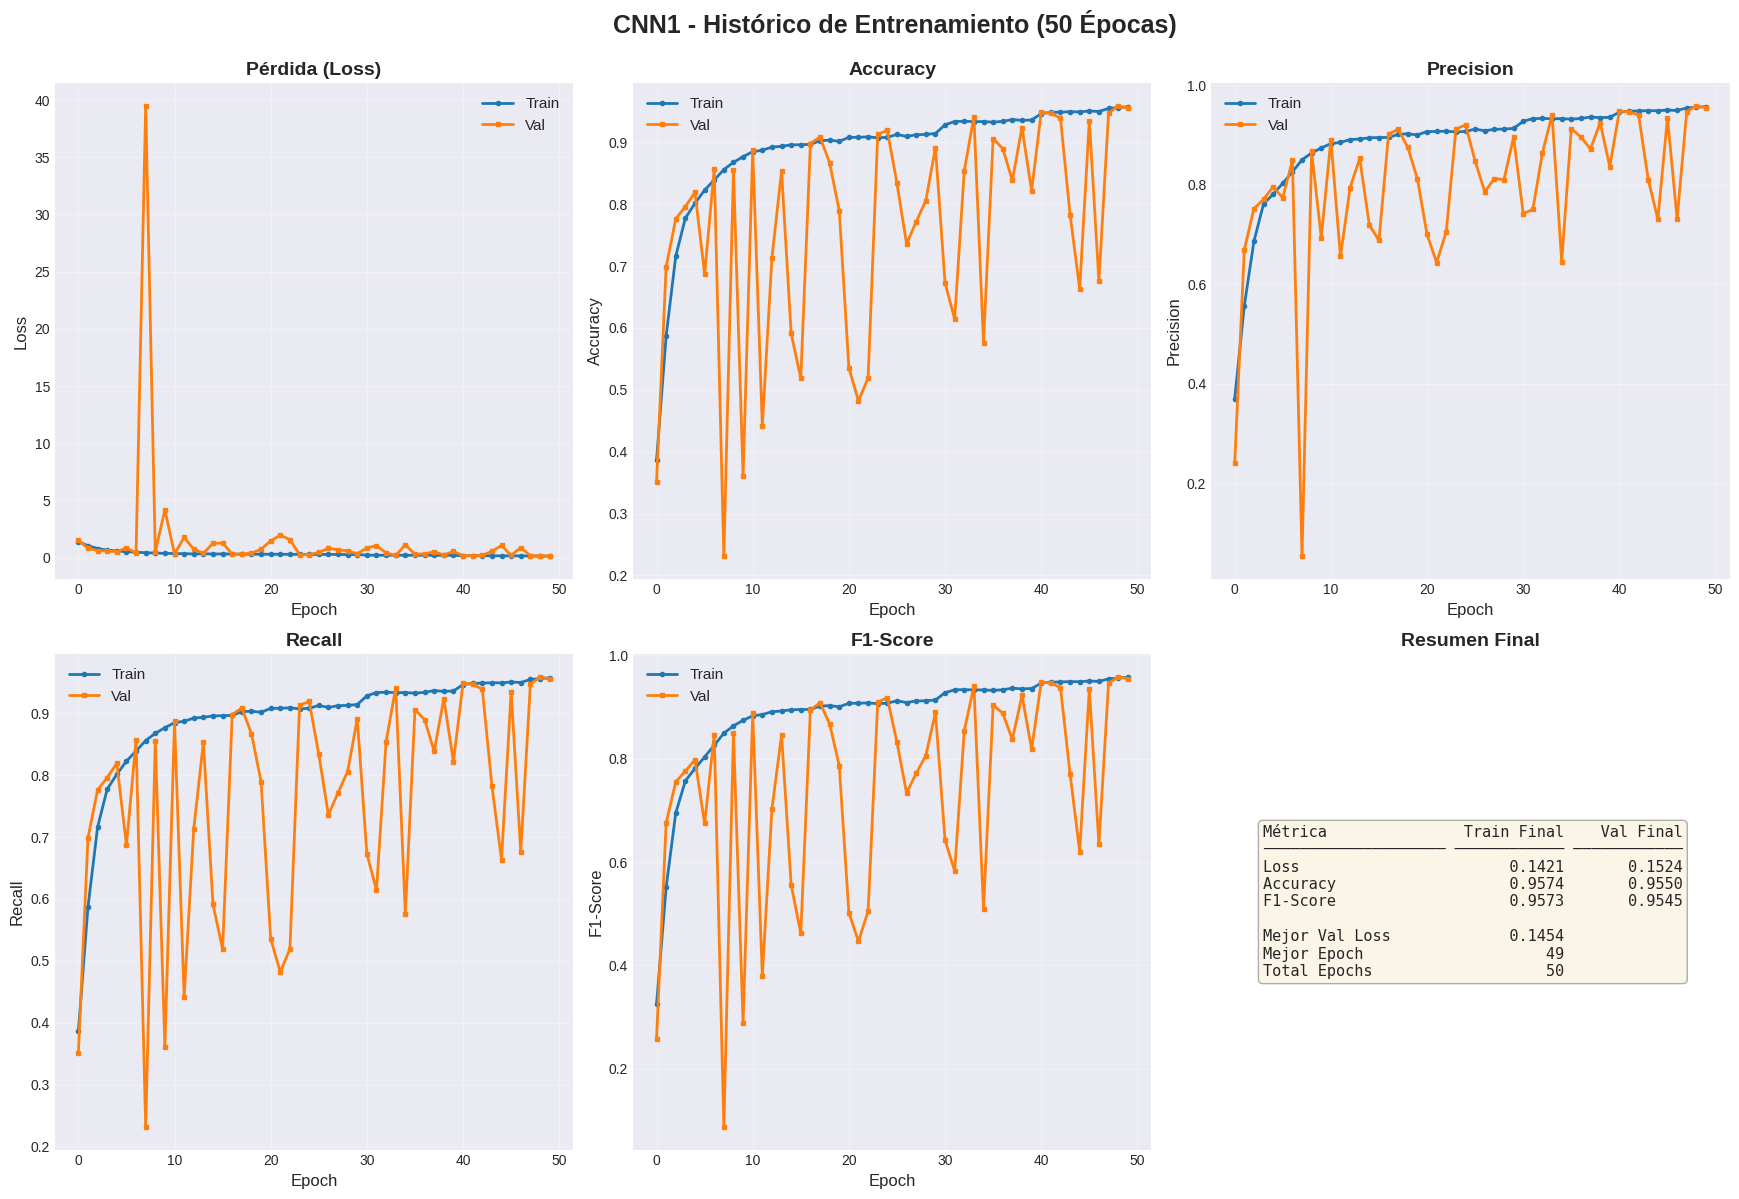

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')

# Crear figura con 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('CNN1 - Histórico de Entrenamiento (50 Épocas)', fontsize=18, fontweight='bold', y=0.995)

# Colores consistentes
train_color = '#1f77b4'  # Azul
val_color = '#ff7f0e'    # Naranja

# ===== GRÁFICO 1: PÉRDIDA =====
axes[0, 0].plot(training_history_cnn1['train']['loss'],
                label='Train', color=train_color, linewidth=2, marker='o', markersize=3)
axes[0, 0].plot(training_history_cnn1['val']['loss'],
                label='Val', color=val_color, linewidth=2, marker='s', markersize=3)
axes[0, 0].set_title('Pérdida (Loss)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# ===== GRÁFICO 2: ACCURACY =====
axes[0, 1].plot(training_history_cnn1['train']['accuracy'],
                label='Train', color=train_color, linewidth=2, marker='o', markersize=3)
axes[0, 1].plot(training_history_cnn1['val']['accuracy'],
                label='Val', color=val_color, linewidth=2, marker='s', markersize=3)
axes[0, 1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# ===== GRÁFICO 3: PRECISION =====
axes[0, 2].plot(training_history_cnn1['train']['precision'],
                label='Train', color=train_color, linewidth=2, marker='o', markersize=3)
axes[0, 2].plot(training_history_cnn1['val']['precision'],
                label='Val', color=val_color, linewidth=2, marker='s', markersize=3)
axes[0, 2].set_title('Precision', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch', fontsize=12)
axes[0, 2].set_ylabel('Precision', fontsize=12)
axes[0, 2].legend(fontsize=11)
axes[0, 2].grid(True, alpha=0.3)

# ===== GRÁFICO 4: RECALL =====
axes[1, 0].plot(training_history_cnn1['train']['recall'],
                label='Train', color=train_color, linewidth=2, marker='o', markersize=3)
axes[1, 0].plot(training_history_cnn1['val']['recall'],
                label='Val', color=val_color, linewidth=2, marker='s', markersize=3)
axes[1, 0].set_title('Recall', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Recall', fontsize=12)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# ===== GRÁFICO 5: F1-SCORE =====
axes[1, 1].plot(training_history_cnn1['train']['f1'],
                label='Train', color=train_color, linewidth=2, marker='o', markersize=3)
axes[1, 1].plot(training_history_cnn1['val']['f1'],
                label='Val', color=val_color, linewidth=2, marker='s', markersize=3)
axes[1, 1].set_title('F1-Score', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('F1-Score', fontsize=12)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# ===== GRÁFICO 6: TABLA DE RESUMEN =====
# Eliminar ejes del subplot
axes[1, 2].axis('off')

# Obtener métricas finales
final_train_loss = training_history_cnn1['train']['loss'][-1]
final_train_acc = training_history_cnn1['train']['accuracy'][-1]
final_train_f1 = training_history_cnn1['train']['f1'][-1]

final_val_loss = training_history_cnn1['val']['loss'][-1]
final_val_acc = training_history_cnn1['val']['accuracy'][-1]
final_val_f1 = training_history_cnn1['val']['f1'][-1]

# Mejor val loss
best_val_loss = min(training_history_cnn1['val']['loss'])
best_epoch = training_history_cnn1['val']['loss'].index(best_val_loss) + 1

# Crear tabla
table_data = [
    ['Métrica', 'Train Final', 'Val Final'],
    ['─' * 20, '─' * 12, '─' * 12],
    ['Loss', f'{final_train_loss:.4f}', f'{final_val_loss:.4f}'],
    ['Accuracy', f'{final_train_acc:.4f}', f'{final_val_acc:.4f}'],
    ['F1-Score', f'{final_train_f1:.4f}', f'{final_val_f1:.4f}'],
    ['', '', ''],
    ['Mejor Val Loss', f'{best_val_loss:.4f}', ''],
    ['Mejor Epoch', f'{best_epoch}', ''],
    ['Total Epochs', f'{len(training_history_cnn1["train"]["loss"])}', ''],
]

# Dibujar tabla
table_text = '\n'.join([f'{row[0]:<20} {row[1]:>12} {row[2]:>12}' for row in table_data])
axes[1, 2].text(0.1, 0.5, table_text,
                fontsize=11, fontfamily='monospace',
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

axes[1, 2].set_title('Resumen Final', fontsize=14, fontweight='bold')

# Ajustar layout
plt.tight_layout()

# Guardar gráfico
output_path = f'{Config.OUTPUT_DIR}/cnn1_training_history_50epochs.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f" Gráfico guardado en: {output_path}")

# Mostrar
plt.show()


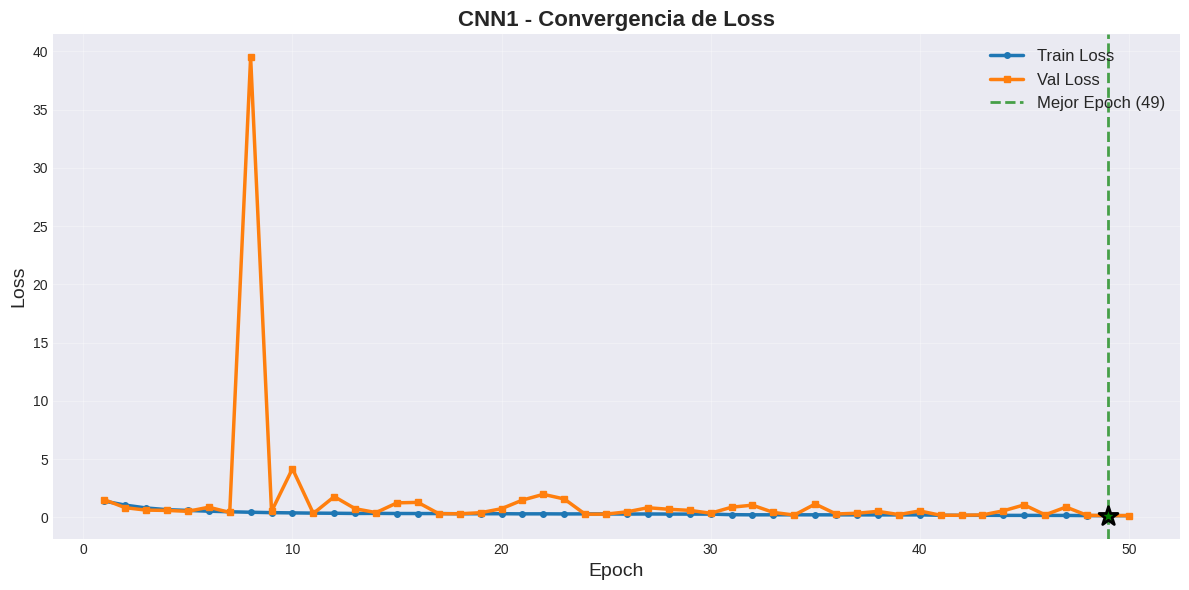

 Gráfico de convergencia guardado


In [ ]:
# Gráfico enfocado en convergencia
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

epochs = list(range(1, len(training_history_cnn1['train']['loss']) + 1))

ax.plot(epochs, training_history_cnn1['train']['loss'],
        label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o', markersize=4)
ax.plot(epochs, training_history_cnn1['val']['loss'],
        label='Val Loss', color='#ff7f0e', linewidth=2.5, marker='s', markersize=4)

# Marcar mejor epoch
best_val_loss = min(training_history_cnn1['val']['loss'])
best_epoch = training_history_cnn1['val']['loss'].index(best_val_loss) + 1
ax.axvline(x=best_epoch, color='green', linestyle='--', linewidth=2, alpha=0.7,
           label=f'Mejor Epoch ({best_epoch})')
ax.scatter([best_epoch], [best_val_loss], color='green', s=200, zorder=5,
           marker='*', edgecolors='black', linewidths=2)

ax.set_title('CNN1 - Convergencia de Loss', fontsize=16, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('Loss', fontsize=14)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{Config.OUTPUT_DIR}/cnn1_loss_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Gráfico de convergencia guardado")



VISUALIZACIÓN DE RESULTADOS CNN1



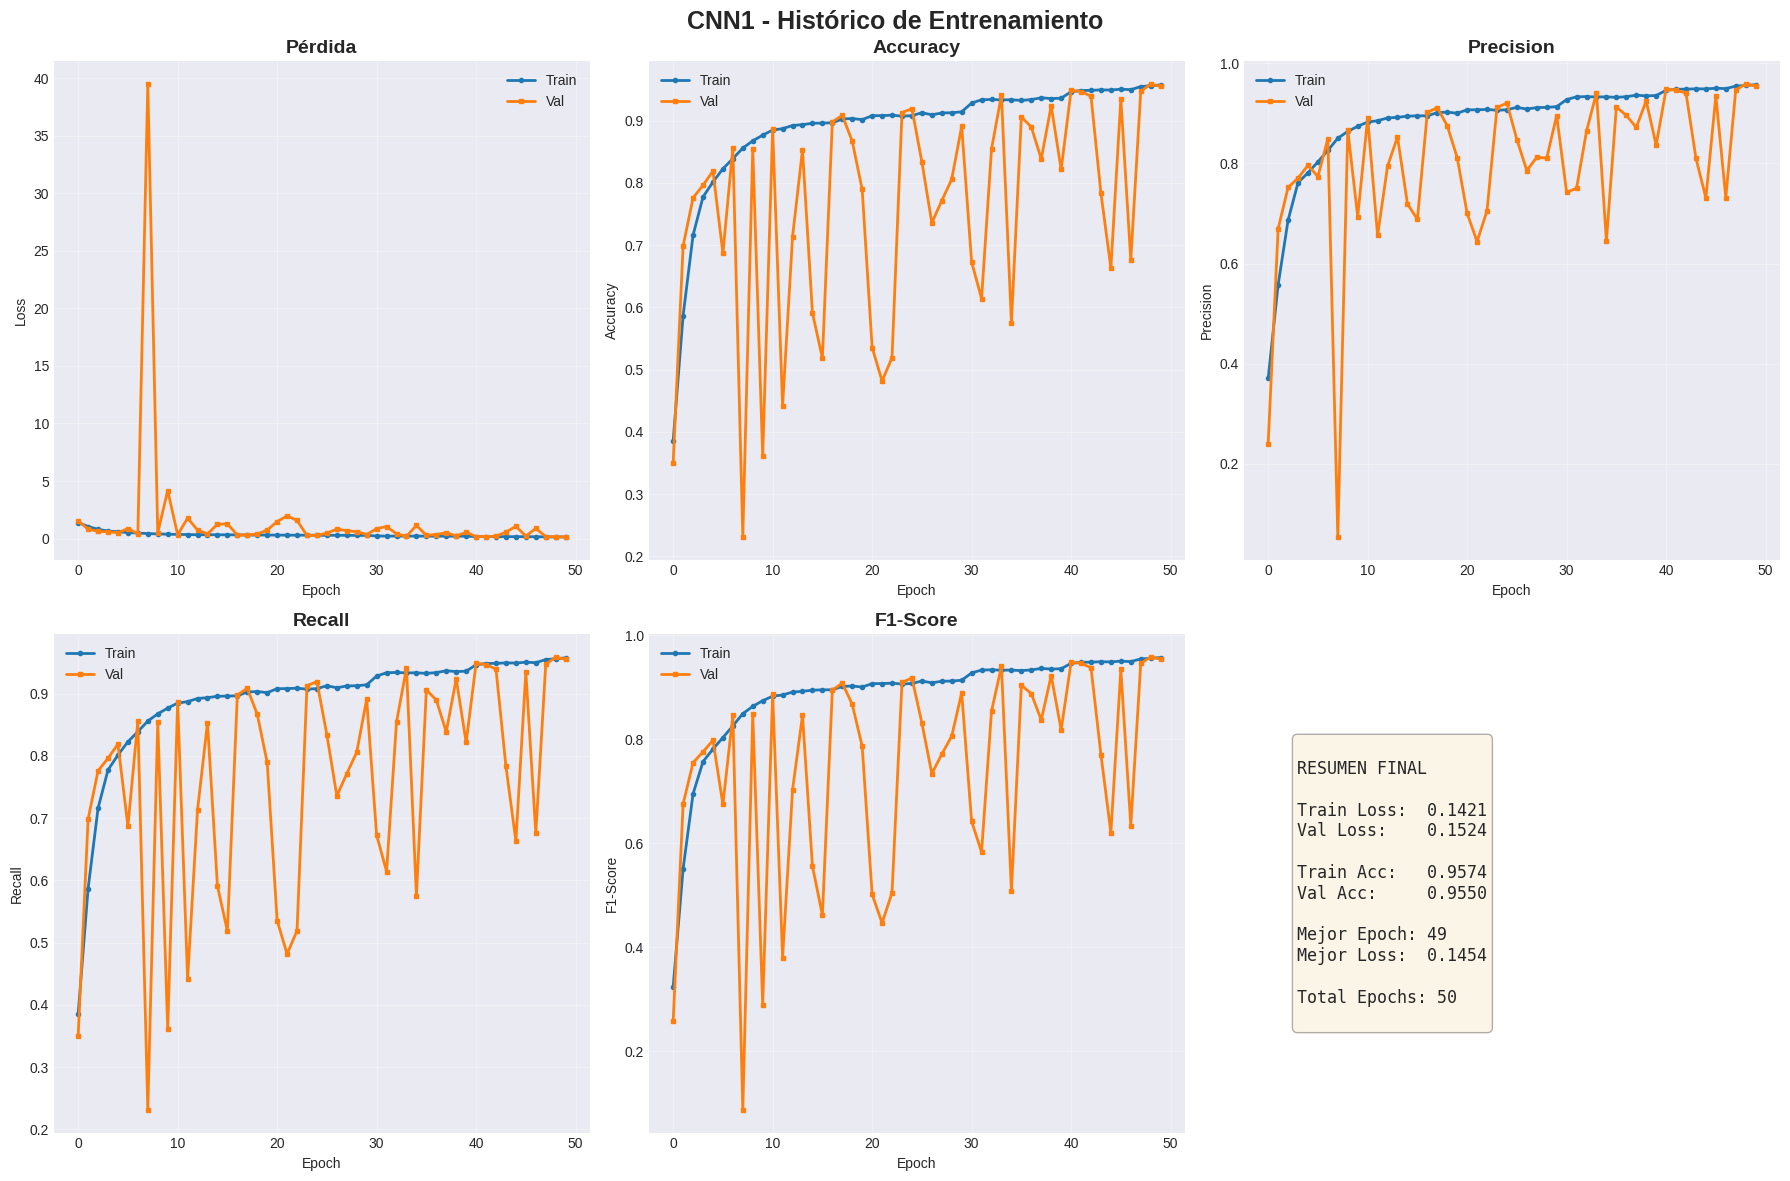

 Gráfico guardado en: results/cnn1_training_complete.png

ANÁLISIS AUTOMÁTICO

 MEJOR MODELO: Epoch 49
   Val Loss: 0.1454
   Val Accuracy: 0.9589

FINAL:
   Val Accuracy: 95.50%
   Train-Val Gap: 0.24%


In [ ]:
# ===== VISUALIZACIÓN COMPLETA CNN1 =====
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Obtener histórico
training_history_cnn1 = trainer_quick.get_training_history()

print(f"\n{'='*80}")
print(f"VISUALIZACIÓN DE RESULTADOS CNN1")
print(f"{'='*80}\n")

# ===== GRÁFICO PRINCIPAL =====
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('CNN1 - Histórico de Entrenamiento', fontsize=18, fontweight='bold')

train_color = '#1f77b4'
val_color = '#ff7f0e'

# Loss
axes[0, 0].plot(training_history_cnn1['train']['loss'], label='Train', color=train_color, linewidth=2, marker='o', markersize=3)
axes[0, 0].plot(training_history_cnn1['val']['loss'], label='Val', color=val_color, linewidth=2, marker='s', markersize=3)
axes[0, 0].set_title('Pérdida', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(training_history_cnn1['train']['accuracy'], label='Train', color=train_color, linewidth=2, marker='o', markersize=3)
axes[0, 1].plot(training_history_cnn1['val']['accuracy'], label='Val', color=val_color, linewidth=2, marker='s', markersize=3)
axes[0, 1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[0, 2].plot(training_history_cnn1['train']['precision'], label='Train', color=train_color, linewidth=2, marker='o', markersize=3)
axes[0, 2].plot(training_history_cnn1['val']['precision'], label='Val', color=val_color, linewidth=2, marker='s', markersize=3)
axes[0, 2].set_title('Precision', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Recall
axes[1, 0].plot(training_history_cnn1['train']['recall'], label='Train', color=train_color, linewidth=2, marker='o', markersize=3)
axes[1, 0].plot(training_history_cnn1['val']['recall'], label='Val', color=val_color, linewidth=2, marker='s', markersize=3)
axes[1, 0].set_title('Recall', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# F1-Score
axes[1, 1].plot(training_history_cnn1['train']['f1'], label='Train', color=train_color, linewidth=2, marker='o', markersize=3)
axes[1, 1].plot(training_history_cnn1['val']['f1'], label='Val', color=val_color, linewidth=2, marker='s', markersize=3)
axes[1, 1].set_title('F1-Score', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Tabla resumen
axes[1, 2].axis('off')
best_val_loss = min(training_history_cnn1['val']['loss'])
best_epoch = training_history_cnn1['val']['loss'].index(best_val_loss) + 1

table_data = f"""
RESUMEN FINAL

Train Loss:  {training_history_cnn1['train']['loss'][-1]:.4f}
Val Loss:    {training_history_cnn1['val']['loss'][-1]:.4f}

Train Acc:   {training_history_cnn1['train']['accuracy'][-1]:.4f}
Val Acc:     {training_history_cnn1['val']['accuracy'][-1]:.4f}

Mejor Epoch: {best_epoch}
Mejor Loss:  {best_val_loss:.4f}

Total Epochs: {len(training_history_cnn1['train']['loss'])}
"""

axes[1, 2].text(0.1, 0.5, table_data, fontsize=12, fontfamily='monospace',
                verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig(f'{Config.OUTPUT_DIR}/cnn1_training_complete.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Gráfico guardado en: {Config.OUTPUT_DIR}/cnn1_training_complete.png\n")

# ===== ANÁLISIS AUTOMÁTICO =====
print(f"{'='*80}")
print(f"ANÁLISIS AUTOMÁTICO")
print(f"{'='*80}\n")

print(f" MEJOR MODELO: Epoch {best_epoch}")
print(f"   Val Loss: {best_val_loss:.4f}")
print(f"   Val Accuracy: {training_history_cnn1['val']['accuracy'][best_epoch-1]:.4f}")

print(f"\nFINAL:")
print(f"   Val Accuracy: {training_history_cnn1['val']['accuracy'][-1]*100:.2f}%")
print(f"   Train-Val Gap: {(training_history_cnn1['train']['accuracy'][-1] - training_history_cnn1['val']['accuracy'][-1])*100:.2f}%")




## Construccion del modelo CNN2 - Anomalia

> Crear MURADatasetAnomalía para ANOMALÍA

In [ ]:
class MURADatasetAnomalía(Dataset):
    """
    Dataset para CNN2: Clasificación de ANOMALÍA (Normal vs Anormal)

    Diferencias con CNN1:
    - Label: is_abnormal (0=Normal, 1=Anormal) en lugar de anatomía
    - Tarea: Clasificación binaria
    - Aplicar class weights por desbalance
    """

    def __init__(self, df_data, dataset_path, augmentation='train', apply_mixup=False, mixup_alpha=1.0):
        self.df_data = df_data.reset_index(drop=True)
        self.dataset_path = Path(dataset_path)
        self.augmentation = augmentation
        self.apply_mixup = apply_mixup
        self.mixup_alpha = mixup_alpha

        self.transforms = self._build_transforms(augmentation)

        # Estadísticas de clase
        self.normal_count = (~self.df_data['is_abnormal']).sum()
        self.abnormal_count = self.df_data['is_abnormal'].sum()

        logger.log(f" Inicializando MURADatasetAnomalía")
        logger.log(f"   Imágenes: {len(self.df_data):,}")
        logger.log(f"   Normal: {self.normal_count:,} ({self.normal_count/len(self.df_data)*100:.1f}%)")
        logger.log(f"   Anormal: {self.abnormal_count:,} ({self.abnormal_count/len(self.df_data)*100:.1f}%)")
        logger.log(f"   Tarea: Clasificación de ANOMALÍA (2 clases)")
        logger.log(f"   Augmentation: {augmentation}")

    def _build_transforms(self, augmentation_type):
        """Pipeline de transformaciones"""
        base_transforms = [
            A.Resize(Config.IMAGE_SIZE, Config.IMAGE_SIZE),
            A.Normalize(mean=0.5, std=0.5, always_apply=True),
            ToTensorV2(),
        ]

        if augmentation_type == 'train' and Config.AUGMENTATION_ENABLED:
            augmentation_transforms = [
                A.Rotate(limit=20, p=0.5),  # ← CORRECCIÓN: A.Rotate (no RandomRotate2D)
                A.HorizontalFlip(p=0.3), # CORRECCIÓN: Cambiado de A.Flip a A.HorizontalFlip
                A.RandomBrightnessContrast(p=0.2),
            ]
            return A.Compose(augmentation_transforms + base_transforms)
        else:
            return A.Compose(base_transforms)

    def __len__(self):
        return len(self.df_data)

    def __getitem__(self, idx):
        """Retorna imagen y etiqueta de ANOMALÍA (Normal=0, Anormal=1)"""
        max_retries = 3

        for attempt in range(max_retries):
            try:
                row = self.df_data.iloc[idx]

                img_path = row['image_path']
                img_path = Path(img_path)  # ← CONVERTIR A Path

                # Saltar archivos de sistema
                if img_path.name.startswith('._') or '._' in str(img_path):
                    idx = (idx + 1) % len(self.df_data)
                    continue

                image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)  # ← Convertir a string para cv2

                if image is None:
                    idx = (idx + 1) % len(self.df_data)
                    continue

                image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
                transformed = self.transforms(image=image)
                image_tensor = transformed['image']

                # ← DIFERENCIA: Usar is_abnormal (0=Normal, 1=Anormal)
                label = int(row['is_abnormal'])

                metadata = {
                    'image_path': str(img_path),
                    'patient_id': str(row['patient_id']),
                    'anatomy': row['anatomy'],
                    'study_id': str(row['study_id']),
                    'label_name': 'Anormal' if label == 1 else 'Normal',
                }

                return image_tensor, label, metadata

            except Exception as e:
                if attempt == max_retries - 1:
                    raise
                idx = (idx + 1) % len(self.df_data)

        raise ValueError(f"No se pudo cargar ninguna imagen después de {max_retries} intentos")


# ===== CREAR DATASETS CNN2 =====
logger.log(f"\n{'='*80}")
logger.log(f"CONSTRUCCIÓN DE CNN2 ")
logger.log(f"{'='*80}\n")

logger.log(f"Creando datasets para CNN2 (Clasificación de Anomalía)...\n")

train_dataset_cnn2 = MURADatasetAnomalía(df_train, Config.DATASET_PATH_FINAL, augmentation='train', apply_mixup=True)
val_dataset_cnn2 = MURADatasetAnomalía(df_val, Config.DATASET_PATH_FINAL, augmentation='val', apply_mixup=False)
test_dataset_cnn2 = MURADatasetAnomalía(df_test, Config.DATASET_PATH_FINAL, augmentation=None, apply_mixup=False)

logger.log(f"\n Datasets CNN2 creados\n")

[2025-11-21 19:05:14] [INFO] 
[2025-11-21 19:05:14] [INFO] CONSTRUCCIÓN DE CNN2 
[2025-11-21 19:05:14] [INFO] ================================================================================

[2025-11-21 19:05:14] [INFO] Creando datasets para CNN2 (Clasificación de Anomalía)...

[2025-11-21 19:05:14] [INFO]  Inicializando MURADatasetAnomalía
[2025-11-21 19:05:14] [INFO]    Imágenes: 28,076
[2025-11-21 19:05:14] [INFO]    Normal: 16,538 (58.9%)
[2025-11-21 19:05:14] [INFO]    Anormal: 11,538 (41.1%)
[2025-11-21 19:05:14] [INFO]    Tarea: Clasificación de ANOMALÍA (2 clases)
[2025-11-21 19:05:14] [INFO]    Augmentation: train
[2025-11-21 19:05:14] [INFO]  Inicializando MURADatasetAnomalía
[2025-11-21 19:05:14] [INFO]    Imágenes: 7,930
[2025-11-21 19:05:14] [INFO]    Normal: 4,673 (58.9%)
[2025-11-21 19:05:14] [INFO]    Anormal: 3,257 (41.1%)
[2025-11-21 19:05:14] [INFO]    Tarea: Clasificación de ANOMALÍA (2 clases)
[2025-11-21 19:05:14] [INFO]    Augmentation: val
[2025-11-21 19:05:14]

> Modelo para clasificación binaria

In [ ]:
class CNN2_BinaryClassifier(nn.Module):
    """
    Red neuronal CNN2 para clasificación binaria de anomalía
    Arquitectura más compacta que CNN1 (optimizada para 2 clases)

    Parámetros configurables:
    - hidden_dims: Capas fully connected (flexible)
    - dropout: Tasa de dropout
    - num_classes: Siempre 2 (Normal/Anormal)
    """

    def __init__(self, hidden_dims=None, dropout=0.3):
        super(CNN2_BinaryClassifier, self).__init__()

        if hidden_dims is None:
            hidden_dims = [256, 128]

        self.hidden_dims = hidden_dims
        self.dropout_rate = dropout
        self.num_classes = 2

        logger.log(f"CNN2_BinaryClassifier")
        logger.log(f"   Hidden dims: {hidden_dims}")
        logger.log(f"   Dropout: {dropout}")
        logger.log(f"   Num clases: 2 (Normal/Anormal)")

        # ===== CAPA INICIAL (más compacta que CNN1) =====
        self.conv_initial = nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn_initial = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # Output: (batch, 32, 56, 56)

        # ===== BLOQUES RESIDUALES (simplificados) =====
        self.layer1 = self._make_residual_layer(32, 64, num_blocks=2, stride=1)
        # Output: (batch, 64, 56, 56)

        self.layer2 = self._make_residual_layer(64, 128, num_blocks=3, stride=2)
        # Output: (batch, 128, 28, 28)

        self.layer3 = self._make_residual_layer(128, 256, num_blocks=3, stride=2)
        # Output: (batch, 256, 14, 14)

        # ===== GLOBAL AVERAGE POOLING =====
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # Output: (batch, 256, 1, 1)

        # ===== CAPAS FULLY CONNECTED (parametrizables) =====
        self.fc_layers = nn.Sequential()

        prev_dim = 256
        for i, hidden_dim in enumerate(hidden_dims):
            self.fc_layers.add_module(
                f'fc_{i}',
                nn.Linear(prev_dim, hidden_dim)
            )
            self.fc_layers.add_module(
                f'relu_{i}',
                nn.ReLU(inplace=True)
            )
            if dropout > 0:
                self.fc_layers.add_module(
                    f'dropout_{i}',
                    nn.Dropout(p=dropout)
                )
            prev_dim = hidden_dim

        # ===== CAPA OUTPUT (2 clases binarias) =====
        self.fc_output = nn.Linear(prev_dim, 2)

        # ===== INICIALIZACIÓN DE PESOS =====
        self._init_weights()

        logger.log(f"- CNN2_BinaryClassifier construida\n")

    def _make_residual_layer(self, in_channels, out_channels, num_blocks, stride=1):
        """Crea una capa de bloques residuales"""
        layers = []

        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers.append(
            ResidualBlock(in_channels, out_channels, stride=stride, downsample=downsample)
        )

        for _ in range(1, num_blocks):
            layers.append(
                ResidualBlock(out_channels, out_channels, stride=1, downsample=None)
            )

        return nn.Sequential(*layers)

    def _init_weights(self):
        """Inicialización He"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                init.constant_(m.weight, 1)
                init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                init.normal_(m.weight, std=0.01)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        """Forward pass"""
        x = self.conv_initial(x)
        x = self.bn_initial(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        x = self.fc_layers(x)
        x = self.fc_output(x)

        return x

    def get_model_summary(self):
        """Resumen del modelo"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)

        logger.log(f"\n{'='*80}")
        logger.log(f"RESUMEN DEL MODELO CNN2")
        logger.log(f"{'='*80}")
        logger.log(f"Total de parámetros: {total_params:,}")
        logger.log(f"Parámetros entrenables: {trainable_params:,}")
        logger.log(f"Tamaño aproximado: {(total_params * 4) / (1024**2):.2f} MB")
        logger.log(f"{'='*80}\n")

        return {
            'total_params': total_params,
            'trainable_params': trainable_params,
            'size_mb': (total_params * 4) / (1024**2)
        }


# ===== CREAR MODELO CNN2 =====
cnn2_model = CNN2_BinaryClassifier(
    hidden_dims=[256, 128],  # Configuración óptima
    dropout=0.3
).to(Config.DEVICE)

model_summary = cnn2_model.get_model_summary()

logger.log(f"CNN2 modelo creado\n")


[2025-11-21 19:05:17] [INFO] CNN2_BinaryClassifier
[2025-11-21 19:05:17] [INFO]    Hidden dims: [256, 128]
[2025-11-21 19:05:17] [INFO]    Dropout: 0.3
[2025-11-21 19:05:17] [INFO]    Num clases: 2 (Normal/Anormal)
[2025-11-21 19:05:17] [INFO] - CNN2_BinaryClassifier construida

[2025-11-21 19:05:17] [INFO] 
[2025-11-21 19:05:17] [INFO] RESUMEN DEL MODELO CNN2
[2025-11-21 19:05:17] [INFO] ================================================================================
[2025-11-21 19:05:17] [INFO] Total de parámetros: 4,336,802
[2025-11-21 19:05:17] [INFO] Parámetros entrenables: 4,336,802
[2025-11-21 19:05:17] [INFO] Tamaño aproximado: 16.54 MB
[2025-11-21 19:05:17] [INFO] ================================================================================

[2025-11-21 19:05:17] [INFO] CNN2 modelo creado



In [ ]:
# ===== CREAR DATALOADERS CNN2 =====
logger.log(f"Creando DataLoaders para CNN2...\n")

collate_train = MURACollateFunction(apply_mixup=True, mixup_alpha=Config.MIXUP_ALPHA)
collate_val = MURACollateFunction(apply_mixup=False)
collate_test = MURACollateFunction(apply_mixup=False)

train_loader_cnn2 = DataLoader(
    train_dataset_cnn2,
    batch_size=32,  # Configuración óptima
    shuffle=True,
    num_workers=Config.NUM_WORKERS,
    pin_memory=Config.PIN_MEMORY,
    collate_fn=collate_train,
    drop_last=True,
)

val_loader_cnn2 = DataLoader(
    val_dataset_cnn2,
    batch_size=32,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=Config.PIN_MEMORY,
    collate_fn=collate_val,
    drop_last=False,
)

test_loader_cnn2 = DataLoader(
    test_dataset_cnn2,
    batch_size=32,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=Config.PIN_MEMORY,
    collate_fn=collate_test,
    drop_last=False,
)

logger.log(f" DataLoaders creados\n")


[2025-11-21 19:05:21] [INFO] Creando DataLoaders para CNN2...

[2025-11-21 19:05:21] [INFO]  DataLoaders creados



In [ ]:
logger.log(f"{'='*80}")
logger.log(f"SETUP TRAINING CNN2")
logger.log(f"{'='*80}\n")

# ===== CALCULAR CLASS WEIGHTS (para desbalance) =====
normal_weight = train_dataset_cnn2.abnormal_count / len(train_dataset_cnn2)
abnormal_weight = train_dataset_cnn2.normal_count / len(train_dataset_cnn2)
class_weights = torch.tensor([normal_weight, abnormal_weight], dtype=torch.float32).to(Config.DEVICE)

logger.log(f"Class Weights (para desbalance):")
logger.log(f"  Normal weight: {normal_weight:.4f}")
logger.log(f"  Abnormal weight: {abnormal_weight:.4f}\n")

# ===== LOSS FUNCTION =====
criterion_cnn2 = nn.CrossEntropyLoss(weight=class_weights)
logger.log(f"- Loss Function: CrossEntropyLoss con class weights\n")

# ===== OPTIMIZER =====
optimizer_cnn2 = optim.Adam(
    cnn2_model.parameters(),
    lr=0.001,  # Configuración óptima
    weight_decay=1e-4
)

logger.log(f"- Optimizer: Adam")
logger.log(f"   Learning Rate: 0.001")
logger.log(f"   Weight Decay: 1e-4\n")

# ===== SCHEDULER =====
scheduler_cnn2 = ReduceLROnPlateau(
    optimizer_cnn2,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

logger.log(f"- Scheduler: ReduceLROnPlateau")
logger.log(f"{'='*80}\n")


[2025-11-21 19:05:24] [INFO] ================================================================================
[2025-11-21 19:05:24] [INFO] SETUP TRAINING CNN2
[2025-11-21 19:05:24] [INFO] ================================================================================

[2025-11-21 19:05:24] [INFO] Class Weights (para desbalance):
[2025-11-21 19:05:24] [INFO]   Normal weight: 0.4110
[2025-11-21 19:05:24] [INFO]   Abnormal weight: 0.5890

[2025-11-21 19:05:24] [INFO] - Loss Function: CrossEntropyLoss con class weights

[2025-11-21 19:05:24] [INFO] - Optimizer: Adam
[2025-11-21 19:05:24] [INFO]    Learning Rate: 0.001
[2025-11-21 19:05:24] [INFO]    Weight Decay: 1e-4

[2025-11-21 19:05:24] [INFO] - Scheduler: ReduceLROnPlateau
[2025-11-21 19:05:24] [INFO] ================================================================================



In [ ]:
class CNN2Trainer:
    """Entrenador para CNN2 con métricas para clasificación binaria"""

    def __init__(self, model, criterion, optimizer, scheduler, device):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device

        self.train_history = {
            'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []
        }
        self.val_history = {
            'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []
        }

        self.best_val_loss = float('inf')
        self.best_model_state = None
        self.patience_counter = 0

        logger.log(f" CNN2Trainer inicializado")

    def train_epoch(self, train_loader):
        """Entrena un epoch"""
        self.model.train()

        all_logits = []
        all_targets = []
        total_loss = 0.0

        pbar = tqdm(train_loader, desc="Train", leave=False)

        for batch in pbar:
            images = batch['images'].to(self.device)
            labels = batch['labels'].to(self.device)

            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item()
            all_logits.append(outputs.detach().cpu())
            all_targets.append(labels.detach().cpu())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        all_logits = torch.cat(all_logits, dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        # Para clasificación binaria: usar probabilidades de clase 1
        probas = torch.softmax(all_logits, dim=1)[:, 1].numpy()
        predictions = torch.argmax(all_logits, dim=1).numpy()
        targets = all_targets.numpy()

        metrics = {
            'loss': total_loss / len(train_loader),
            'accuracy': accuracy_score(targets, predictions),
            'precision': precision_score(targets, predictions, zero_division=0),
            'recall': recall_score(targets, predictions, zero_division=0),
            'f1': f1_score(targets, predictions, zero_division=0),
            'auc': roc_auc_score(targets, probas) if len(set(targets)) > 1 else 0.0
        }

        return metrics

    def val_epoch(self, val_loader):
        """Valida un epoch"""
        self.model.eval()

        all_logits = []
        all_targets = []
        total_loss = 0.0

        with torch.no_grad():
            pbar = tqdm(val_loader, desc="Val", leave=False)

            for batch in pbar:
                images = batch['images'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                total_loss += loss.item()
                all_logits.append(outputs.cpu())
                all_targets.append(labels.cpu())

                pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        all_logits = torch.cat(all_logits, dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        probas = torch.softmax(all_logits, dim=1)[:, 1].numpy()
        predictions = torch.argmax(all_logits, dim=1).numpy()
        targets = all_targets.numpy()

        metrics = {
            'loss': total_loss / len(val_loader),
            'accuracy': accuracy_score(targets, predictions),
            'precision': precision_score(targets, predictions, zero_division=0),
            'recall': recall_score(targets, predictions, zero_division=0),
            'f1': f1_score(targets, predictions, zero_division=0),
            'auc': roc_auc_score(targets, probas) if len(set(targets)) > 1 else 0.0
        }

        return metrics

    def fit(self, train_loader, val_loader, epochs=50, early_stopping_patience=10):
        """Entrena el modelo"""
        logger.log(f"\n{'='*80}")
        logger.log(f"ENTRENAMIENTO DE CNN2")
        logger.log(f"{'='*80}\n")

        logger.log(f"Configuración:")
        logger.log(f"   Epochs: {epochs}")
        logger.log(f"   Early Stopping Patience: {early_stopping_patience}")
        logger.log(f"   Device: {self.device}")
        logger.log(f"\n")

        for epoch in range(1, epochs + 1):
            logger.log(f"\n{'─'*80}")
            logger.log(f"EPOCH {epoch}/{epochs}")
            logger.log(f"{'─'*80}")

            train_metrics = self.train_epoch(train_loader)
            val_metrics = self.val_epoch(val_loader)

            for key in self.train_history:
                self.train_history[key].append(train_metrics[key])
                self.val_history[key].append(val_metrics[key])

            logger.log(f"\n- TRAIN Metrics:")
            logger.log(f"   Loss: {train_metrics['loss']:.4f}")
            logger.log(f"   Accuracy: {train_metrics['accuracy']:.4f}")
            logger.log(f"   Precision: {train_metrics['precision']:.4f}")
            logger.log(f"   Recall: {train_metrics['recall']:.4f}")
            logger.log(f"   F1-Score: {train_metrics['f1']:.4f}")
            logger.log(f"   AUC-ROC: {train_metrics['auc']:.4f}")

            logger.log(f"\n- VAL Metrics:")
            logger.log(f"   Loss: {val_metrics['loss']:.4f}")
            logger.log(f"   Accuracy: {val_metrics['accuracy']:.4f}")
            logger.log(f"   Precision: {val_metrics['precision']:.4f}")
            logger.log(f"   Recall: {val_metrics['recall']:.4f}")
            logger.log(f"   F1-Score: {val_metrics['f1']:.4f}")
            logger.log(f"   AUC-ROC: {val_metrics['auc']:.4f}")

            self.scheduler.step(val_metrics['loss'])

            if val_metrics['loss'] < self.best_val_loss:
                self.best_val_loss = val_metrics['loss']
                self.best_model_state = self.model.state_dict().copy()
                self.patience_counter = 0
                logger.log(f"\n- Mejor modelo guardado (val_loss: {self.best_val_loss:.4f})")
            else:
                self.patience_counter += 1
                logger.log(f"\n- Sin mejora ({self.patience_counter}/{early_stopping_patience})")

                if self.patience_counter >= early_stopping_patience:
                    logger.log(f"\n- Early stopping activado")
                    break

        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
            logger.log(f"\n- Mejor modelo restaurado")

        logger.log(f"\n{'='*80}")
        logger.log(f"ENTRENAMIENTO COMPLETADO")
        logger.log(f"{'='*80}\n")

    def save_model(self, output_dir=None):
        """Guarda el modelo entrenado"""
        if output_dir is None:
            output_dir = Config.OUTPUT_DIR

        output_dir = Path(output_dir)
        model_dir = output_dir / 'models'
        model_dir.mkdir(parents=True, exist_ok=True)

        model_path = model_dir / 'cnn2_best_model.pth'

        torch.save({
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'best_val_loss': self.best_val_loss,
            'config': {
                'hidden_dims': [256, 128],
                'dropout': 0.3,
            }
        }, model_path)

        logger.log(f"- Modelo guardado en: {model_path}")
        return model_path

    def get_training_history(self):
        """Retorna histórico de entrenamiento"""
        return {
            'train': self.train_history,
            'val': self.val_history
        }


# ===== INSTANCIAR TRAINER =====
trainer_cnn2 = CNN2Trainer(
    model=cnn2_model,
    criterion=criterion_cnn2,
    optimizer=optimizer_cnn2,
    scheduler=scheduler_cnn2,
    device=Config.DEVICE
)

print(f"- CNN2Trainer instanciado\n")


[2025-11-21 19:05:27] [INFO]  CNN2Trainer inicializado
- CNN2Trainer instanciado



In [ ]:
# @title
# ===== ENTRENAR CNN2 =====
logger.log(f"\n{'='*80}")
logger.log(f"ENTRENAMIENTO DE CNN2")
logger.log(f"{'='*80}\n")

trainer_cnn2.fit(
    train_loader=train_loader_cnn2,
    val_loader=val_loader_cnn2,
    epochs=50,  # Ajusta según necesites (5 para debug, 50+ para producción)
    early_stopping_patience=10
)

# Obtener histórico
training_history_cnn2 = trainer_cnn2.get_training_history()

# Guardar modelo
model_path_cnn2 = trainer_cnn2.save_model(output_dir=Config.OUTPUT_DIR)

logger.log(f"\n CNN2 ENTRENAMIENTO COMPLETADO EXITOSAMENTE\n")


[2025-11-21 17:46:08] [INFO] 
[2025-11-21 17:46:08] [INFO] ENTRENAMIENTO DE CNN2
[2025-11-21 17:46:08] [INFO] ================================================================================

[2025-11-21 17:46:08] [INFO] 
[2025-11-21 17:46:08] [INFO] ENTRENAMIENTO DE CNN2
[2025-11-21 17:46:08] [INFO] ================================================================================

[2025-11-21 17:46:08] [INFO] Configuración:
[2025-11-21 17:46:08] [INFO]    Epochs: 5
[2025-11-21 17:46:08] [INFO]    Early Stopping Patience: 10
[2025-11-21 17:46:08] [INFO]    Device: cuda
[2025-11-21 17:46:08] [INFO] 

[2025-11-21 17:46:08] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 17:46:08] [INFO] EPOCH 1/5
[2025-11-21 17:46:08] [INFO] ────────────────────────────────────────────────────────────────────────────────


KeyboardInterrupt: 

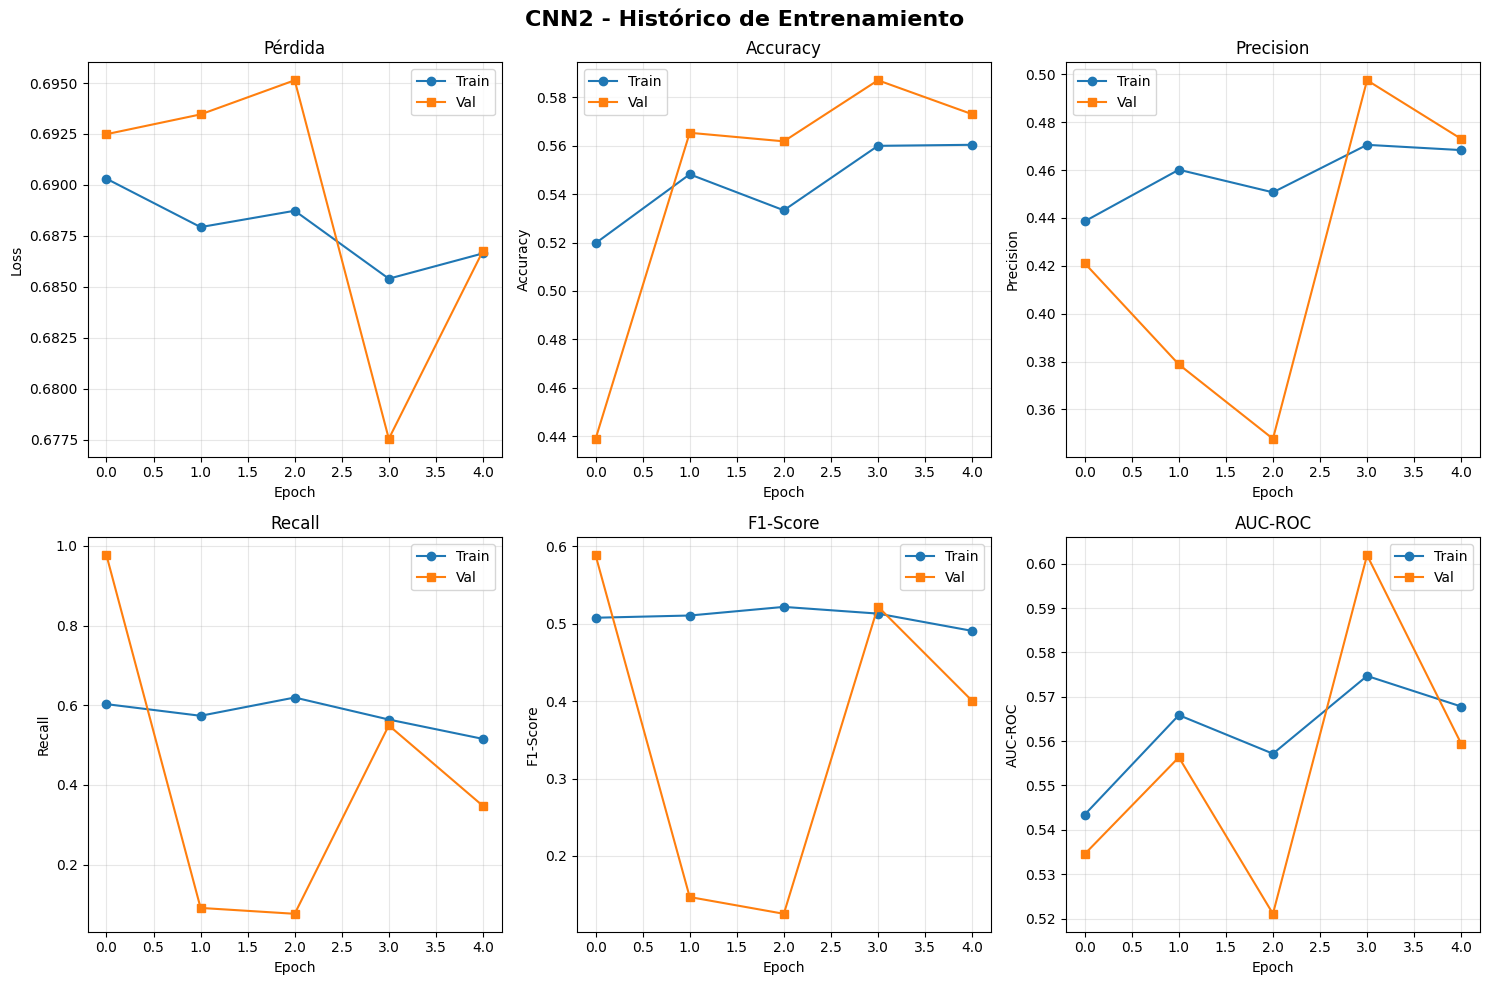

✅ Gráfico guardado como: cnn2_training_history.png


In [ ]:
# @title
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('CNN2 - Histórico de Entrenamiento', fontsize=16, fontweight='bold')

# Pérdida
axes[0, 0].plot(training_history_cnn2['train']['loss'], label='Train', marker='o')
axes[0, 0].plot(training_history_cnn2['val']['loss'], label='Val', marker='s')
axes[0, 0].set_title('Pérdida')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(training_history_cnn2['train']['accuracy'], label='Train', marker='o')
axes[0, 1].plot(training_history_cnn2['val']['accuracy'], label='Val', marker='s')
axes[0, 1].set_title('Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[0, 2].plot(training_history_cnn2['train']['precision'], label='Train', marker='o')
axes[0, 2].plot(training_history_cnn2['val']['precision'], label='Val', marker='s')
axes[0, 2].set_title('Precision')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Recall
axes[1, 0].plot(training_history_cnn2['train']['recall'], label='Train', marker='o')
axes[1, 0].plot(training_history_cnn2['val']['recall'], label='Val', marker='s')
axes[1, 0].set_title('Recall')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# F1-Score
axes[1, 1].plot(training_history_cnn2['train']['f1'], label='Train', marker='o')
axes[1, 1].plot(training_history_cnn2['val']['f1'], label='Val', marker='s')
axes[1, 1].set_title('F1-Score')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# AUC-ROC
axes[1, 2].plot(training_history_cnn2['train']['auc'], label='Train', marker='o')
axes[1, 2].plot(training_history_cnn2['val']['auc'], label='Val', marker='s')
axes[1, 2].set_title('AUC-ROC')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('AUC-ROC')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{Config.OUTPUT_DIR}/cnn2_training_history.png', dpi=150)
plt.show()

print("✅ Gráfico guardado como: cnn2_training_history.png")


In [ ]:
# Actualizar Config
Config.CNN2_LEARNING_RATE = 0.0005  # REDUCIR
CNN2_EPOCHS = 50              # AUMENTAR

# Recrear Optimizer con nuevo LR
optimizer_cnn2_v2 = optim.Adam(
    cnn2_model.parameters(),
    lr=Config.CNN2_LEARNING_RATE,  # Nuevo: 0.0005
    weight_decay=1e-4
)

# Recrear Scheduler
scheduler_cnn2_v2 = ReduceLROnPlateau(
    optimizer_cnn2_v2,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

# Recrear Trainer
trainer_cnn2_v2 = CNN2Trainer(
    model=cnn2_model,
    criterion=criterion_cnn2,
    optimizer=optimizer_cnn2_v2,
    scheduler=scheduler_cnn2_v2,
    device=Config.DEVICE
)

# Entrenar
trainer_cnn2_v2.fit(
    train_loader=train_loader_cnn2,
    val_loader=val_loader_cnn2,
    epochs= CNN2_EPOCHS ,  # Aumentado
    early_stopping_patience=10
)

# Guardar
model_path_cnn2_v2 = trainer_cnn2_v2.save_model()


[2025-11-21 19:06:29] [INFO]  CNN2Trainer inicializado
[2025-11-21 19:06:29] [INFO] 
[2025-11-21 19:06:29] [INFO] ENTRENAMIENTO DE CNN2
[2025-11-21 19:06:29] [INFO] ================================================================================

[2025-11-21 19:06:29] [INFO] Configuración:
[2025-11-21 19:06:29] [INFO]    Epochs: 50
[2025-11-21 19:06:29] [INFO]    Early Stopping Patience: 10
[2025-11-21 19:06:29] [INFO]    Device: cuda
[2025-11-21 19:06:29] [INFO] 

[2025-11-21 19:06:29] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:06:29] [INFO] EPOCH 1/50
[2025-11-21 19:06:29] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 19:07:14] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:07:14] [INFO]    Loss: 0.6880
[2025-11-21 19:07:14] [INFO]    Accuracy: 0.5392
[2025-11-21 19:07:14] [INFO]    Precision: 0.4548
[2025-11-21 19:07:14] [INFO]    Recall: 0.6090
[2025-11-21 19:07:14] [INFO]    F1-Score: 0.5207
[2025-11-21 19:07:14] [INFO]    AUC-ROC: 0.5642
[2025-11-21 19:07:14] [INFO] 
- VAL Metrics:
[2025-11-21 19:07:14] [INFO]    Loss: 0.7021
[2025-11-21 19:07:14] [INFO]    Accuracy: 0.5361
[2025-11-21 19:07:14] [INFO]    Precision: 0.4552
[2025-11-21 19:07:14] [INFO]    Recall: 0.6577
[2025-11-21 19:07:14] [INFO]    F1-Score: 0.5380
[2025-11-21 19:07:14] [INFO]    AUC-ROC: 0.5776
[2025-11-21 19:07:14] [INFO] 
- Mejor modelo guardado (val_loss: 0.7021)
[2025-11-21 19:07:14] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:07:14] [INFO] EPOCH 2/50
[2025-11-21 19:07:14] [INFO] ───────────────────────────────────────────────────────────────────────────────

[2025-11-21 19:07:57] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:07:57] [INFO]    Loss: 0.6864
[2025-11-21 19:07:57] [INFO]    Accuracy: 0.5566
[2025-11-21 19:07:57] [INFO]    Precision: 0.4666
[2025-11-21 19:07:57] [INFO]    Recall: 0.5532
[2025-11-21 19:07:57] [INFO]    F1-Score: 0.5062
[2025-11-21 19:07:57] [INFO]    AUC-ROC: 0.5693
[2025-11-21 19:07:57] [INFO] 
- VAL Metrics:
[2025-11-21 19:07:57] [INFO]    Loss: 0.6879
[2025-11-21 19:07:57] [INFO]    Accuracy: 0.5240
[2025-11-21 19:07:57] [INFO]    Precision: 0.4469
[2025-11-21 19:07:57] [INFO]    Recall: 0.6699
[2025-11-21 19:07:57] [INFO]    F1-Score: 0.5362
[2025-11-21 19:07:57] [INFO]    AUC-ROC: 0.5790
[2025-11-21 19:07:57] [INFO] 
- Mejor modelo guardado (val_loss: 0.6879)
[2025-11-21 19:07:57] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:07:57] [INFO] EPOCH 3/50
[2025-11-21 19:07:57] [INFO] ───────────────────────────────────────────────────────────────────────────────

[2025-11-21 19:08:41] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:08:41] [INFO]    Loss: 0.6800
[2025-11-21 19:08:41] [INFO]    Accuracy: 0.5754
[2025-11-21 19:08:41] [INFO]    Precision: 0.4853
[2025-11-21 19:08:41] [INFO]    Recall: 0.5488
[2025-11-21 19:08:41] [INFO]    F1-Score: 0.5151
[2025-11-21 19:08:41] [INFO]    AUC-ROC: 0.5939
[2025-11-21 19:08:41] [INFO] 
- VAL Metrics:
[2025-11-21 19:08:41] [INFO]    Loss: 1.4726
[2025-11-21 19:08:41] [INFO]    Accuracy: 0.4303
[2025-11-21 19:08:41] [INFO]    Precision: 0.4156
[2025-11-21 19:08:41] [INFO]    Recall: 0.9527
[2025-11-21 19:08:41] [INFO]    F1-Score: 0.5787
[2025-11-21 19:08:41] [INFO]    AUC-ROC: 0.5777
[2025-11-21 19:08:41] [INFO] 
- Sin mejora (1/10)
[2025-11-21 19:08:41] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:08:41] [INFO] EPOCH 4/50
[2025-11-21 19:08:41] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 19:09:24] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:09:24] [INFO]    Loss: 0.6737
[2025-11-21 19:09:24] [INFO]    Accuracy: 0.5773
[2025-11-21 19:09:24] [INFO]    Precision: 0.4880
[2025-11-21 19:09:24] [INFO]    Recall: 0.5794
[2025-11-21 19:09:24] [INFO]    F1-Score: 0.5298
[2025-11-21 19:09:24] [INFO]    AUC-ROC: 0.6104
[2025-11-21 19:09:24] [INFO] 
- VAL Metrics:
[2025-11-21 19:09:24] [INFO]    Loss: 0.6717
[2025-11-21 19:09:24] [INFO]    Accuracy: 0.5527
[2025-11-21 19:09:24] [INFO]    Precision: 0.4701
[2025-11-21 19:09:24] [INFO]    Recall: 0.6994
[2025-11-21 19:09:24] [INFO]    F1-Score: 0.5623
[2025-11-21 19:09:24] [INFO]    AUC-ROC: 0.6142
[2025-11-21 19:09:24] [INFO] 
- Mejor modelo guardado (val_loss: 0.6717)
[2025-11-21 19:09:24] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:09:24] [INFO] EPOCH 5/50
[2025-11-21 19:09:24] [INFO] ───────────────────────────────────────────────────────────────────────────────

...

[2025-11-21 19:39:52] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:39:52] [INFO]    Loss: 0.4566
[2025-11-21 19:39:52] [INFO]    Accuracy: 0.7955
[2025-11-21 19:39:52] [INFO]    Precision: 0.7676
[2025-11-21 19:39:52] [INFO]    Recall: 0.7205
[2025-11-21 19:39:52] [INFO]    F1-Score: 0.7433
[2025-11-21 19:39:52] [INFO]    AUC-ROC: 0.8608
[2025-11-21 19:39:52] [INFO] 
- VAL Metrics:
[2025-11-21 19:39:52] [INFO]    Loss: 0.5345
[2025-11-21 19:39:52] [INFO]    Accuracy: 0.7291
[2025-11-21 19:39:52] [INFO]    Precision: 0.6419
[2025-11-21 19:39:52] [INFO]    Recall: 0.7700
[2025-11-21 19:39:52] [INFO]    F1-Score: 0.7002
[2025-11-21 19:39:52] [INFO]    AUC-ROC: 0.8218
[2025-11-21 19:39:52] [INFO] 
- Sin mejora (2/10)
[2025-11-21 19:39:52] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:39:52] [INFO] EPOCH 47/50
[2025-11-21 19:39:52] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 19:40:36] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:40:36] [INFO]    Loss: 0.4560
[2025-11-21 19:40:36] [INFO]    Accuracy: 0.7975
[2025-11-21 19:40:36] [INFO]    Precision: 0.7706
[2025-11-21 19:40:36] [INFO]    Recall: 0.7221
[2025-11-21 19:40:36] [INFO]    F1-Score: 0.7455
[2025-11-21 19:40:36] [INFO]    AUC-ROC: 0.8620
[2025-11-21 19:40:36] [INFO] 
- VAL Metrics:
[2025-11-21 19:40:36] [INFO]    Loss: 0.5100
[2025-11-21 19:40:36] [INFO]    Accuracy: 0.7740
[2025-11-21 19:40:36] [INFO]    Precision: 0.7477
[2025-11-21 19:40:36] [INFO]    Recall: 0.6788
[2025-11-21 19:40:36] [INFO]    F1-Score: 0.7116
[2025-11-21 19:40:36] [INFO]    AUC-ROC: 0.8271
[2025-11-21 19:40:36] [INFO] 
- Mejor modelo guardado (val_loss: 0.5100)
[2025-11-21 19:40:36] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:40:36] [INFO] EPOCH 48/50
[2025-11-21 19:40:36] [INFO] ──────────────────────────────────────────────────────────────────────────────

[2025-11-21 19:41:19] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:41:19] [INFO]    Loss: 0.4540
[2025-11-21 19:41:19] [INFO]    Accuracy: 0.7981
[2025-11-21 19:41:19] [INFO]    Precision: 0.7722
[2025-11-21 19:41:19] [INFO]    Recall: 0.7215
[2025-11-21 19:41:19] [INFO]    F1-Score: 0.7460
[2025-11-21 19:41:19] [INFO]    AUC-ROC: 0.8628
[2025-11-21 19:41:19] [INFO] 
- VAL Metrics:
[2025-11-21 19:41:19] [INFO]    Loss: 0.5185
[2025-11-21 19:41:19] [INFO]    Accuracy: 0.7741
[2025-11-21 19:41:19] [INFO]    Precision: 0.7629
[2025-11-21 19:41:19] [INFO]    Recall: 0.6531
[2025-11-21 19:41:19] [INFO]    F1-Score: 0.7037
[2025-11-21 19:41:19] [INFO]    AUC-ROC: 0.8246
[2025-11-21 19:41:19] [INFO] 
- Sin mejora (1/10)
[2025-11-21 19:41:19] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:41:19] [INFO] EPOCH 49/50
[2025-11-21 19:41:19] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 19:42:03] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:42:03] [INFO]    Loss: 0.4516
[2025-11-21 19:42:03] [INFO]    Accuracy: 0.8010
[2025-11-21 19:42:03] [INFO]    Precision: 0.7729
[2025-11-21 19:42:03] [INFO]    Recall: 0.7305
[2025-11-21 19:42:03] [INFO]    F1-Score: 0.7511
[2025-11-21 19:42:03] [INFO]    AUC-ROC: 0.8645
[2025-11-21 19:42:03] [INFO] 
- VAL Metrics:
[2025-11-21 19:42:03] [INFO]    Loss: 0.5246
[2025-11-21 19:42:03] [INFO]    Accuracy: 0.7482
[2025-11-21 19:42:03] [INFO]    Precision: 0.6816
[2025-11-21 19:42:03] [INFO]    Recall: 0.7261
[2025-11-21 19:42:03] [INFO]    F1-Score: 0.7031
[2025-11-21 19:42:03] [INFO]    AUC-ROC: 0.8209
[2025-11-21 19:42:03] [INFO] 
- Sin mejora (2/10)
[2025-11-21 19:42:03] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 19:42:03] [INFO] EPOCH 50/50
[2025-11-21 19:42:03] [INFO] ────────────────────────────────────────────────────────────────────────────────


[2025-11-21 19:42:47] [INFO] 
- TRAIN Metrics:
[2025-11-21 19:42:47] [INFO]    Loss: 0.4521
[2025-11-21 19:42:47] [INFO]    Accuracy: 0.7985
[2025-11-21 19:42:47] [INFO]    Precision: 0.7664
[2025-11-21 19:42:47] [INFO]    Recall: 0.7330
[2025-11-21 19:42:47] [INFO]    F1-Score: 0.7493
[2025-11-21 19:42:47] [INFO]    AUC-ROC: 0.8649
[2025-11-21 19:42:47] [INFO] 
- VAL Metrics:
[2025-11-21 19:42:47] [INFO]    Loss: 0.5125
[2025-11-21 19:42:47] [INFO]    Accuracy: 0.7637
[2025-11-21 19:42:47] [INFO]    Precision: 0.7227
[2025-11-21 19:42:47] [INFO]    Recall: 0.6890
[2025-11-21 19:42:47] [INFO]    F1-Score: 0.7054
[2025-11-21 19:42:47] [INFO]    AUC-ROC: 0.8227
[2025-11-21 19:42:47] [INFO] 
- Sin mejora (3/10)
[2025-11-21 19:42:47] [INFO] 
- Mejor modelo restaurado
[2025-11-21 19:42:47] [INFO] 
[2025-11-21 19:42:47] [INFO] ENTRENAMIENTO COMPLETADO
[2025-11-21 19:42:47] [INFO] ================================================================================

[2025-11-21 19:42:47] [INFO] - 

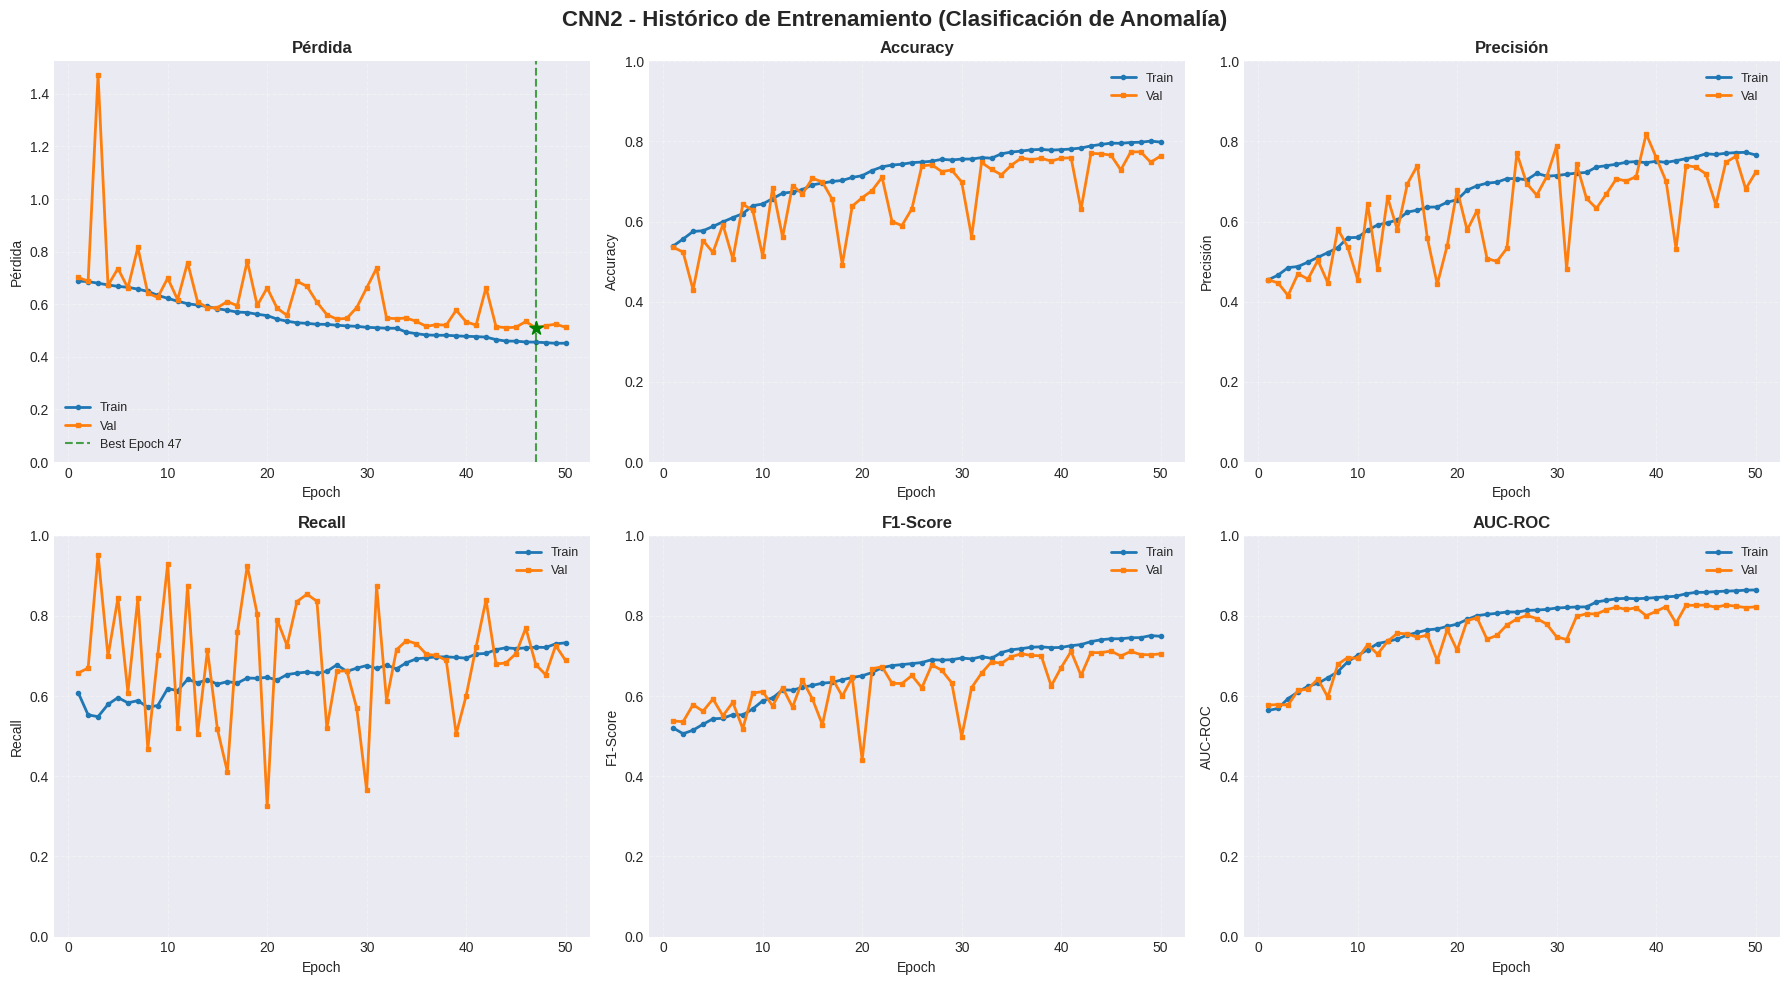

✅ Gráfico guardado en: results/cnn2_training_history_complete.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener histórico de entrenamiento
training_history_cnn2 = trainer_cnn2_v2.get_training_history()

# Crear figura con 6 subplots (2 filas × 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CNN2 - Histórico de Entrenamiento (Clasificación de Anomalía)',
             fontsize=16, fontweight='bold')

# Lista de métricas
metrics = ['loss', 'accuracy', 'precision', 'recall', 'f1', 'auc']
titles = ['Pérdida', 'Accuracy', 'Precisión', 'Recall', 'F1-Score', 'AUC-ROC']

# Iterar sobre cada métrica
for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    # Obtener datos
    train_data = training_history_cnn2['train'][metric]
    val_data = training_history_cnn2['val'][metric]
    epochs_range = range(1, len(train_data) + 1)

    # Plotear
    ax.plot(epochs_range, train_data, label='Train', marker='o',
            markersize=3, linewidth=2, color='#1f77b4')
    ax.plot(epochs_range, val_data, label='Val', marker='s',
            markersize=3, linewidth=2, color='#ff7f0e')

    # Marcar mejor epoch (menor val_loss)
    if metric == 'loss':
        best_epoch = np.argmin(val_data) + 1
        best_value = np.min(val_data)
        ax.axvline(x=best_epoch, color='green', linestyle='--',
                  linewidth=1.5, alpha=0.7, label=f'Best Epoch {best_epoch}')
        ax.scatter(best_epoch, best_value, color='green', s=100,
                  zorder=5, marker='*')

    # Configuración del subplot
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Límites del eje Y
    if metric == 'loss':
        ax.set_ylim(bottom=0)
    else:
        ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f'{Config.OUTPUT_DIR}/cnn2_training_history_complete.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Gráfico guardado en: {Config.OUTPUT_DIR}/cnn2_training_history_complete.png")


## Evaluacion en test set

In [ ]:
# ===== DEBUG: Ver estructura exacta =====
import torch

logger.log(f"Inspeccionando archivos guardados...\n")

cnn1_ckpt = torch.load('results/models/cnn1_best_model.pth', map_location='cpu')
logger.log(f"CNN1 State Dict - Primeras 15 keys:\n")
for i, key in enumerate(list(cnn1_ckpt['model_state_dict'].keys())[:15]):
    logger.log(f"  {i}: {key}")

logger.log(f"\n")


[2025-11-21 19:49:53] [INFO] Inspeccionando archivos guardados...

[2025-11-21 19:49:53] [INFO] CNN1 State Dict - Primeras 15 keys:

[2025-11-21 19:49:53] [INFO]   0: conv_initial.weight
[2025-11-21 19:49:53] [INFO]   1: bn_initial.weight
[2025-11-21 19:49:53] [INFO]   2: bn_initial.bias
[2025-11-21 19:49:53] [INFO]   3: bn_initial.running_mean
[2025-11-21 19:49:53] [INFO]   4: bn_initial.running_var
[2025-11-21 19:49:53] [INFO]   5: bn_initial.num_batches_tracked
[2025-11-21 19:49:53] [INFO]   6: layer1.0.conv1.weight
[2025-11-21 19:49:53] [INFO]   7: layer1.0.bn1.weight
[2025-11-21 19:49:53] [INFO]   8: layer1.0.bn1.bias
[2025-11-21 19:49:53] [INFO]   9: layer1.0.bn1.running_mean
[2025-11-21 19:49:53] [INFO]   10: layer1.0.bn1.running_var
[2025-11-21 19:49:53] [INFO]   11: layer1.0.bn1.num_batches_tracked
[2025-11-21 19:49:53] [INFO]   12: layer1.0.conv2.weight
[2025-11-21 19:49:53] [INFO]   13: layer1.0.bn2.weight
[2025-11-21 19:49:53] [INFO]   14: layer1.0.bn2.bias
[2025-11-21 19:4

In [ ]:
# ===== VER TODAS LAS KEYS (especialmente las FC) =====
import torch

cnn1_ckpt = torch.load('results/models/cnn1_best_model.pth', map_location='cpu')
state_dict_keys = list(cnn1_ckpt['model_state_dict'].keys())

logger.log(f"Total de keys: {len(state_dict_keys)}\n")
logger.log(f"ÚLTIMAS 20 keys (las FC layers):\n")

for i, key in enumerate(state_dict_keys[-20:]):
    logger.log(f"  {len(state_dict_keys)-20+i}: {key}")


[2025-11-21 19:50:32] [INFO] Total de keys: 222

[2025-11-21 19:50:32] [INFO] ÚLTIMAS 20 keys (las FC layers):

[2025-11-21 19:50:32] [INFO]   202: layer4.1.bn2.running_var
[2025-11-21 19:50:32] [INFO]   203: layer4.1.bn2.num_batches_tracked
[2025-11-21 19:50:32] [INFO]   204: layer4.2.conv1.weight
[2025-11-21 19:50:32] [INFO]   205: layer4.2.bn1.weight
[2025-11-21 19:50:32] [INFO]   206: layer4.2.bn1.bias
[2025-11-21 19:50:32] [INFO]   207: layer4.2.bn1.running_mean
[2025-11-21 19:50:32] [INFO]   208: layer4.2.bn1.running_var
[2025-11-21 19:50:32] [INFO]   209: layer4.2.bn1.num_batches_tracked
[2025-11-21 19:50:32] [INFO]   210: layer4.2.conv2.weight
[2025-11-21 19:50:32] [INFO]   211: layer4.2.bn2.weight
[2025-11-21 19:50:32] [INFO]   212: layer4.2.bn2.bias
[2025-11-21 19:50:32] [INFO]   213: layer4.2.bn2.running_mean
[2025-11-21 19:50:32] [INFO]   214: layer4.2.bn2.running_var
[2025-11-21 19:50:32] [INFO]   215: layer4.2.bn2.num_batches_tracked
[2025-11-21 19:50:32] [INFO]   216: fc

In [ ]:
logger.log(f"\n{'='*80}")
logger.log(f"CARGANDO MODELOS ENTRENADOS (ESTRUCTURA CORRECTA)")
logger.log(f"{'='*80}\n")

# ===== CARGAR CNN1 =====
logger.log(f"Cargando CNN1...\n")

cnn1_best = CNN1_AnatomyClassifier(
    num_classes=7,
    hidden_dims=[256, 128],  # ← CORRECTO: misma estructura que el archivo guardado
    dropout=0.5
).to(Config.DEVICE)

cnn1_checkpoint = torch.load('results/models/cnn1_best_model.pth', map_location=Config.DEVICE)
cnn1_best.load_state_dict(cnn1_checkpoint['model_state_dict'])
cnn1_best.eval()

logger.log(f" CNN1 cargado exitosamente\n")

# ===== CARGAR CNN2 =====
logger.log(f"Cargando CNN2...\n")

cnn2_best = CNN2_BinaryClassifier(
    hidden_dims=[256, 128],
    dropout=0.3
).to(Config.DEVICE)

cnn2_checkpoint = torch.load('results/models/cnn2_best_model.pth', map_location=Config.DEVICE)
cnn2_best.load_state_dict(cnn2_checkpoint['model_state_dict'])
cnn2_best.eval()

logger.log(f" CNN2 cargado exitosamente\n")

logger.log(f"{'='*80}\n")


[2025-11-21 19:52:27] [INFO] 
[2025-11-21 19:52:27] [INFO] CARGANDO MODELOS ENTRENADOS (ESTRUCTURA CORRECTA)
[2025-11-21 19:52:27] [INFO] ================================================================================

[2025-11-21 19:52:27] [INFO] Cargando CNN1...

[2025-11-21 19:52:27] [INFO] 🧠 Construyendo CNN1_AnatomyClassifier
[2025-11-21 19:52:27] [INFO]    Num classes: 7
[2025-11-21 19:52:27] [INFO]    Hidden dims: [256, 128]
[2025-11-21 19:52:27] [INFO]    Dropout: 0.5
[2025-11-21 19:52:28] [INFO] ✅ CNN1_AnatomyClassifier construida

[2025-11-21 19:52:28] [INFO] ✅ CNN1 cargado exitosamente

[2025-11-21 19:52:28] [INFO] Cargando CNN2...

[2025-11-21 19:52:28] [INFO] ✅ CNN2 cargado exitosamente

[2025-11-21 19:52:28] [INFO] ================================================================================



In [ ]:
# Crear mapeo de anatomía a label
ANATOMY_MAP = {
    'XR_ELBOW': 0,
    'XR_FINGER': 1,
    'XR_FOREARM': 2,
    'XR_HAND': 3,
    'XR_HUMERUS': 4,
    'XR_SHOULDER': 5,
    'XR_WRIST': 6
}

# Agregar columna anatomy_label a df_test
df_test['anatomy_label'] = df_test['anatomy'].map(ANATOMY_MAP)

# Verificar que no hay valores faltantes
logger.log(f"Valores faltantes en anatomy_label: {df_test['anatomy_label'].isna().sum()}")
logger.log(f"Distribución de clases en test:")
logger.log(f"{df_test['anatomy_label'].value_counts().sort_index()}\n")

# Extraer solo la categoría anatómica sin 'XR_'
df_test['body_part'] = df_test['anatomy'].str.replace('XR_', '')

logger.log(f"Columnas actualizadas:")
logger.log(f"{df_test.columns.tolist()}\n")


[2025-11-21 20:04:18] [INFO] Valores faltantes en anatomy_label: 0
[2025-11-21 20:04:18] [INFO] Distribución de clases en test:
[2025-11-21 20:04:18] [INFO] anatomy_label
0    532
1    567
2    216
3    649
4    157
5    912
6    966
Name: count, dtype: int64

[2025-11-21 20:04:18] [INFO] Columnas actualizadas:
[2025-11-21 20:04:18] [INFO] ['anatomy', 'split', 'patient_id', 'study_id', 'image_name', 'image_path', 'is_abnormal', 'file_size_mb', 'split_partition', 'anatomy_label', 'body_part']



In [ ]:
# ================================================================================
# PASO 6: EVALUACIÓN EN TEST SET
# ================================================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    cohen_kappa_score, roc_curve
)
import json

logger.log(f"\n{'='*80}")
logger.log(f"PASO 6: EVALUACIÓN EN TEST SET")
logger.log(f"{'='*80}\n")

# ===== 1. COLLATE FUNCTION =====

class MURACollateFunction:
    """Collate function para DataLoader"""

    def __call__(self, batch):
        images = torch.stack([item['images'] for item in batch])
        labels = torch.tensor([item['labels'] for item in batch], dtype=torch.long)
        metadata = [item['metadata'] for item in batch]

        return {
            'images': images,
            'labels': labels,
            'metadata': metadata
        }

logger.log(f"MURACollateFunction definida\n")

# ===== 2. DATASET CLASSES =====

class MURADatasetAnatomy(Dataset):
    """Dataset para CNN1: Clasificación de Anatomía (7 clases)"""

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row['image_path']
        anatomy_label = row['anatomy_label']

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"No se pudo cargar la imagen: {image_path}")

        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        if self.transform:
            transformed = self.transform(image=image)
            image = transformed['image']

        return {
            'images': image,
            'labels': anatomy_label,
            'metadata': {
                'image_path': str(image_path),
                'anatomy': row['body_part'],
                'is_abnormal': int(row['is_abnormal'])
            }
        }



class MURADatasetAnomaly(Dataset):
    """Dataset para CNN2: Clasificación de Anomalía (2 clases)"""

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = row['image_path']
        is_abnormal = int(row['is_abnormal'])

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"No se pudo cargar la imagen: {image_path}")

        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        if self.transform:
            transformed = self.transform(image=image)
            image = transformed['image']

        return {
            'images': image,
            'labels': is_abnormal,
            'metadata': {
                'image_path': str(image_path),
                'anatomy': row['body_part'],
                'is_abnormal': is_abnormal
            }
        }

logger.log(f"MURADatasetAnatomy definida")
logger.log(f"MURADatasetAnomaly definida\n")

# ===== 3. VERIFICAR/RECREAR df_test =====

try:
    df_test.head()
    logger.log(f"df_test ya existe: {len(df_test)} imágenes\n")
except NameError:
    logger.log(f"df_test no existe, recreando...\n")

    with open('results/test_paths.json', 'r') as f:
        test_paths = json.load(f)

    df_test = df_processed[df_processed['image_path'].astype(str).isin(test_paths)].copy()
    logger.log(f"df_test recreado: {len(df_test)} imágenes\n")

# ===== 4. TRANSFORMACIONES DE TEST =====

test_transforms = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=0.5, std=0.5, always_apply=True),
    ToTensorV2(),
])

logger.log(f"Transformaciones de test creadas\n")

# ===== 5. CREAR DATASETS DE TEST =====

test_dataset_cnn1 = MURADatasetAnatomy(
    dataframe=df_test,
    transform=test_transforms
)

test_dataset_cnn2 = MURADatasetAnomaly(
    dataframe=df_test,
    transform=test_transforms
)

logger.log(f"Datasets de test creados:")
logger.log(f"   CNN1 Test: {len(test_dataset_cnn1)} imágenes")
logger.log(f"   CNN2 Test: {len(test_dataset_cnn2)} imágenes\n")

# ===== 6. CREAR DATALOADERS DE TEST =====

test_loader_cnn1 = DataLoader(
    test_dataset_cnn1,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=MURACollateFunction()
)

test_loader_cnn2 = DataLoader(
    test_dataset_cnn2,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=MURACollateFunction()
)

logger.log(f"DataLoaders de test creados:")
logger.log(f"   CNN1 Test Loader: {len(test_loader_cnn1)} batches")
logger.log(f"   CNN2 Test Loader: {len(test_loader_cnn2)} batches\n")

# ===== 7. CARGAR MODELOS ENTRENADOS =====

logger.log(f"Cargando modelos entrenados...\n")

# Cargar CNN1
cnn1_best = CNN1_AnatomyClassifier(
    num_classes=7,
    hidden_dims=[256, 128],
    dropout=0.5
).to(device)

cnn1_checkpoint = torch.load('results/models/cnn1_best_model.pth', map_location=device)
cnn1_best.load_state_dict(cnn1_checkpoint['model_state_dict'])
cnn1_best.eval()

logger.log(f"CNN1 cargado exitosamente")

# Cargar CNN2
cnn2_best = CNN2_BinaryClassifier(
    hidden_dims=[256, 128],
    dropout=0.3
).to(device)

cnn2_checkpoint = torch.load('results/models/cnn2_best_model.pth', map_location=device)
cnn2_best.load_state_dict(cnn2_checkpoint['model_state_dict'])
cnn2_best.eval()

logger.log(f"CNN2 cargado exitosamente\n")

logger.log(f"{'='*80}\n")


[2025-11-21 20:15:38] [INFO] 
[2025-11-21 20:15:38] [INFO] PASO 6: EVALUACIÓN EN TEST SET
[2025-11-21 20:15:38] [INFO] ================================================================================

[2025-11-21 20:15:38] [INFO] MURACollateFunction definida

[2025-11-21 20:15:38] [INFO] MURADatasetAnatomy definida
[2025-11-21 20:15:38] [INFO] MURADatasetAnomaly definida

[2025-11-21 20:15:38] [INFO] df_test ya existe: 3999 imágenes

[2025-11-21 20:15:38] [INFO] Transformaciones de test creadas

[2025-11-21 20:15:38] [INFO] Datasets de test creados:
[2025-11-21 20:15:38] [INFO]    CNN1 Test: 3999 imágenes
[2025-11-21 20:15:38] [INFO]    CNN2 Test: 3999 imágenes

[2025-11-21 20:15:38] [INFO] DataLoaders de test creados:
[2025-11-21 20:15:38] [INFO]    CNN1 Test Loader: 125 batches
[2025-11-21 20:15:38] [INFO]    CNN2 Test Loader: 125 batches

[2025-11-21 20:15:38] [INFO] Cargando modelos entrenados...

[2025-11-21 20:15:38] [INFO] 🧠 Construyendo CNN1_AnatomyClassifier
[2025-11-21 20:15:

> Evaluacion de CNN1 en test set

[2025-11-21 20:24:39] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 20:24:39] [INFO] 6.1 EVALUACIÓN CNN1 (ANATOMÍA) EN TEST SET
[2025-11-21 20:24:39] [INFO] ────────────────────────────────────────────────────────────────────────────────

[2025-11-21 20:24:39] [INFO] Evaluando CNN1 en Test Set...



[2025-11-21 20:24:49] [INFO] 
[2025-11-21 20:24:49] [INFO] CNN1 - RESULTADOS EN TEST SET
[2025-11-21 20:24:49] [INFO] ================================================================================

[2025-11-21 20:24:49] [INFO] Métricas Globales:
[2025-11-21 20:24:49] [INFO]    Accuracy: 0.7652
[2025-11-21 20:24:49] [INFO]    Balanced Accuracy: 0.6674
[2025-11-21 20:24:49] [INFO]    Precision (Macro): 0.6005
[2025-11-21 20:24:49] [INFO]    Recall (Macro): 0.6674
[2025-11-21 20:24:49] [INFO]    F1-Score (Macro): 0.6148
[2025-11-21 20:24:49] [INFO]    AUC-ROC (OvR): 0.9032
[2025-11-21 20:24:49] [INFO]    Cohen Kappa: 0.7141

[2025-11-21 20:24:49] [INFO] Classification Report:

              precision    recall  f1-score   support

       ELBOW     0.3797    0.9699    0.5457       532
      FINGER     0.9559    0.9559    0.9559       567
     FOREARM     0.9297    0.7963    0.8579       216
        HAND     0.0000    0.0000    0.0000       649
     HUMERUS     0.0000    0.0000    0.0000 

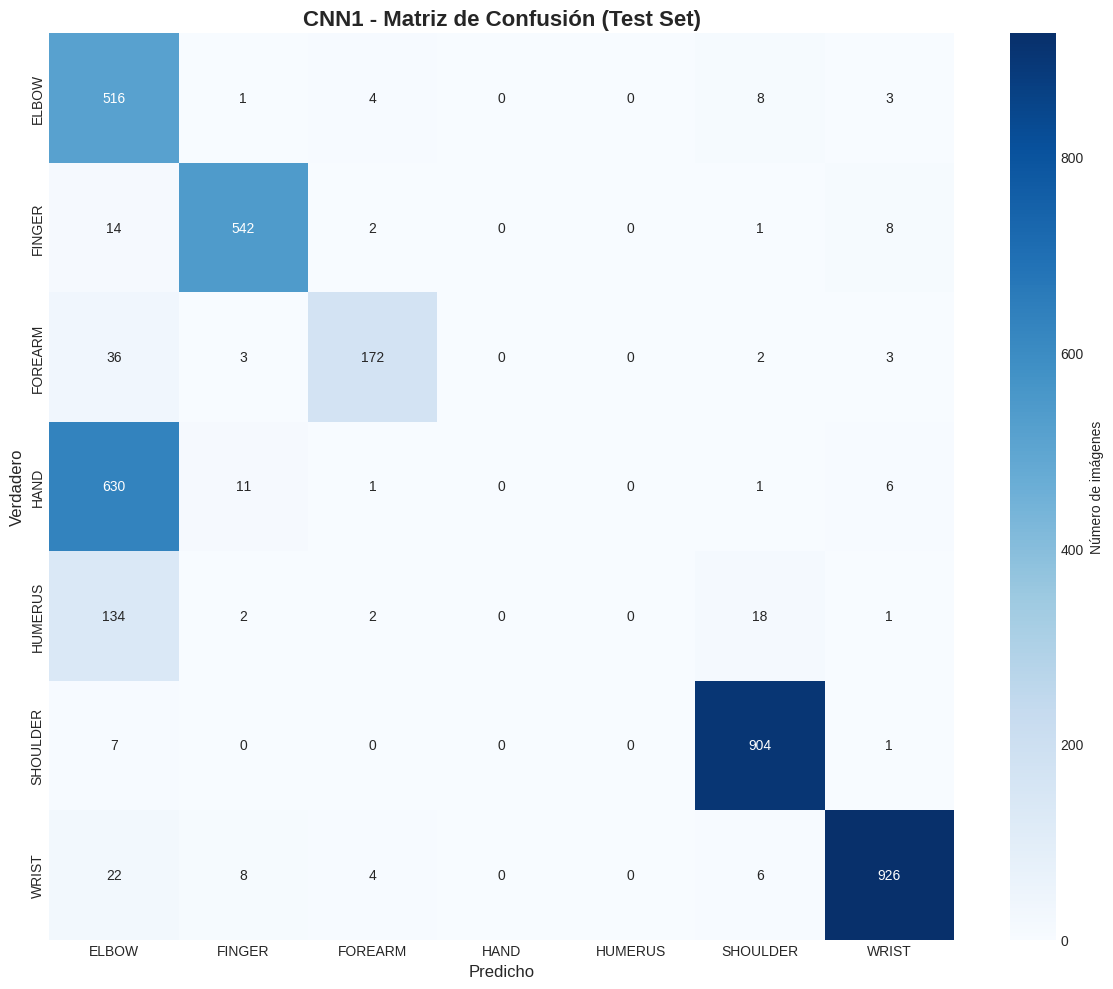

[2025-11-21 20:24:50] [INFO] 
Matriz de confusión guardada en: results/cnn1_confusion_matrix_test.png

[2025-11-21 20:24:50] [INFO] CNN1 evaluación completada



In [ ]:
# ============================================================================
# 6.1 EVALUACIÓN CNN1 (ANATOMÍA) EN TEST SET
# ===========================================================================

logger.log(f"\n{'─'*80}")
logger.log(f"6.1 EVALUACIÓN CNN1 (ANATOMÍA) EN TEST SET")
logger.log(f"{'─'*80}\n")

def evaluate_cnn1_test(model, test_loader, device, class_names):
    """
    Evalúa CNN1 en test set con métricas completas

    Args:
        model: Modelo CNN1 cargado
        test_loader: DataLoader de test
        device: Device (cuda/cpu)
        class_names: Lista con nombres de clases anatómicas

    Returns:
        dict: Diccionario con predicciones, labels, probabilidades y métricas
    """
    model.eval()

    all_preds = []
    all_labels = []
    all_probas = []

    logger.log(f"Evaluando CNN1 en Test Set...\n")

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="CNN1 Evaluation", leave=False):
            images = batch['images'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(images)
            probas = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probas = np.array(all_probas)

    # Calcular métricas
    accuracy = accuracy_score(all_labels, all_preds)
    precision_macro = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall_macro = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    recall_per_class = recall_score(all_labels, all_preds, average=None, zero_division=0)
    balanced_accuracy = np.mean(recall_per_class)

    kappa = cohen_kappa_score(all_labels, all_preds)

    try:
        auc_ovr = roc_auc_score(all_labels, all_probas, multi_class='ovr', average='macro')
    except:
        auc_ovr = 0.0

    # Imprimir resultados
    logger.log(f"\n{'='*80}")
    logger.log(f"CNN1 - RESULTADOS EN TEST SET")
    logger.log(f"{'='*80}\n")

    logger.log(f"Métricas Globales:")
    logger.log(f"   Accuracy: {accuracy:.4f}")
    logger.log(f"   Balanced Accuracy: {balanced_accuracy:.4f}")
    logger.log(f"   Precision (Macro): {precision_macro:.4f}")
    logger.log(f"   Recall (Macro): {recall_macro:.4f}")
    logger.log(f"   F1-Score (Macro): {f1_macro:.4f}")
    logger.log(f"   AUC-ROC (OvR): {auc_ovr:.4f}")
    logger.log(f"   Cohen Kappa: {kappa:.4f}\n")

    # Classification Report
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
    logger.log(f"Classification Report:\n")
    print(report)

    # Matriz de Confusión
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Número de imágenes'})
    plt.title('CNN1 - Matriz de Confusión (Test Set)', fontsize=16, fontweight='bold')
    plt.ylabel('Verdadero', fontsize=12)
    plt.xlabel('Predicho', fontsize=12)
    plt.tight_layout()
    plt.savefig('results/cnn1_confusion_matrix_test.png', dpi=150, bbox_inches='tight')
    plt.show()

    logger.log(f"\nMatriz de confusión guardada en: results/cnn1_confusion_matrix_test.png\n")

    return {
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probas,
        'metrics': {
            'accuracy': accuracy,
            'balanced_accuracy': balanced_accuracy,
            'precision': precision_macro,
            'recall': recall_macro,
            'f1': f1_macro,
            'auc': auc_ovr,
            'kappa': kappa
        }
    }


# Evaluar CNN1
ANATOMY_CLASSES = ['ELBOW', 'FINGER', 'FOREARM', 'HAND', 'HUMERUS', 'SHOULDER', 'WRIST']

cnn1_test_results = evaluate_cnn1_test(
    model=cnn1_best,
    test_loader=test_loader_cnn1,
    device=device,
    class_names=ANATOMY_CLASSES
)

logger.log(f"CNN1 evaluación completada\n")


> Evaluacion de CNN2 en test set

[2025-11-21 20:24:50] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 20:24:50] [INFO] 6.2 EVALUACIÓN CNN2 (ANOMALÍA) EN TEST SET
[2025-11-21 20:24:50] [INFO] ────────────────────────────────────────────────────────────────────────────────

[2025-11-21 20:24:50] [INFO] Evaluando CNN2 en Test Set...



[2025-11-21 20:25:00] [INFO] 
[2025-11-21 20:25:00] [INFO] CNN2 - RESULTADOS EN TEST SET
[2025-11-21 20:25:00] [INFO] ================================================================================

[2025-11-21 20:25:00] [INFO] Métricas Globales:
[2025-11-21 20:25:00] [INFO]    Accuracy: 0.7694
[2025-11-21 20:25:00] [INFO]    Balanced Accuracy: 0.7575
[2025-11-21 20:25:00] [INFO]    Precision: 0.7207
[2025-11-21 20:25:00] [INFO]    Recall (Sensitivity): 0.6965
[2025-11-21 20:25:00] [INFO]    Specificity: 0.8185
[2025-11-21 20:25:00] [INFO]    F1-Score: 0.7084
[2025-11-21 20:25:00] [INFO]    AUC-ROC: 0.8341
[2025-11-21 20:25:00] [INFO]    Cohen Kappa: 0.5179

[2025-11-21 20:25:00] [INFO] Matriz de Confusión:
[2025-11-21 20:25:00] [INFO]    True Negatives: 1957
[2025-11-21 20:25:00] [INFO]    False Positives: 434
[2025-11-21 20:25:00] [INFO]    False Negatives: 488
[2025-11-21 20:25:00] [INFO]    True Positives: 1120



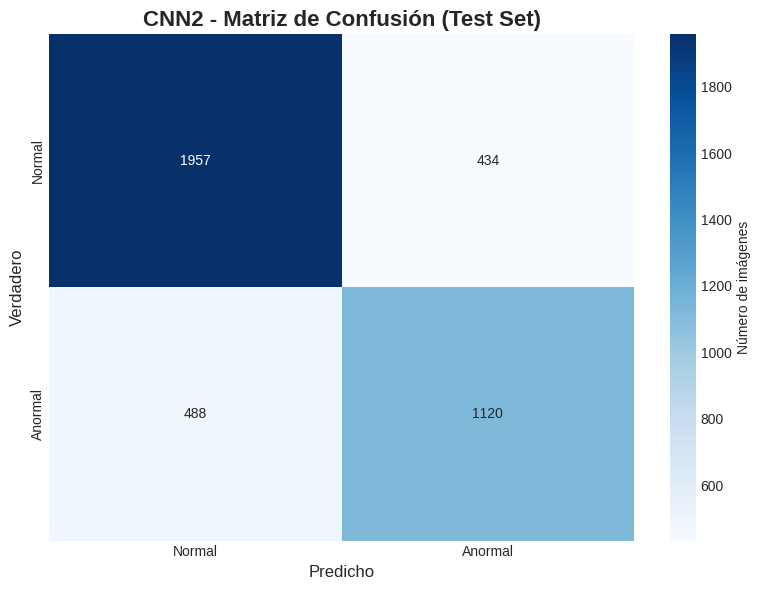

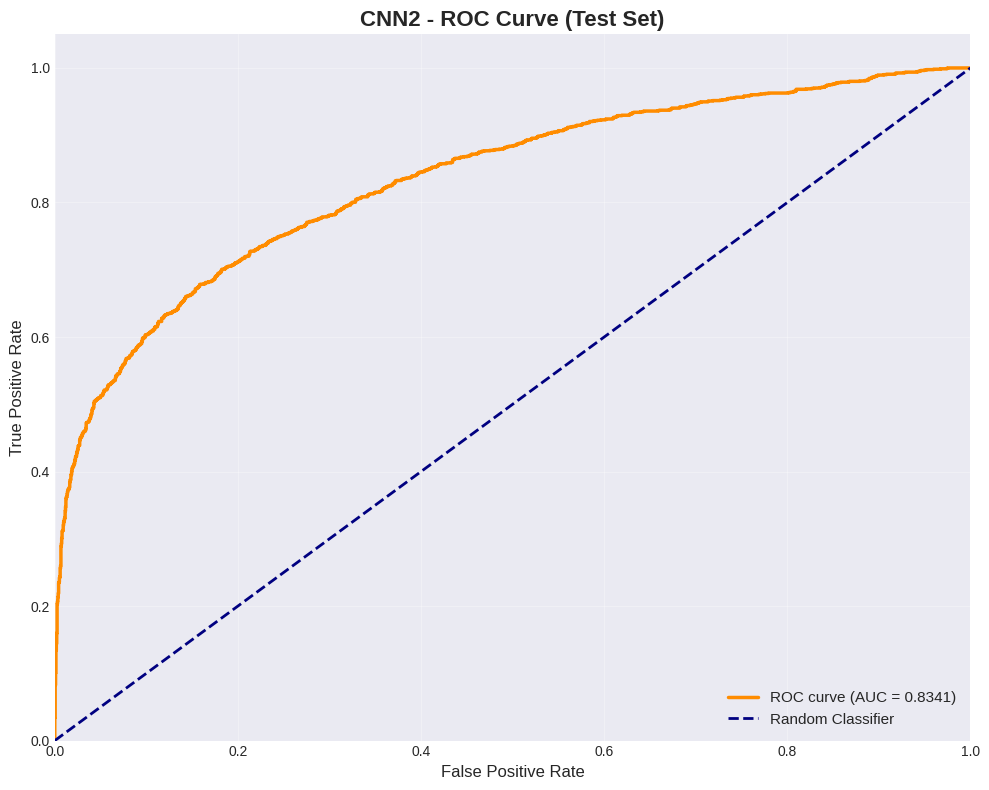

[2025-11-21 20:25:01] [INFO] Gráficos guardados en:
[2025-11-21 20:25:01] [INFO]    - results/cnn2_confusion_matrix_test.png
[2025-11-21 20:25:01] [INFO]    - results/cnn2_roc_curve_test.png

[2025-11-21 20:25:01] [INFO] CNN2 evaluación completada

[2025-11-21 20:25:01] [INFO] ================================================================================

[2025-11-21 20:25:01] [INFO] PASO 6 COMPLETADO
[2025-11-21 20:25:01] [INFO] ================================================================================



In [ ]:
# ============================================================================
#  EVALUACIÓN CNN2 (ANOMALÍA) EN TEST SET
# ===========================================================================

logger.log(f"\n{'─'*80}")
logger.log(f"6.2 EVALUACIÓN CNN2 (ANOMALÍA) EN TEST SET")
logger.log(f"{'─'*80}\n")

def evaluate_cnn2_test(model, test_loader, device):
    """
    Evalúa CNN2 en test set con métricas binarias completas

    Args:
        model: Modelo CNN2 cargado
        test_loader: DataLoader de test
        device: Device (cuda/cpu)

    Returns:
        dict: Diccionario con predicciones, labels, probabilidades y métricas
    """
    model.eval()

    all_preds = []
    all_labels = []
    all_probas = []

    logger.log(f"Evaluando CNN2 en Test Set...\n")

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="CNN2 Evaluation", leave=False):
            images = batch['images'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(images)
            probas = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probas = np.array(all_probas)

    # Métricas binarias
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    # Specificity
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    balanced_accuracy = (recall + specificity) / 2

    # AUC-ROC
    probas_class1 = all_probas[:, 1]
    auc = roc_auc_score(all_labels, probas_class1)

    kappa = cohen_kappa_score(all_labels, all_preds)

    # Imprimir resultados
    logger.log(f"\n{'='*80}")
    logger.log(f"CNN2 - RESULTADOS EN TEST SET")
    logger.log(f"{'='*80}\n")

    logger.log(f"Métricas Globales:")
    logger.log(f"   Accuracy: {accuracy:.4f}")
    logger.log(f"   Balanced Accuracy: {balanced_accuracy:.4f}")
    logger.log(f"   Precision: {precision:.4f}")
    logger.log(f"   Recall (Sensitivity): {recall:.4f}")
    logger.log(f"   Specificity: {specificity:.4f}")
    logger.log(f"   F1-Score: {f1:.4f}")
    logger.log(f"   AUC-ROC: {auc:.4f}")
    logger.log(f"   Cohen Kappa: {kappa:.4f}\n")

    logger.log(f"Matriz de Confusión:")
    logger.log(f"   True Negatives: {tn}")
    logger.log(f"   False Positives: {fp}")
    logger.log(f"   False Negatives: {fn}")
    logger.log(f"   True Positives: {tp}\n")

    # Matriz de confusión gráfico
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Anormal'], yticklabels=['Normal', 'Anormal'],
                cbar_kws={'label': 'Número de imágenes'})
    plt.title('CNN2 - Matriz de Confusión (Test Set)', fontsize=16, fontweight='bold')
    plt.ylabel('Verdadero', fontsize=12)
    plt.xlabel('Predicho', fontsize=12)
    plt.tight_layout()
    plt.savefig('results/cnn2_confusion_matrix_test.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Curva ROC
    fpr, tpr, thresholds = roc_curve(all_labels, probas_class1)

    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('CNN2 - ROC Curve (Test Set)', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('results/cnn2_roc_curve_test.png', dpi=150, bbox_inches='tight')
    plt.show()

    logger.log(f"Gráficos guardados en:")
    logger.log(f"   - results/cnn2_confusion_matrix_test.png")
    logger.log(f"   - results/cnn2_roc_curve_test.png\n")

    return {
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probas,
        'metrics': {
            'accuracy': accuracy,
            'balanced_accuracy': balanced_accuracy,
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'f1': f1,
            'auc': auc,
            'kappa': kappa,
            'confusion_matrix': {'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)}
        }
    }


# Evaluar CNN2
cnn2_test_results = evaluate_cnn2_test(
    model=cnn2_best,
    test_loader=test_loader_cnn2,
    device=device
)

logger.log(f"CNN2 evaluación completada\n")
logger.log(f"{'='*80}\n")
logger.log(f"PASO 6 COMPLETADO")
logger.log(f"{'='*80}\n")


In [ ]:
# ================================================================================
# 6.3 SISTEMA JERÁRQUICO EN CASCADA
# ================================================================================

logger.log(f"\n{'─'*80}")
logger.log(f"6.3 EVALUACIÓN SISTEMA JERÁRQUICO EN CASCADA (CNN1 → CNN2)")
logger.log(f"{'─'*80}\n")

def hierarchical_predict_single(image_path, cnn1_model, cnn2_model, device, transforms):
    """
    Predicción del sistema jerárquico completo para una única imagen

    Flujo:
    1. CNN1 predice anatomía (7 clases)
    2. CNN2 predice anomalía (2 clases: Normal/Anormal)

    Args:
        image_path: Ruta de la imagen
        cnn1_model: Modelo CNN1 entrenado
        cnn2_model: Modelo CNN2 entrenado
        device: Device (cuda/cpu)
        transforms: Transformaciones a aplicar

    Returns:
        dict: Diccionario con predicciones y confianzas de ambos modelos
    """

    # Cargar imagen
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError(f"No se pudo cargar: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    # Aplicar transformaciones
    transformed = transforms(image=image)
    image_tensor = transformed['image'].unsqueeze(0).to(device)

    # CNN1: Predicción de anatomía
    cnn1_model.eval()
    with torch.no_grad():
        cnn1_output = cnn1_model(image_tensor)
        cnn1_probas = torch.softmax(cnn1_output, dim=1)[0]
        cnn1_pred = torch.argmax(cnn1_probas).item()
        cnn1_conf = cnn1_probas[cnn1_pred].item()

    # CNN2: Predicción de anomalía
    cnn2_model.eval()
    with torch.no_grad():
        cnn2_output = cnn2_model(image_tensor)
        cnn2_probas = torch.softmax(cnn2_output, dim=1)[0]
        cnn2_pred = torch.argmax(cnn2_probas).item()
        cnn2_conf = cnn2_probas[cnn2_pred].item()

    return {
        'anatomy_pred': cnn1_pred,
        'anatomy_conf': float(cnn1_conf),
        'anatomy_probas': cnn1_probas.cpu().numpy(),
        'anomaly_pred': cnn2_pred,
        'anomaly_conf': float(cnn2_conf),
        'anomaly_probas': cnn2_probas.cpu().numpy()
    }


logger.log(f"Función de predicción jerárquica definida\n")


[2025-11-21 20:25:01] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 20:25:01] [INFO] 6.3 EVALUACIÓN SISTEMA JERÁRQUICO EN CASCADA (CNN1 → CNN2)
[2025-11-21 20:25:01] [INFO] ────────────────────────────────────────────────────────────────────────────────

[2025-11-21 20:25:01] [INFO] Función de predicción jerárquica definida



In [ ]:
# ================================================================================
# Evaluación completa del sistema jerárquico
# ================================================================================

def evaluate_hierarchical_system(cnn1_model, cnn2_model, test_df, device, transforms,
                                 anatomy_map, anatomy_classes):
    """
    Evalúa el sistema jerárquico completo en el test set

    Args:
        cnn1_model: Modelo CNN1 entrenado
        cnn2_model: Modelo CNN2 entrenado
        test_df: DataFrame de test
        device: Device (cuda/cpu)
        transforms: Transformaciones
        anatomy_map: Diccionario de mapeo anatomía → label
        anatomy_classes: Lista de nombres de clases

    Returns:
        DataFrame con predicciones completas del sistema
    """

    logger.log(f"Evaluando sistema jerárquico en test set...\n")

    results = []

    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Hierarchical Evaluation", leave=False):
        image_path = row['image_path']
        true_anatomy_label = row['anatomy_label']
        true_anomaly = int(row['is_abnormal'])

        try:
            predictions = hierarchical_predict_single(
                image_path, cnn1_model, cnn2_model, device, transforms
            )

            results.append({
                'image_path': str(image_path),
                'anatomy': row['anatomy'],
                'true_anatomy_label': true_anatomy_label,
                'pred_anatomy_label': predictions['anatomy_pred'],
                'anatomy_confidence': predictions['anatomy_conf'],
                'anatomy_correct': (true_anatomy_label == predictions['anatomy_pred']),
                'true_anomaly': true_anomaly,
                'pred_anomaly': predictions['anomaly_pred'],
                'anomaly_confidence': predictions['anomaly_conf'],
                'anomaly_correct': (true_anomaly == predictions['anomaly_pred']),
                'system_correct': ((true_anatomy_label == predictions['anatomy_pred']) and
                                 (true_anomaly == predictions['anomaly_pred']))
            })

        except Exception as e:
            logger.log(f"Error procesando {image_path}: {str(e)}")
            continue

    results_df = pd.DataFrame(results)

    # Calcular métricas
    anatomy_accuracy = results_df['anatomy_correct'].mean()
    anomaly_accuracy = results_df['anomaly_correct'].mean()
    system_accuracy = results_df['system_correct'].mean()

    # Análisis de propagación de errores
    cnn1_correct = results_df[results_df['anatomy_correct'] == True]
    cnn1_incorrect = results_df[results_df['anatomy_correct'] == False]

    if len(cnn1_correct) > 0:
        anomaly_acc_when_cnn1_correct = cnn1_correct['anomaly_correct'].mean()
    else:
        anomaly_acc_when_cnn1_correct = 0

    if len(cnn1_incorrect) > 0:
        anomaly_acc_when_cnn1_incorrect = cnn1_incorrect['anomaly_correct'].mean()
    else:
        anomaly_acc_when_cnn1_incorrect = 0

    # Mostrar resultados
    logger.log(f"\n{'='*80}")
    logger.log(f"SISTEMA JERÁRQUICO - RESULTADOS EN TEST SET")
    logger.log(f"{'='*80}\n")

    logger.log(f"Métricas por Componente:")
    logger.log(f"   CNN1 (Anatomía) Accuracy: {anatomy_accuracy:.4f}")
    logger.log(f"   CNN2 (Anomalía) Accuracy: {anomaly_accuracy:.4f}\n")

    logger.log(f"Métricas del Sistema Completo:")
    logger.log(f"   Accuracy Conjunta (ambos correctos): {system_accuracy:.4f}\n")

    logger.log(f"Análisis de Propagación de Errores:")
    logger.log(f"   CNN2 accuracy cuando CNN1 acierta: {anomaly_acc_when_cnn1_correct:.4f}")
    logger.log(f"   CNN2 accuracy cuando CNN1 falla: {anomaly_acc_when_cnn1_incorrect:.4f}\n")

    impact = anomaly_acc_when_cnn1_correct - anomaly_acc_when_cnn1_incorrect
    logger.log(f"   Impacto de error CNN1 en CNN2: {impact:.4f}\n")

    # Estadísticas por anatomía
    logger.log(f"Accuracy de CNN2 por Categoría Anatómica:\n")

    for anatomy_idx in range(len(anatomy_classes)):
        anatomy_name = anatomy_classes[anatomy_idx]
        subset = results_df[results_df['true_anatomy_label'] == anatomy_idx]

        if len(subset) > 0:
            acc = subset['anomaly_correct'].mean()
            count = len(subset)
            logger.log(f"   {anatomy_name}: {acc:.4f} ({count} imágenes)")

    logger.log(f"\n{'='*80}\n")

    return results_df


# Mapeo de anatomía
ANATOMY_MAP = {
    'XR_ELBOW': 0,
    'XR_FINGER': 1,
    'XR_FOREARM': 2,
    'XR_HAND': 3,
    'XR_HUMERUS': 4,
    'XR_SHOULDER': 5,
    'XR_WRIST': 6
}

ANATOMY_CLASSES = ['ELBOW', 'FINGER', 'FOREARM', 'HAND', 'HUMERUS', 'SHOULDER', 'WRIST']

# Ejecutar evaluación
hierarchical_results = evaluate_hierarchical_system(
    cnn1_model=cnn1_best,
    cnn2_model=cnn2_best,
    test_df=df_test,
    device=device,
    transforms=test_transforms,
    anatomy_map=ANATOMY_MAP,
    anatomy_classes=ANATOMY_CLASSES
)

# Guardar resultados
hierarchical_results.to_csv('results/hierarchical_system_results.csv', index=False)
logger.log(f"Resultados guardados en: results/hierarchical_system_results.csv\n")


[2025-11-21 20:25:01] [INFO] Evaluando sistema jerárquico en test set...



[2025-11-21 20:25:55] [INFO] 
[2025-11-21 20:25:55] [INFO] SISTEMA JERÁRQUICO - RESULTADOS EN TEST SET
[2025-11-21 20:25:55] [INFO] ================================================================================

[2025-11-21 20:25:55] [INFO] Métricas por Componente:
[2025-11-21 20:25:55] [INFO]    CNN1 (Anatomía) Accuracy: 0.7652
[2025-11-21 20:25:55] [INFO]    CNN2 (Anomalía) Accuracy: 0.7694

[2025-11-21 20:25:55] [INFO] Métricas del Sistema Completo:
[2025-11-21 20:25:55] [INFO]    Accuracy Conjunta (ambos correctos): 0.5841

[2025-11-21 20:25:55] [INFO] Análisis de Propagación de Errores:
[2025-11-21 20:25:55] [INFO]    CNN2 accuracy cuando CNN1 acierta: 0.7634
[2025-11-21 20:25:55] [INFO]    CNN2 accuracy cuando CNN1 falla: 0.7891

[2025-11-21 20:25:55] [INFO]    Impacto de error CNN1 en CNN2: -0.0257

[2025-11-21 20:25:55] [INFO] Accuracy de CNN2 por Categoría Anatómica:

[2025-11-21 20:25:55] [INFO]    ELBOW: 0.8195 (532 imágenes)
[2025-11-21 20:25:55] [INFO]    FINGER: 0.7407 

In [ ]:
# ================================================================================
# Análisis detallado de errores del sistema
# ================================================================================

logger.log(f"\n{'─'*80}")
logger.log(f"ANÁLISIS DE ERRORES DEL SISTEMA JERÁRQUICO")
logger.log(f"{'─'*80}\n")

# Errores CNN1
cnn1_errors = hierarchical_results[hierarchical_results['anatomy_correct'] == False]
logger.log(f"Errores CNN1 (Anatomía):")
logger.log(f"   Total errores: {len(cnn1_errors)} / {len(hierarchical_results)} ({len(cnn1_errors)/len(hierarchical_results)*100:.2f}%)\n")

# Errores CNN2
cnn2_errors = hierarchical_results[hierarchical_results['anomaly_correct'] == False]

# False Positives (predice Anormal, es Normal)
cnn2_fp = cnn2_errors[(cnn2_errors['true_anomaly'] == 0) & (cnn2_errors['pred_anomaly'] == 1)]

# False Negatives (predice Normal, es Anormal) - MÁS CRÍTICO
cnn2_fn = cnn2_errors[(cnn2_errors['true_anomaly'] == 1) & (cnn2_errors['pred_anomaly'] == 0)]

logger.log(f"Errores CNN2 (Anomalía):")
logger.log(f"   Total errores: {len(cnn2_errors)} / {len(hierarchical_results)} ({len(cnn2_errors)/len(hierarchical_results)*100:.2f}%)")
logger.log(f"   False Positives: {len(cnn2_fp)} (predice Anormal, es Normal)")
logger.log(f"   False Negatives: {len(cnn2_fn)} (predice Normal, es Anormal - CRÍTICO)\n")

# Errores del sistema completo (ambos modelos)
system_errors = hierarchical_results[hierarchical_results['system_correct'] == False]
logger.log(f"Errores del Sistema Completo:")
logger.log(f"   Total errores: {len(system_errors)} / {len(hierarchical_results)} ({len(system_errors)/len(hierarchical_results)*100:.2f}%)\n")

# Desglose de errores del sistema
errors_cnn1_only = hierarchical_results[(hierarchical_results['anatomy_correct'] == False) &
                                        (hierarchical_results['anomaly_correct'] == True)]
errors_cnn2_only = hierarchical_results[(hierarchical_results['anatomy_correct'] == True) &
                                        (hierarchical_results['anomaly_correct'] == False)]
errors_both = hierarchical_results[(hierarchical_results['anatomy_correct'] == False) &
                                   (hierarchical_results['anomaly_correct'] == False)]

logger.log(f"Desglose de Errores del Sistema:")
logger.log(f"   Solo CNN1 falla: {len(errors_cnn1_only)}")
logger.log(f"   Solo CNN2 falla: {len(errors_cnn2_only)}")
logger.log(f"   Ambos fallan: {len(errors_both)}\n")

# Guardar análisis de errores
error_analysis = {
    'cnn1_errors': cnn1_errors[['image_path', 'anatomy', 'true_anatomy_label', 'pred_anatomy_label']].to_dict('records'),
    'cnn2_false_positives': cnn2_fp[['image_path', 'anatomy', 'true_anomaly', 'pred_anomaly']].to_dict('records'),
    'cnn2_false_negatives': cnn2_fn[['image_path', 'anatomy', 'true_anomaly', 'pred_anomaly']].to_dict('records'),
    'system_errors_summary': {
        'total_errors': len(system_errors),
        'cnn1_only_errors': len(errors_cnn1_only),
        'cnn2_only_errors': len(errors_cnn2_only),
        'both_errors': len(errors_both)
    }
}

with open('results/hierarchical_error_analysis.json', 'w') as f:
    json.dump(error_analysis, f, indent=2, default=str)

logger.log(f"Análisis de errores guardado en: results/hierarchical_error_analysis.json\n")

logger.log(f"{'='*80}\n")
logger.log(f"PASO 6.3 COMPLETADO")
logger.log(f"{'='*80}\n")


[2025-11-21 20:25:55] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 20:25:55] [INFO] ANÁLISIS DE ERRORES DEL SISTEMA JERÁRQUICO
[2025-11-21 20:25:55] [INFO] ────────────────────────────────────────────────────────────────────────────────

[2025-11-21 20:25:55] [INFO] Errores CNN1 (Anatomía):
[2025-11-21 20:25:55] [INFO]    Total errores: 939 / 3999 (23.48%)

[2025-11-21 20:25:55] [INFO] Errores CNN2 (Anomalía):
[2025-11-21 20:25:55] [INFO]    Total errores: 922 / 3999 (23.06%)
[2025-11-21 20:25:55] [INFO]    False Positives: 434 (predice Anormal, es Normal)
[2025-11-21 20:25:55] [INFO]    False Negatives: 488 (predice Normal, es Anormal - CRÍTICO)

[2025-11-21 20:25:55] [INFO] Errores del Sistema Completo:
[2025-11-21 20:25:55] [INFO]    Total errores: 1663 / 3999 (41.59%)

[2025-11-21 20:25:55] [INFO] Desglose de Errores del Sistema:
[2025-11-21 20:25:55] [INFO]    Solo CNN1 falla: 741
[2025-11-21 20:25:55] [INFO]    Solo CNN2 fal

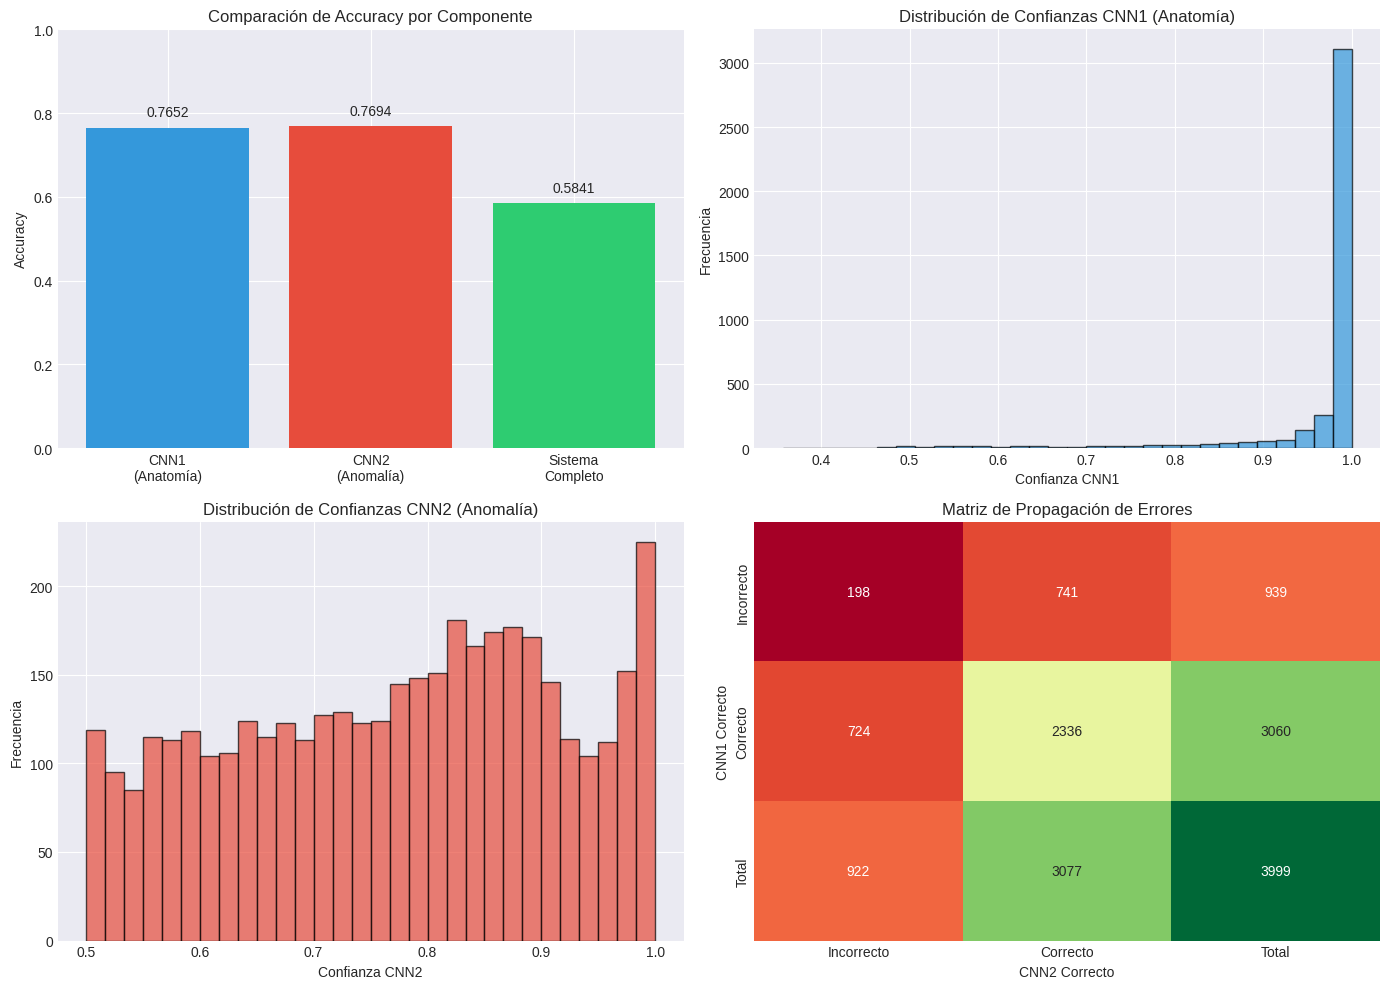

[2025-11-21 20:09:58] [INFO] Visualización guardada en: results/hierarchical_system_visualization.png



In [ ]:
# ================================================================================
# Visualización de resultados del sistema jerárquico
# ================================================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparación de Accuracy por componente
components = ['CNN1\n(Anatomía)', 'CNN2\n(Anomalía)', 'Sistema\nCompleto']
accuracies = [
    hierarchical_results['anatomy_correct'].mean(),
    hierarchical_results['anomaly_correct'].mean(),
    hierarchical_results['system_correct'].mean()
]

axes[0, 0].bar(components, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Comparación de Accuracy por Componente')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom')

# 2. Distribución de confianzas CNN1
axes[0, 1].hist(hierarchical_results['anatomy_confidence'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Confianza CNN1')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Confianzas CNN1 (Anatomía)')

# 3. Distribución de confianzas CNN2
axes[1, 0].hist(hierarchical_results['anomaly_confidence'], bins=30, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Confianza CNN2')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Confianzas CNN2 (Anomalía)')

# 4. Matriz de propagación de errores
error_matrix = pd.crosstab(
    hierarchical_results['anatomy_correct'],
    hierarchical_results['anomaly_correct'],
    margins=True
)

sns.heatmap(error_matrix, annot=True, fmt='d', cmap='RdYlGn', ax=axes[1, 1], cbar=False)
axes[1, 1].set_xlabel('CNN2 Correcto')
axes[1, 1].set_ylabel('CNN1 Correcto')
axes[1, 1].set_title('Matriz de Propagación de Errores')
axes[1, 1].set_xticklabels(['Incorrecto', 'Correcto', 'Total'])
axes[1, 1].set_yticklabels(['Incorrecto', 'Correcto', 'Total'])

plt.tight_layout()
plt.savefig('results/hierarchical_system_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

logger.log(f"Visualización guardada en: results/hierarchical_system_visualization.png\n")


## 7

In [ ]:
import cv2
import numpy as np
from PIL import Image

logger.log(f"\n{'='*80}")
logger.log(f"PASO 7: GRAD-CAM Y EXPLICABILIDAD")
logger.log(f"{'='*80}\n")

class GradCAM:
    """
    Generador de mapas de calor Grad-CAM para explicabilidad
    Visualiza regiones de la imagen que influyen en la predicción
    """

    def __init__(self, model, layer_name, device):
        self.model = model
        self.device = device
        self.layer_name = layer_name
        self.feature_maps = None
        self.gradients = None

        self._register_hooks()

    def _register_hooks(self):
        """Registra hooks para capturar features y gradientes"""
        target_layer = self._get_layer(self.layer_name)

        def forward_hook(module, input, output):
            self.feature_maps = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_backward_hook(backward_hook)

    def _get_layer(self, layer_name):
        """Obtiene una capa específica del modelo"""
        for name, module in self.model.named_modules():
            if name == layer_name:
                return module
        raise ValueError(f"Layer {layer_name} not found")

    def generate_cam(self, image_tensor, target_class=None):
        """
        Genera el mapa de calor Grad-CAM

        Args:
            image_tensor: Tensor de imagen (1, 3, 224, 224)
            target_class: Índice de clase objetivo (None = argmax)

        Returns:
            cam: Mapa de calor normalizado (0-255)
        """
        self.model.eval()

        with torch.enable_grad():
            image_tensor.requires_grad_(True)

            output = self.model(image_tensor)

            if target_class is None:
                target_class = torch.argmax(output, dim=1).item()

            score = output[0, target_class]
            score.backward()

        # Calcular pesos (gradiente promedio)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Calcular CAM
        cam = (weights * self.feature_maps).sum(dim=1, keepdim=True)
        cam = cam.squeeze(0).squeeze(0).cpu().detach().numpy()

        # ReLU para obtener solo activaciones positivas
        cam = np.maximum(cam, 0)

        # Normalizar a 0-255
        cam = cam / (cam.max() + 1e-8)
        cam = (cam * 255).astype(np.uint8)

        return cam, target_class

    def overlay_cam_on_image(self, image, cam, alpha=0.5):
        """
        Superpone el mapa de calor sobre la imagen original

        Args:
            image: Imagen original (numpy array)
            cam: Mapa de calor Grad-CAM
            alpha: Transparencia del overlay

        Returns:
            overlayed: Imagen con mapa de calor superpuesto
        """
        # Redimensionar CAM a tamaño de imagen
        cam_resized = cv2.resize(cam, (image.shape[1], image.shape[0]))

        # Aplicar colormap
        heatmap = cv2.applyColorMap(cam_resized, cv2.COLORMAP_JET)

        # Convertir imagen a BGR si es necesario
        if len(image.shape) == 2:
            image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

        # Superponer
        overlayed = cv2.addWeighted(image, 1 - alpha, heatmap, alpha, 0)

        return overlayed


logger.log(f"GradCAM class implemented\n")

# Crear instancias de Grad-CAM para ambos modelos
gradcam_cnn1 = GradCAM(cnn1_best, layer_name='layer4', device=device)
gradcam_cnn2 = GradCAM(cnn2_best, layer_name='layer3', device=device)

logger.log(f"GradCAM instances created for CNN1 and CNN2\n")


[2025-11-21 20:11:07] [INFO] 
[2025-11-21 20:11:07] [INFO] PASO 7: GRAD-CAM Y EXPLICABILIDAD
[2025-11-21 20:11:07] [INFO] ================================================================================

[2025-11-21 20:11:07] [INFO] GradCAM class implemented

[2025-11-21 20:11:07] [INFO] GradCAM instances created for CNN1 and CNN2



[2025-11-21 20:11:17] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 20:11:17] [INFO] 7.1 VISUALIZACIÓN GRAD-CAM - CNN1 (ANATOMÍA)
[2025-11-21 20:11:17] [INFO] ────────────────────────────────────────────────────────────────────────────────

[2025-11-21 20:11:17] [INFO] Generando visualizaciones Grad-CAM para CNN1...



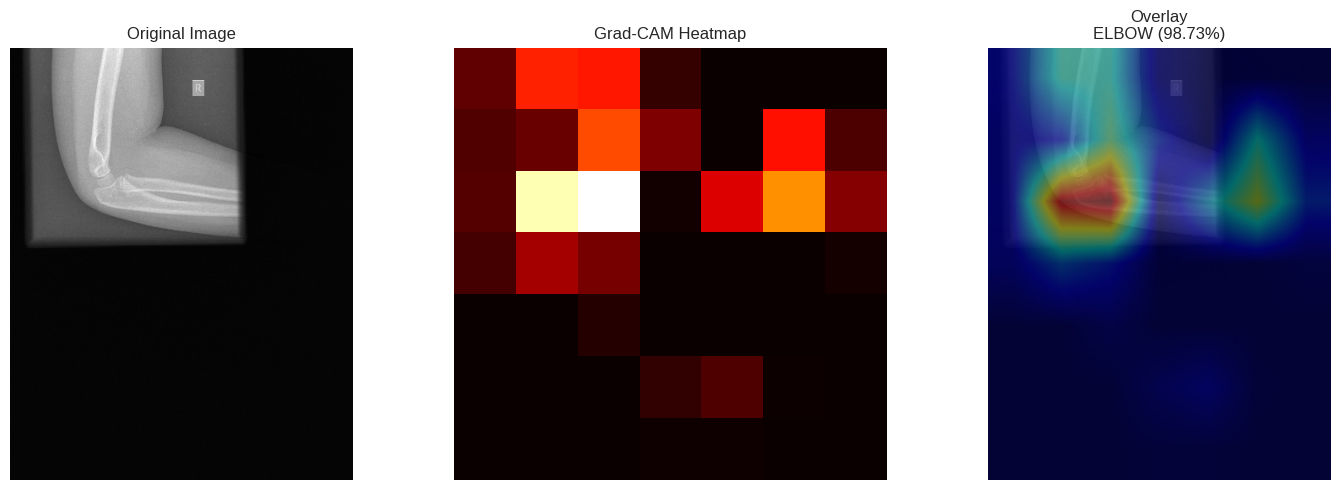

[2025-11-21 20:11:18] [INFO] Grad-CAM CNN1 ELBOW: 0.9873



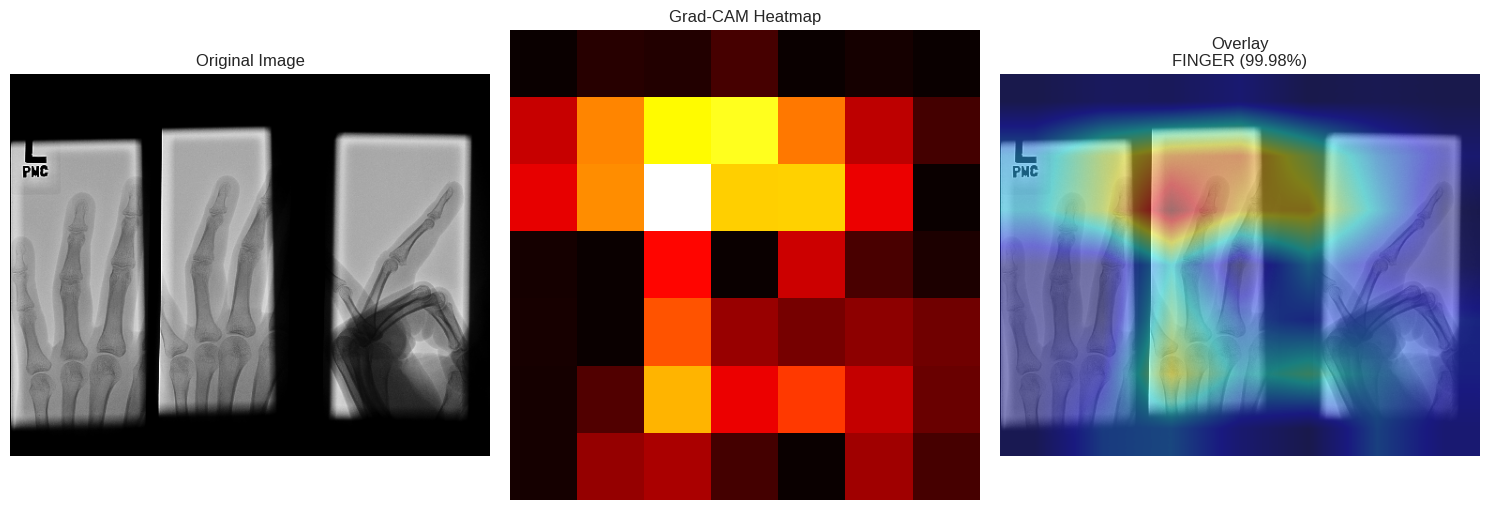

[2025-11-21 20:11:19] [INFO] Grad-CAM CNN1 FINGER: 0.9998



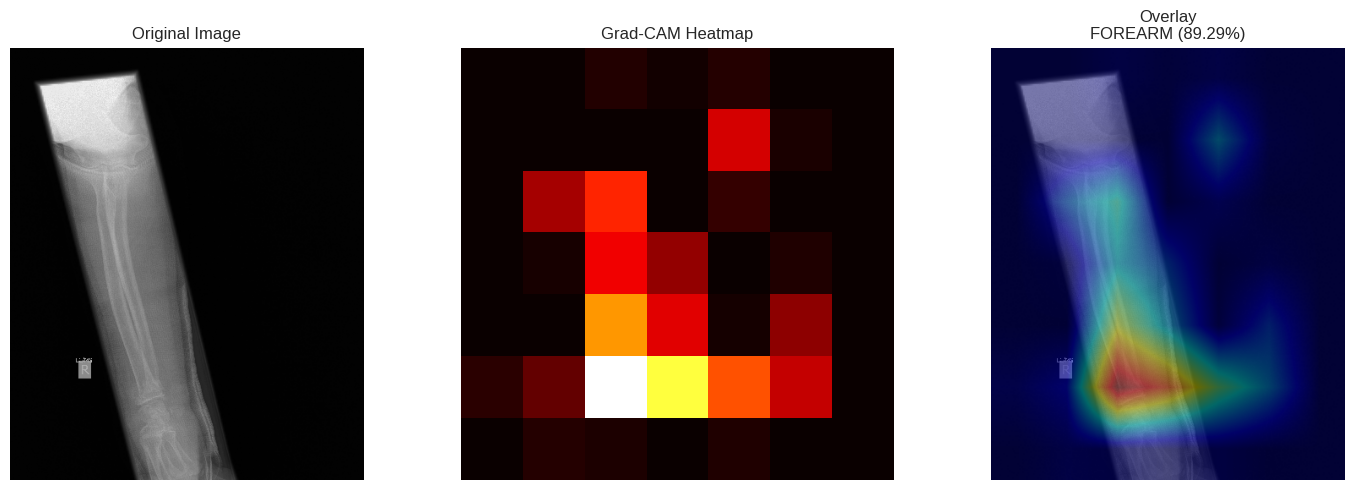

[2025-11-21 20:11:20] [INFO] Grad-CAM CNN1 FOREARM: 0.8929



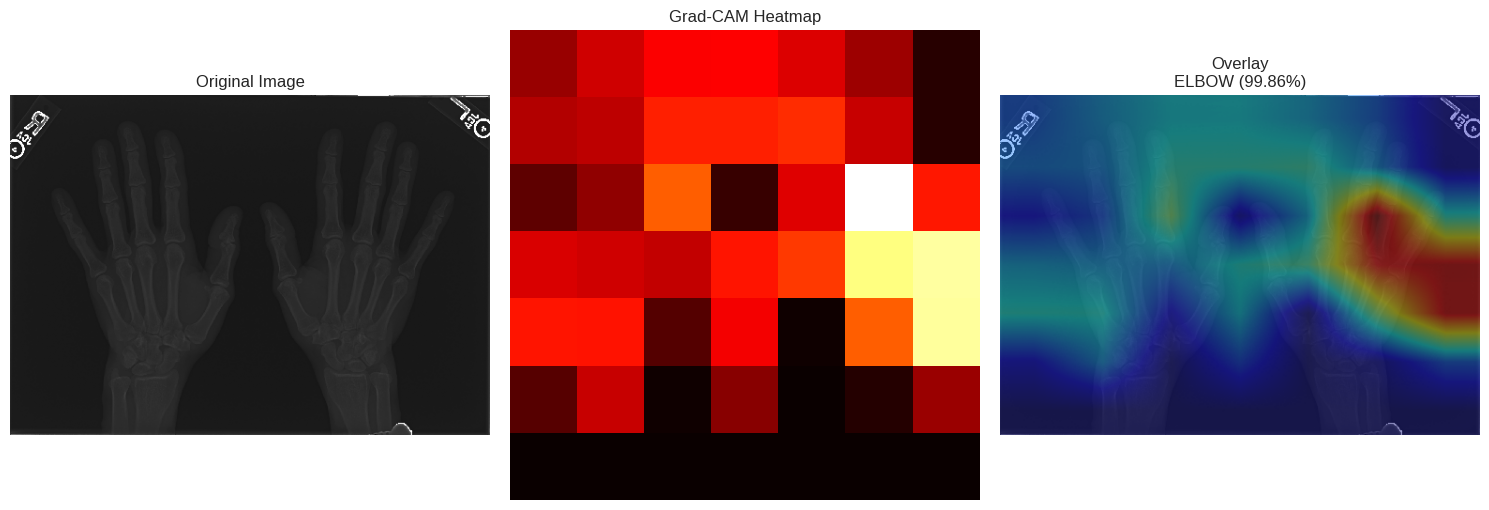

[2025-11-21 20:11:21] [INFO] Grad-CAM CNN1 HAND: 0.9986



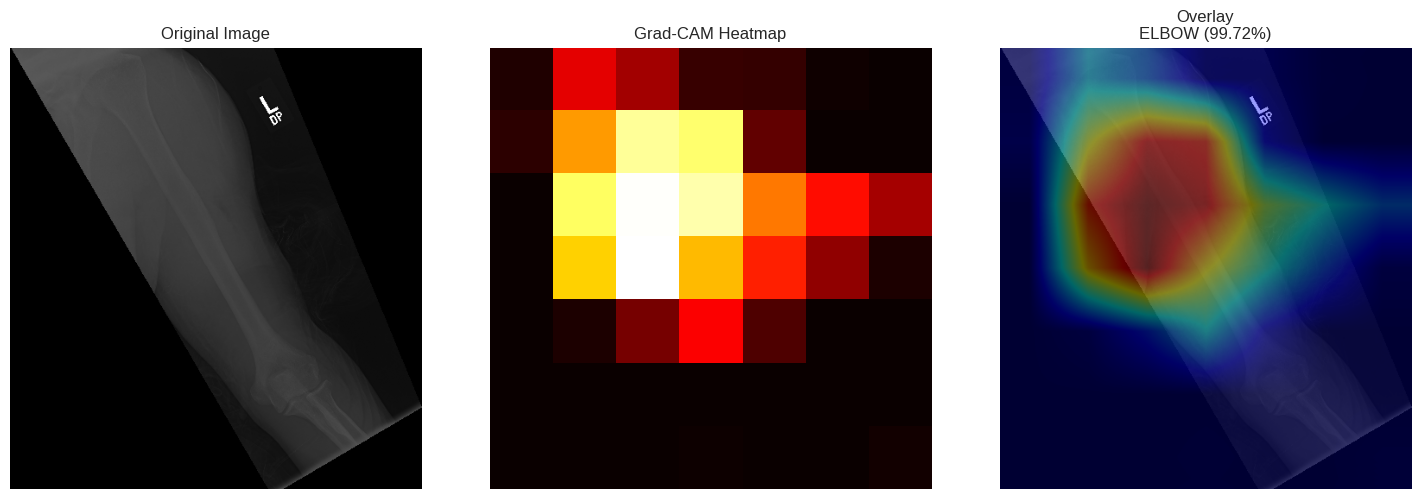

[2025-11-21 20:11:22] [INFO] Grad-CAM CNN1 HUMERUS: 0.9972



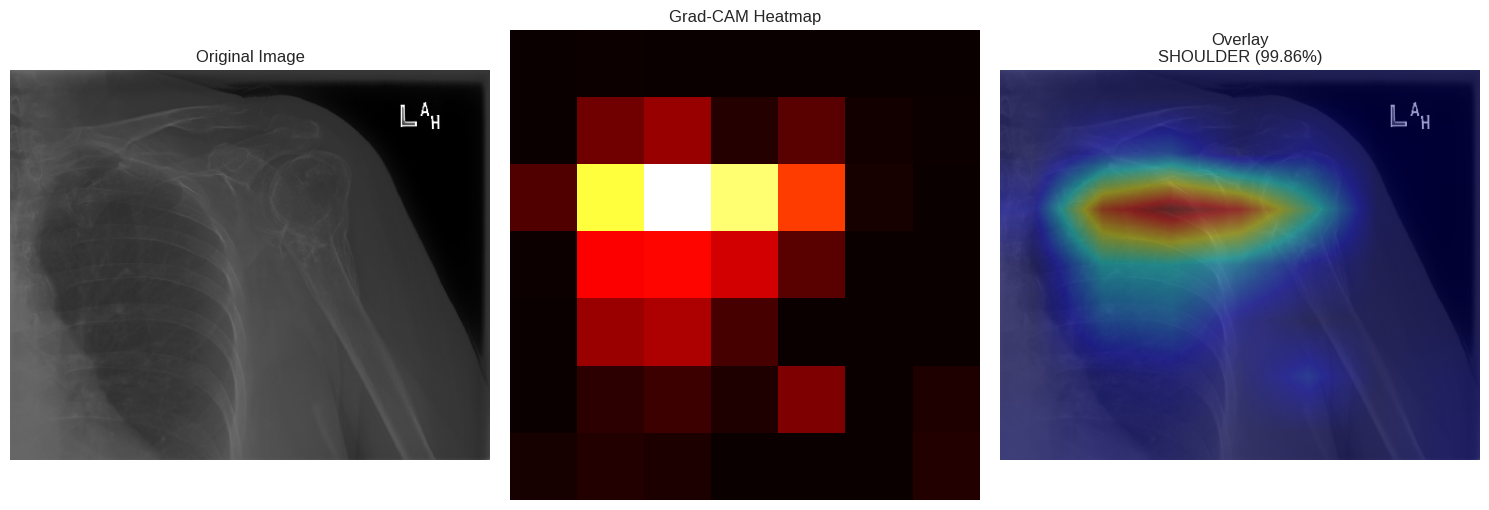

[2025-11-21 20:11:22] [INFO] Grad-CAM CNN1 SHOULDER: 0.9986



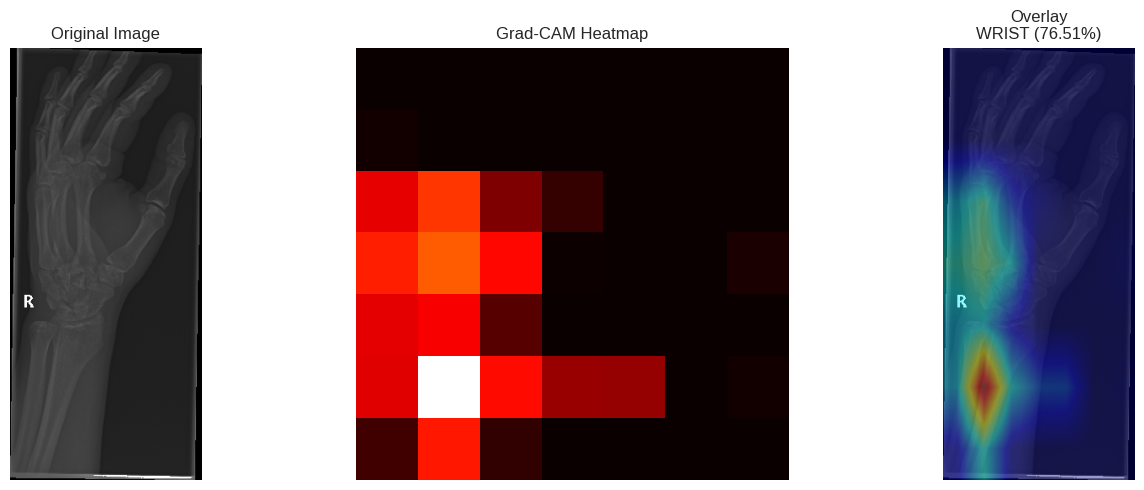

[2025-11-21 20:11:23] [INFO] Grad-CAM CNN1 WRIST: 0.7651

[2025-11-21 20:11:23] [INFO] CNN1 Grad-CAM visualizations completed



In [ ]:
logger.log(f"\n{'─'*80}")
logger.log(f"7.1 VISUALIZACIÓN GRAD-CAM - CNN1 (ANATOMÍA)")
logger.log(f"{'─'*80}\n")

def visualize_gradcam_cnn1(image_path, cnn1_model, gradcam, device, transforms, anatomy_classes):
    """
    Visualiza Grad-CAM para CNN1

    Args:
        image_path: Ruta de la imagen
        cnn1_model: Modelo CNN1
        gradcam: Instancia de GradCAM
        device: Device (cuda/cpu)
        transforms: Transformaciones
        anatomy_classes: Lista de nombres de anatomía
    """

    # Cargar y procesar imagen
    image_original = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image_original is None:
        raise ValueError(f"No se pudo cargar: {image_path}")

    image_rgb = cv2.cvtColor(image_original, cv2.COLOR_GRAY2RGB)

    # Aplicar transformaciones
    transformed = transforms(image=image_rgb)
    image_tensor = transformed['image'].unsqueeze(0).to(device)

    # Generar predicción
    cnn1_model.eval()
    with torch.no_grad():
        output = cnn1_model(image_tensor)
        probas = torch.softmax(output, dim=1)[0]
        pred_class = torch.argmax(probas).item()
        pred_conf = probas[pred_class].item()

    # Generar Grad-CAM
    cam, _ = gradcam.generate_cam(image_tensor, target_class=pred_class)

    # Superponer en imagen original
    overlayed = gradcam.overlay_cam_on_image(image_original, cam, alpha=0.4)

    # Crear figura
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Imagen original
    axes[0].imshow(image_original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Mapa de calor
    axes[1].imshow(cam, cmap='hot')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')

    # Superposición
    axes[2].imshow(cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f'Overlay\n{anatomy_classes[pred_class]} ({pred_conf:.2%})')
    axes[2].axis('off')

    plt.tight_layout()

    return fig, pred_class, pred_conf


# Seleccionar imágenes de ejemplo de cada categoría
logger.log(f"Generando visualizaciones Grad-CAM para CNN1...\n")

ANATOMY_CLASSES = ['ELBOW', 'FINGER', 'FOREARM', 'HAND', 'HUMERUS', 'SHOULDER', 'WRIST']

sample_images_cnn1 = []

for anatomy_idx in range(len(ANATOMY_CLASSES)):
    subset = df_test[df_test['anatomy_label'] == anatomy_idx]

    if len(subset) > 0:
        sample_path = subset.iloc[0]['image_path']

        try:
            fig, pred, conf = visualize_gradcam_cnn1(
                sample_path, cnn1_best, gradcam_cnn1, device, test_transforms, ANATOMY_CLASSES
            )

            plt.savefig(f'results/gradcam_cnn1_{ANATOMY_CLASSES[anatomy_idx]}.png',
                       dpi=150, bbox_inches='tight')
            plt.show()

            sample_images_cnn1.append({
                'anatomy': ANATOMY_CLASSES[anatomy_idx],
                'image_path': sample_path,
                'pred_class': pred,
                'confidence': conf
            })

            logger.log(f"Grad-CAM CNN1 {ANATOMY_CLASSES[anatomy_idx]}: {conf:.4f}\n")

        except Exception as e:
            logger.log(f"Error procesando {ANATOMY_CLASSES[anatomy_idx]}: {str(e)}\n")

logger.log(f"CNN1 Grad-CAM visualizations completed\n")


[2025-11-21 20:11:31] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 20:11:31] [INFO] 7.2 VISUALIZACIÓN GRAD-CAM - CNN2 (ANOMALÍA)
[2025-11-21 20:11:31] [INFO] ────────────────────────────────────────────────────────────────────────────────

[2025-11-21 20:11:31] [INFO] Generando visualizaciones Grad-CAM para CNN2...



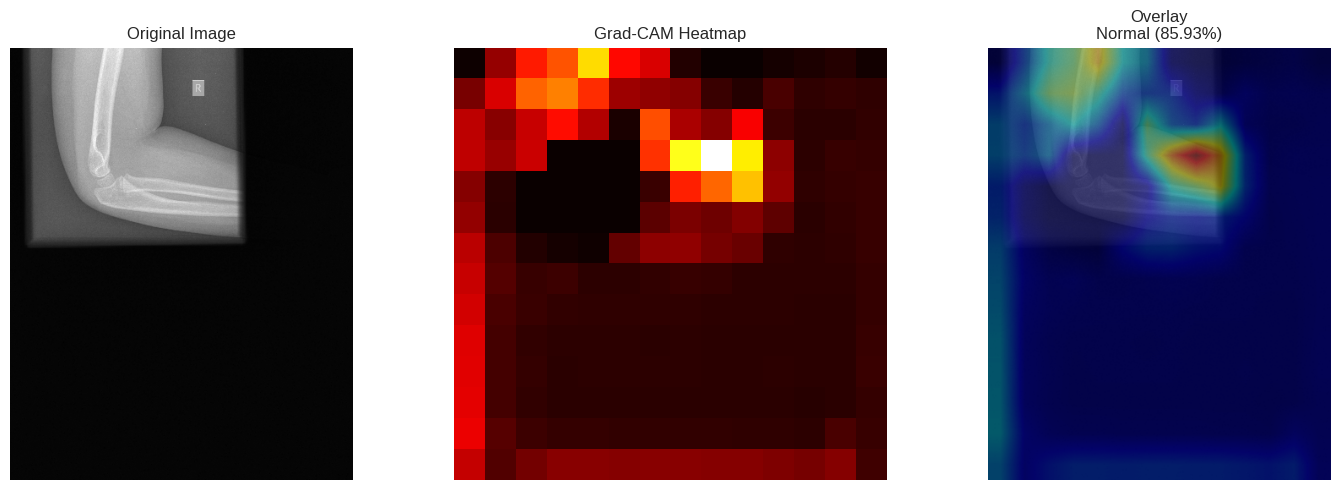

[2025-11-21 20:11:32] [INFO] Grad-CAM CNN2 Normal: 0.8593



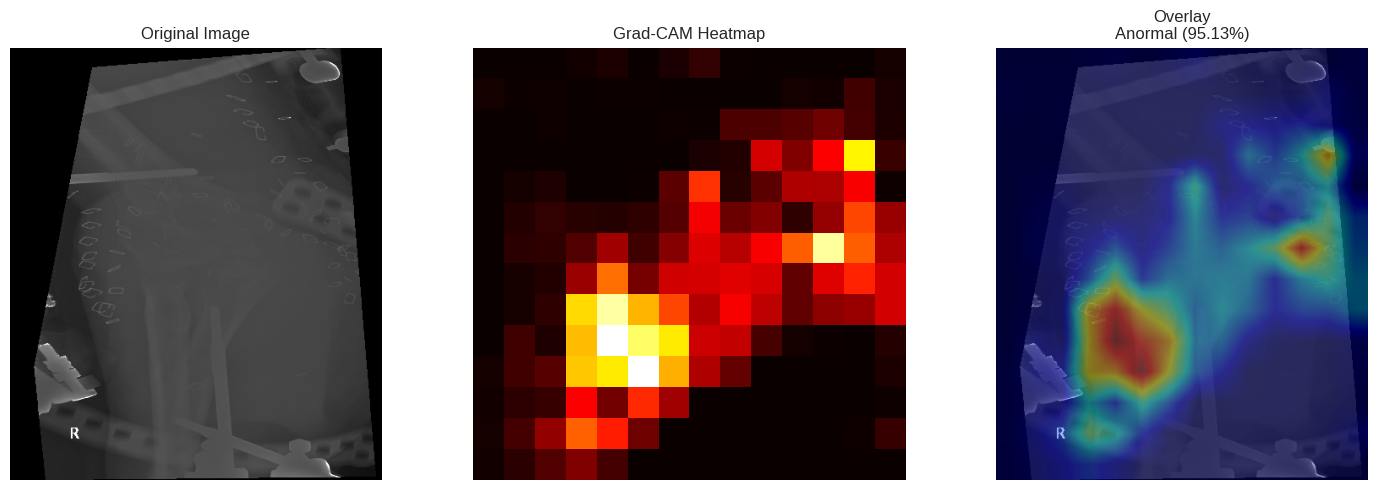

[2025-11-21 20:11:33] [INFO] Grad-CAM CNN2 Abnormal: 0.9513

[2025-11-21 20:11:33] [INFO] CNN2 Grad-CAM visualizations completed



In [ ]:
logger.log(f"\n{'─'*80}")
logger.log(f"7.2 VISUALIZACIÓN GRAD-CAM - CNN2 (ANOMALÍA)")
logger.log(f"{'─'*80}\n")

def visualize_gradcam_cnn2(image_path, cnn2_model, gradcam, device, transforms):
    """
    Visualiza Grad-CAM para CNN2

    Args:
        image_path: Ruta de la imagen
        cnn2_model: Modelo CNN2
        gradcam: Instancia de GradCAM
        device: Device (cuda/cpu)
        transforms: Transformaciones
    """

    # Cargar y procesar imagen
    image_original = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if image_original is None:
        raise ValueError(f"No se pudo cargar: {image_path}")

    image_rgb = cv2.cvtColor(image_original, cv2.COLOR_GRAY2RGB)

    # Aplicar transformaciones
    transformed = transforms(image=image_rgb)
    image_tensor = transformed['image'].unsqueeze(0).to(device)

    # Generar predicción
    cnn2_model.eval()
    with torch.no_grad():
        output = cnn2_model(image_tensor)
        probas = torch.softmax(output, dim=1)[0]
        pred_class = torch.argmax(probas).item()
        pred_conf = probas[pred_class].item()

    # Generar Grad-CAM
    cam, _ = gradcam.generate_cam(image_tensor, target_class=pred_class)

    # Superponer en imagen original
    overlayed = gradcam.overlay_cam_on_image(image_original, cam, alpha=0.4)

    # Crear figura
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Imagen original
    axes[0].imshow(image_original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Mapa de calor
    axes[1].imshow(cam, cmap='hot')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')

    # Superposición
    class_name = 'Anormal' if pred_class == 1 else 'Normal'
    axes[2].imshow(cv2.cvtColor(overlayed, cv2.COLOR_BGR2RGB))
    axes[2].set_title(f'Overlay\n{class_name} ({pred_conf:.2%})')
    axes[2].axis('off')

    plt.tight_layout()

    return fig, pred_class, pred_conf


# Seleccionar imágenes de ejemplo normales y anormales
logger.log(f"Generando visualizaciones Grad-CAM para CNN2...\n")

sample_images_cnn2 = []

# Imagen Normal
normal_samples = df_test[df_test['is_abnormal'] == False]
if len(normal_samples) > 0:
    normal_path = normal_samples.iloc[0]['image_path']

    try:
        fig, pred, conf = visualize_gradcam_cnn2(
            normal_path, cnn2_best, gradcam_cnn2, device, test_transforms
        )

        plt.savefig(f'results/gradcam_cnn2_normal.png', dpi=150, bbox_inches='tight')
        plt.show()

        sample_images_cnn2.append({
            'class': 'Normal',
            'image_path': normal_path,
            'pred_class': pred,
            'confidence': conf
        })

        logger.log(f"Grad-CAM CNN2 Normal: {conf:.4f}\n")

    except Exception as e:
        logger.log(f"Error procesando Normal: {str(e)}\n")

# Imagen Anormal
abnormal_samples = df_test[df_test['is_abnormal'] == True]
if len(abnormal_samples) > 0:
    abnormal_path = abnormal_samples.iloc[0]['image_path']

    try:
        fig, pred, conf = visualize_gradcam_cnn2(
            abnormal_path, cnn2_best, gradcam_cnn2, device, test_transforms
        )

        plt.savefig(f'results/gradcam_cnn2_abnormal.png', dpi=150, bbox_inches='tight')
        plt.show()

        sample_images_cnn2.append({
            'class': 'Abnormal',
            'image_path': abnormal_path,
            'pred_class': pred,
            'confidence': conf
        })

        logger.log(f"Grad-CAM CNN2 Abnormal: {conf:.4f}\n")

    except Exception as e:
        logger.log(f"Error procesando Abnormal: {str(e)}\n")

logger.log(f"CNN2 Grad-CAM visualizations completed\n")


[2025-11-21 20:11:49] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 20:11:49] [INFO] 7.3 ANÁLISIS DE ERRORES CRÍTICOS
[2025-11-21 20:11:49] [INFO] ────────────────────────────────────────────────────────────────────────────────

[2025-11-21 20:11:49] [INFO] Analizando False Negatives de CNN2 (Anormal mal clasificado como Normal)...

[2025-11-21 20:11:49] [INFO] Total False Negatives: 488



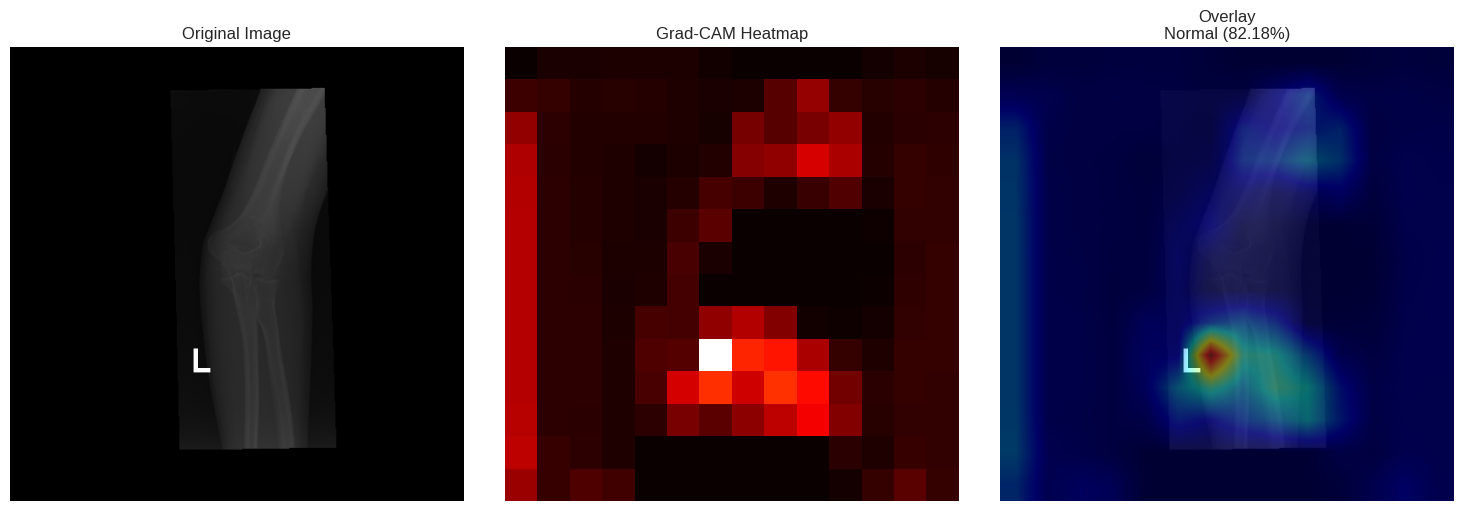

[2025-11-21 20:12:10] [INFO] False Negative 1: XR_ELBOW - Conf Normal: 0.8218



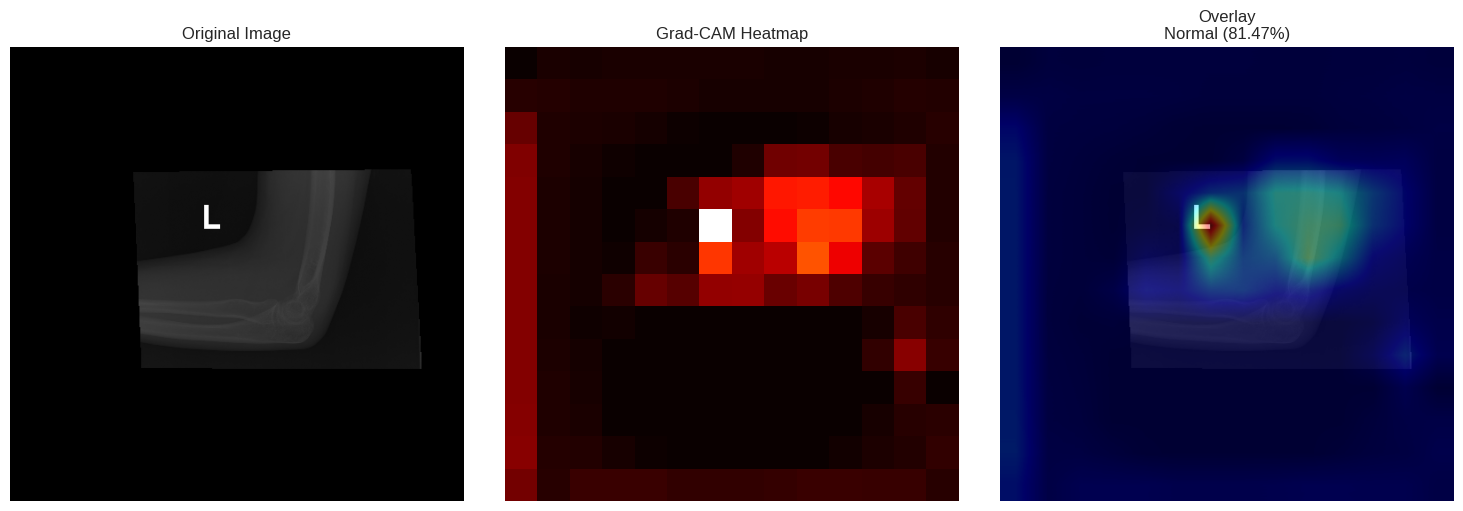

[2025-11-21 20:12:11] [INFO] False Negative 2: XR_ELBOW - Conf Normal: 0.8147



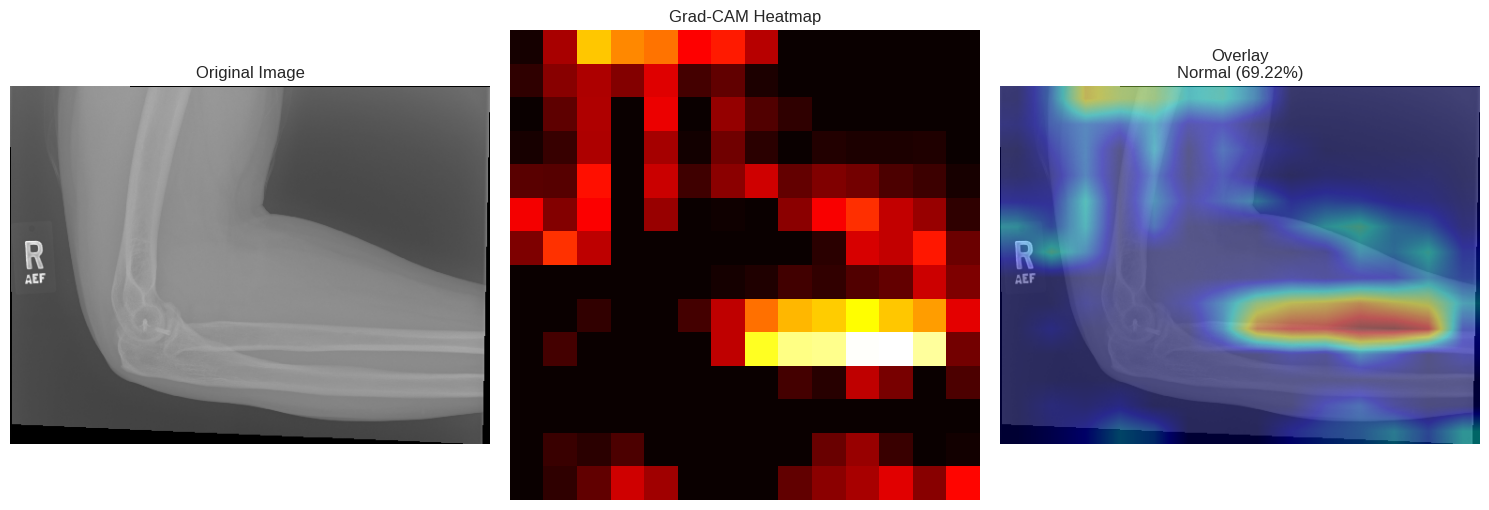

[2025-11-21 20:12:12] [INFO] False Negative 3: XR_ELBOW - Conf Normal: 0.6922

[2025-11-21 20:12:12] [INFO] Analizando False Positives de CNN2 (Normal mal clasificado como Anormal)...

[2025-11-21 20:12:12] [INFO] Total False Positives: 434



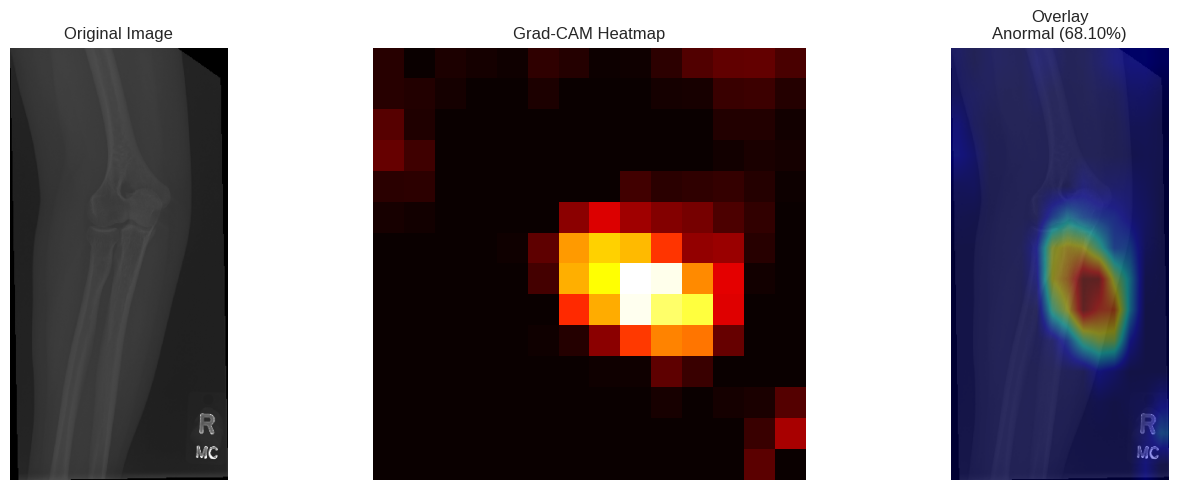

[2025-11-21 20:12:12] [INFO] False Positive 1: XR_ELBOW - Conf Anormal: 0.6810



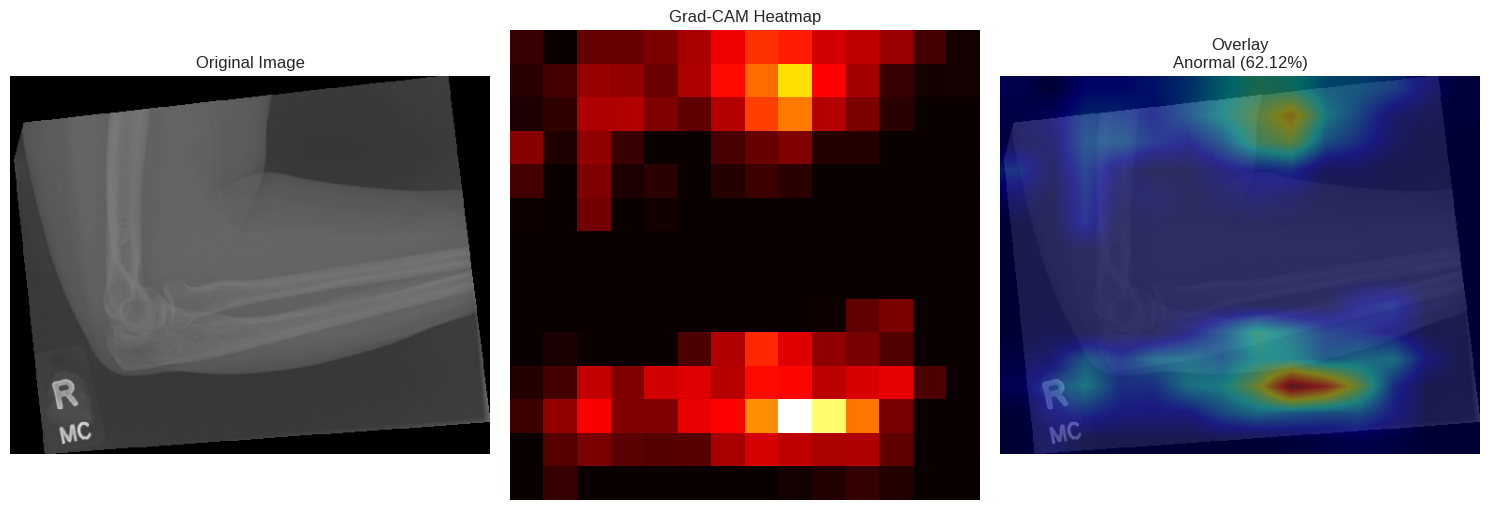

[2025-11-21 20:12:13] [INFO] False Positive 2: XR_ELBOW - Conf Anormal: 0.6212



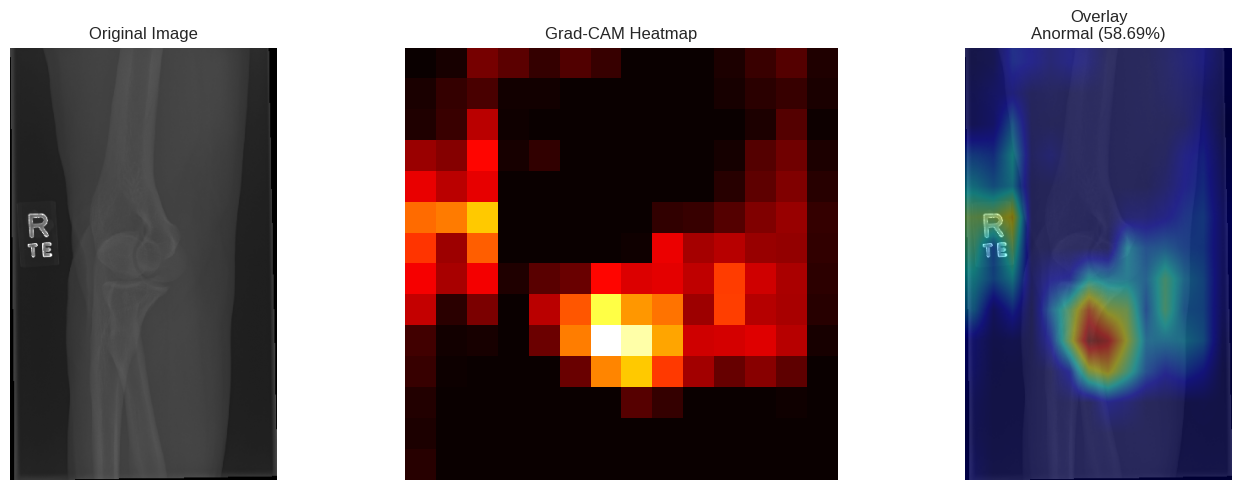

[2025-11-21 20:12:14] [INFO] False Positive 3: XR_ELBOW - Conf Anormal: 0.5869

[2025-11-21 20:12:14] [INFO] ================================================================================



In [ ]:
logger.log(f"\n{'─'*80}")
logger.log(f"7.3 ANÁLISIS DE ERRORES CRÍTICOS")
logger.log(f"{'─'*80}\n")

# CNN2 False Negatives (CRÍTICO: predice Normal, es Anormal)
logger.log(f"Analizando False Negatives de CNN2 (Anormal mal clasificado como Normal)...\n")

fn_samples = hierarchical_results[(hierarchical_results['true_anomaly'] == 1) &
                                  (hierarchical_results['pred_anomaly'] == 0)]

if len(fn_samples) > 0:
    logger.log(f"Total False Negatives: {len(fn_samples)}\n")

    # Visualizar algunos False Negatives
    for i, (idx, row) in enumerate(fn_samples.head(3).iterrows()):
        try:
            image_path = row['image_path']

            fig, pred, conf = visualize_gradcam_cnn2(
                image_path, cnn2_best, gradcam_cnn2, device, test_transforms
            )

            plt.savefig(f'results/gradcam_cnn2_fn_{i}.png', dpi=150, bbox_inches='tight')
            plt.show()

            logger.log(f"False Negative {i+1}: {row['anatomy']} - Conf Normal: {conf:.4f}\n")

        except Exception as e:
            logger.log(f"Error: {str(e)}\n")
else:
    logger.log(f"No False Negatives encontrados\n")

# CNN2 False Positives (predice Anormal, es Normal)
logger.log(f"Analizando False Positives de CNN2 (Normal mal clasificado como Anormal)...\n")

fp_samples = hierarchical_results[(hierarchical_results['true_anomaly'] == 0) &
                                  (hierarchical_results['pred_anomaly'] == 1)]

if len(fp_samples) > 0:
    logger.log(f"Total False Positives: {len(fp_samples)}\n")

    # Visualizar algunos False Positives
    for i, (idx, row) in enumerate(fp_samples.head(3).iterrows()):
        try:
            image_path = row['image_path']

            fig, pred, conf = visualize_gradcam_cnn2(
                image_path, cnn2_best, gradcam_cnn2, device, test_transforms
            )

            plt.savefig(f'results/gradcam_cnn2_fp_{i}.png', dpi=150, bbox_inches='tight')
            plt.show()

            logger.log(f"False Positive {i+1}: {row['anatomy']} - Conf Anormal: {conf:.4f}\n")

        except Exception as e:
            logger.log(f"Error: {str(e)}\n")
else:
    logger.log(f"No False Positives encontrados\n")

logger.log(f"{'='*80}\n")


In [ ]:
logger.log(f"\n{'─'*80}")
logger.log(f"7.4 REPORTE DE EXPLICABILIDAD")
logger.log(f"{'─'*80}\n")

# Crear reporte de explicabilidad
explicability_report = {
    'fecha': str(pd.Timestamp.now()),
    'cnn1_gradcam': {
        'modelo': 'CNN1_AnatomyClassifier',
        'capa_target': 'layer4',
        'num_clases': 7,
        'visualizaciones_generadas': len(sample_images_cnn1)
    },
    'cnn2_gradcam': {
        'modelo': 'CNN2_BinaryClassifier',
        'capa_target': 'layer3',
        'num_clases': 2,
        'visualizaciones_generadas': len(sample_images_cnn2)
    },
    'analisis_errores': {
        'false_negatives_analizados': min(3, len(fn_samples)) if len(fn_samples) > 0 else 0,
        'false_positives_analizados': min(3, len(fp_samples)) if len(fp_samples) > 0 else 0,
        'total_fn': len(fn_samples),
        'total_fp': len(fp_samples)
    },
    'archivos_generados': [
        'gradcam_cnn1_*.png',
        'gradcam_cnn2_normal.png',
        'gradcam_cnn2_abnormal.png',
        'gradcam_cnn2_fn_*.png',
        'gradcam_cnn2_fp_*.png'
    ]
}

# Guardar reporte
import json

with open('results/explicability_report.json', 'w') as f:
    json.dump(explicability_report, f, indent=2, default=str)

logger.log(f"Explicability Report:")
logger.log(f"{json.dumps(explicability_report, indent=2, default=str)}\n")

logger.log(f"Reporte guardado en: results/explicability_report.json\n")

logger.log(f"{'='*80}")
logger.log(f"PASO 7 COMPLETADO")
logger.log(f"{'='*80}\n")


[2025-11-21 20:12:20] [INFO] 
────────────────────────────────────────────────────────────────────────────────
[2025-11-21 20:12:20] [INFO] 7.4 REPORTE DE EXPLICABILIDAD
[2025-11-21 20:12:20] [INFO] ────────────────────────────────────────────────────────────────────────────────

[2025-11-21 20:12:20] [INFO] Explicability Report:
[2025-11-21 20:12:20] [INFO] {
  "fecha": "2025-11-21 20:12:20.581538",
  "cnn1_gradcam": {
    "modelo": "CNN1_AnatomyClassifier",
    "capa_target": "layer4",
    "num_clases": 7,
    "visualizaciones_generadas": 7
  },
  "cnn2_gradcam": {
    "modelo": "CNN2_BinaryClassifier",
    "capa_target": "layer3",
    "num_clases": 2,
    "visualizaciones_generadas": 2
  },
  "analisis_errores": {
    "false_negatives_analizados": 3,
    "false_positives_analizados": 3,
    "total_fn": 488,
    "total_fp": 434
  },
  "archivos_generados": [
    "gradcam_cnn1_*.png",
    "gradcam_cnn2_normal.png",
    "gradcam_cnn2_abnormal.png",
    "gradcam_cnn2_fn_*.png",
    "gra

## Despliegue

In [ ]:
# ============================================================================
# COPIAR IMÁGENES DEL TEST SET
# ============================================================================

import pandas as pd
import shutil
import os
from pathlib import Path

logger.log(f"\nCopiar imágenes del test set...\n")

# Cargar df_test (del entrenamiento anterior)
try:
    test_images_dir = '/content/test_images_from_df'
    os.makedirs(test_images_dir, exist_ok=True)

    # Tomar primeras N imágenes del test set
    sample_df = df_test.head(50)

    for idx, row in sample_df.iterrows():
        src_path = row['image_path']

        if os.path.exists(src_path):
            # Crear nombre descriptivo
            anatomy = row['anatomy'].replace('XR_', '')
            is_abnormal = 'abnormal' if row['is_abnormal'] else 'normal'
            filename = f"{idx}_{anatomy}_{is_abnormal}.png"

            dst_path = os.path.join(test_images_dir, filename)

            shutil.copy(src_path, dst_path)

            logger.log(f"✓ {filename}")

    logger.log(f"\n Imágenes copiadas a: {test_images_dir}\n")

except NameError:
    logger.log(f"df_test no disponible\n")
    logger.log(f"Usa la Opción 1 o 2 para descargar imágenes\n")


[2025-11-21 21:10:45] [INFO] 
Copiar imágenes del test set...

[2025-11-21 21:10:45] [INFO] ✓ 0_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 1_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 2_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 3_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 4_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 5_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 6_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 7_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 8_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 9_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 10_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 11_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 12_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 13_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 14_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 15_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 16_ELBOW_normal.png
[2025-11-21 21:10:45] [INFO] ✓ 17_ELBOW_abnormal.png
[2025-11-21 21:10:45] [INFO

> Interfaz interactiva

In [ ]:
# ===============================================================
# INTERFAZ EN COLAB - GRAD-CAM
# ==================================
import torch
import torch.nn.functional as F
import cv2
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
from ipywidgets import Output, VBox, FileUpload, Button, Label
import albumentations as A
from albumentations.pytorch import ToTensorV2
import warnings
warnings.filterwarnings("ignore")

logger.log(f"\n{'='*80}")
logger.log(f"INTERFAZ EN COLAB - GRAD-CAM CORREGIDO")
logger.log(f"{'='*80}\n")

# =============================================================
# VERIFICAR MODELOS
# ======================================================================

try:
    cnn1 = cnn1_best
    cnn2 = cnn2_best
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    cnn1.eval()
    cnn2.eval()
    cnn1 = cnn1.to(device)
    cnn2 = cnn2.to(device)

    logger.log(f"✓ Modelos listos\n")
    system_ready = True

except Exception as e:
    logger.log(f"✗ Error: {e}\n")
    system_ready = False

if not system_ready:
    display(HTML("""
    <div style="background-color: #ffe6e6; padding: 20px; border-radius: 8px; border-left: 5px solid #c41e3a;">
        <b> ERROR:</b> Los modelos no están disponibles.
    </div>
    """))
else:
    # ===================================
    # CLASE GRAD-CAM MEJORADA
    # =======================================================================

    class GradCAM:
        def __init__(self, model, target_layer, device):
            self.model = model
            self.device = device
            self.feature_maps = None
            self.gradients = None
            self.target_layer = self._find_layer(model, target_layer)

            if self.target_layer is not None:
                self.target_layer.register_forward_hook(self._save_features)
                self.target_layer.register_backward_hook(self._save_gradients)

        def _find_layer(self, model, layer_name):
            for name, module in model.named_modules():
                if layer_name in name:
                    return module
            for name, module in reversed(list(model.named_modules())):
                if isinstance(module, torch.nn.Conv2d):
                    return module
            return None

        def _save_features(self, module, input, output):
            self.feature_maps = output.detach()

        def _save_gradients(self, module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        def generate(self, input_tensor, class_idx=None):
            if self.target_layer is None:
                return None

            self.model.eval()

            with torch.enable_grad():
                input_tensor.requires_grad_(True)
                output = self.model(input_tensor)

                if class_idx is None:
                    class_idx = torch.argmax(output, dim=1).item()

                score = output[0, class_idx]
                self.model.zero_grad()
                score.backward()

            if self.gradients is not None and self.feature_maps is not None:
                weights = self.gradients.mean(dim=(2, 3), keepdim=True)
                cam = (weights * self.feature_maps).sum(dim=1, keepdim=True)
                cam = F.relu(cam)
                cam = cam.squeeze().cpu().detach().numpy()

                if cam.max() > 0:
                    cam = (cam - cam.min()) / (cam.max() - cam.min())

                cam = cv2.resize(cam, (224, 224))
                cam = (cam * 255).astype(np.uint8)

                return cam

            return None

    gradcam_cnn1 = GradCAM(cnn1, 'layer4', device)
    gradcam_cnn2 = GradCAM(cnn2, 'layer3', device)

    # ===================================================================
    # CLASE DE ANÁLISIS
    # =============================

    class MedRadioAI:
        def __init__(self, cnn1, cnn2, gradcam1, gradcam2, device):
            self.cnn1 = cnn1
            self.cnn2 = cnn2
            self.gradcam_cnn1 = gradcam1
            self.gradcam_cnn2 = gradcam2
            self.device = device
            self.anatomies = ['ELBOW', 'FINGER', 'FOREARM', 'HAND', 'HUMERUS', 'SHOULDER', 'WRIST']

            self.transform = A.Compose([
                A.Resize(224, 224),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], always_apply=True),
                ToTensorV2(),
            ])

        def procesar_imagen(self, image_path):
            image_pil = Image.open(image_path)
            image_cv = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
            image_gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)
            image_rgb = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2RGB)

            # Guardar versión 224x224
            image_224 = cv2.resize(image_gray, (224, 224))

            transformed = self.transform(image=image_rgb)
            image_tensor = transformed['image'].unsqueeze(0).to(self.device)

            return image_tensor, image_gray, image_pil, image_224

        def predecir(self, image_path):
            image_tensor, image_gray, image_pil, image_224 = self.procesar_imagen(image_path)

            with torch.no_grad():
                cnn1_output = self.cnn1(image_tensor)
                cnn1_probas = torch.softmax(cnn1_output, dim=1)[0]
                cnn1_pred = torch.argmax(cnn1_probas).item()
                cnn1_conf = cnn1_probas[cnn1_pred].item()

                cnn2_output = self.cnn2(image_tensor)
                cnn2_probas = torch.softmax(cnn2_output, dim=1)[0]
                cnn2_pred = torch.argmax(cnn2_probas).item()
                cnn2_conf = cnn2_probas[cnn2_pred].item()

            try:
                gradcam1 = self.gradcam_cnn1.generate(image_tensor, cnn1_pred)
            except:
                gradcam1 = None

            try:
                gradcam2 = self.gradcam_cnn2.generate(image_tensor, cnn2_pred)
            except:
                gradcam2 = None

            return {
                'image_original': image_pil,
                'image_gray': image_gray,
                'image_224': image_224,
                'cnn1_pred': cnn1_pred,
                'cnn1_conf': cnn1_conf,
                'cnn1_probas': cnn1_probas.cpu().numpy(),
                'cnn2_pred': cnn2_pred,
                'cnn2_conf': cnn2_conf,
                'cnn2_probas': cnn2_probas.cpu().numpy(),
                'gradcam1': gradcam1,
                'gradcam2': gradcam2
            }

    system = MedRadioAI(cnn1, cnn2, gradcam_cnn1, gradcam_cnn2, device)

    # ====================================================================
    # ESTILOS
    # ================================================

    display(HTML("""
    <style>
        .medradio-header {
            background: linear-gradient(to right, #003d7a 0%, #004fa3 100%);
            color: white;
            padding: 30px;
            border-radius: 8px;
            margin-bottom: 20px;
            text-align: center;
        }
        .medradio-header h1 { margin: 0; font-size: 2.5em; font-weight: 700; }
        .medradio-header p { margin: 10px 0 0 0; color: rgba(255,255,255,0.9); }

        .result-box {
            border-radius: 8px;
            padding: 20px;
            margin: 15px 0;
            border-left: 5px solid;
        }

        .result-success { background-color: #f0f7f0; border-left-color: #1b7c4d; color: #1a1a1a; }
        .result-danger { background-color: #faf5f5; border-left-color: #c41e3a; color: #1a1a1a; }
        .result-warning { background-color: #faf8f3; border-left-color: #b85a1f; color: #1a1a1a; }
    </style>
    """))

    display(HTML("""
    <div class="medradio-header">
        <h1>🏥 MedRadio AI - Sistema Profesional</h1>
        <p>Análisis Inteligente con Explicabilidad Grad-CAM</p>
    </div>
    """))

    display(HTML("<div class='result-box result-success'><b>✓ Modelos y Grad-CAM listos</b></div>"))

    # ===================================
    # INTERFAZ
    # ===================================================================

    output_principal = Output()
    output_analisis = Output()

    upload_btn = FileUpload(accept='image/*', multiple=False, description='📁 Cargar Radiografía')
    analizar_btn = Button(description='🔬 Analizar', button_style='info')

    def on_file_uploaded(change):
        output_principal.clear_output(wait=True)
        with output_principal:
            if upload_btn.value:
                files = list(upload_btn.value.keys())
                if files:
                    display(HTML(f"<div class='result-box result-success'><b>✓ {files[0]}</b></div>"))

    def on_analizar(b):
        output_analisis.clear_output(wait=True)

        with output_analisis:
            if not upload_btn.value:
                display(HTML("<div class='result-box result-warning'><b>⚠ Carga una imagen</b></div>"))
                return

            files = list(upload_btn.value.keys())
            filename = files[0]
            image_data = upload_btn.value[filename]['content']

            temp_path = f'/tmp/{filename}'
            with open(temp_path, 'wb') as f:
                f.write(image_data)

            display(HTML("<b>⏳ Procesando...</b>"))

            try:
                results = system.predecir(temp_path)
                clear_output(wait=True)

                display(HTML("<h2 style='color: #003d7a;'>📊 Resultados</h2>"))

                # ===== IMAGEN =====
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))
                axes[0].imshow(results['image_original'])
                axes[0].set_title('Original', fontsize=12, fontweight='bold', color='#003d7a')
                axes[0].axis('off')
                axes[1].imshow(results['image_gray'], cmap='gray')
                axes[1].set_title('Procesada', fontsize=12, fontweight='bold', color='#003d7a')
                axes[1].axis('off')
                plt.tight_layout()
                plt.show()

                # ===== CNN1 =====
                display(HTML("<h3 style='color: #003d7a;'>CNN1: Anatomía</h3>"))

                anat_pred = system.anatomies[results['cnn1_pred']]
                conf_cnn1 = results['cnn1_conf'] * 100

                if conf_cnn1 > 85:
                    color_class = 'result-success'
                    icon = '✓'
                elif conf_cnn1 > 70:
                    color_class = 'result-warning'
                    icon = '⚠'
                else:
                    color_class = 'result-danger'
                    icon = '❌'

                display(HTML(f"""
                <div class="result-box {color_class}">
                    <b>{icon} {anat_pred}</b><br>
                    Confianza: <b>{conf_cnn1:.2f}%</b>
                </div>
                """))

                fig, ax = plt.subplots(figsize=(10, 4))
                df = pd.DataFrame({
                    'Anatomía': system.anatomies,
                    'Prob': results['cnn1_probas'] * 100
                }).sort_values('Prob')

                colors = ['#1b7c4d' if x == anat_pred else '#003d7a' for x in df['Anatomía']]
                ax.barh(df['Anatomía'], df['Prob'], color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
                ax.set_xlabel('Probabilidad (%)', fontweight='bold')
                ax.grid(axis='x', alpha=0.3)
                plt.tight_layout()
                plt.show()

                # ===== GRAD-CAM CNN1 =====
                display(HTML("<h3 style='color: #003d7a;'>Grad-CAM CNN1</h3>"))

                if results['gradcam1'] is not None:
                    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

                    # Original 224x224
                    axes[0].imshow(results['image_224'], cmap='gray')
                    axes[0].set_title('Original (224×224)', fontsize=11, fontweight='bold')
                    axes[0].axis('off')

                    # Grad-CAM JET
                    gradcam_jet = cv2.applyColorMap(results['gradcam1'], cv2.COLORMAP_JET)
                    axes[1].imshow(cv2.cvtColor(gradcam_jet, cv2.COLOR_BGR2RGB))
                    axes[1].set_title('Grad-CAM (JET)', fontsize=11, fontweight='bold')
                    axes[1].axis('off')

                    # Superposición CORREGIDA (ambos 224x224)
                    image_224_3ch = cv2.cvtColor(results['image_224'], cv2.COLOR_GRAY2BGR)
                    overlay = cv2.addWeighted(image_224_3ch, 0.6, gradcam_jet, 0.4, 0)
                    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
                    axes[2].set_title('Superposición', fontsize=11, fontweight='bold')
                    axes[2].axis('off')

                    plt.tight_layout()
                    plt.show()
                else:
                    st.warning("Grad-CAM no disponible")

                # ===== CNN2 =====
                display(HTML("<h3 style='color: #003d7a;'>CNN2: Anomalía</h3>"))

                is_abnormal = results['cnn2_pred'] == 1
                conf_cnn2 = results['cnn2_conf'] * 100

                if is_abnormal:
                    display(HTML(f"""
                    <div class="result-box result-danger">
                        <b>🔴 ANORMAL</b><br>
                        Confianza: <b>{conf_cnn2:.2f}%</b><br>
                        <b>REVISAR CON ESPECIALISTA</b>
                    </div>
                    """))
                else:
                    display(HTML(f"""
                    <div class="result-box result-success">
                        <b>✓ NORMAL</b><br>
                        Confianza: <b>{conf_cnn2:.2f}%</b>
                    </div>
                    """))

                fig, ax = plt.subplots(figsize=(8, 5))
                states = ['Normal', 'Anormal']
                probs = results['cnn2_probas'] * 100
                colors_cnn2 = ['#1b7c4d' if not is_abnormal else '#003d7a',
                              '#c41e3a' if is_abnormal else '#003d7a']

                bars = ax.bar(states, probs, color=colors_cnn2, alpha=0.8, edgecolor='black', linewidth=2)
                ax.set_ylabel('Probabilidad (%)', fontweight='bold')
                ax.set_ylim(0, 100)
                ax.grid(axis='y', alpha=0.3)

                for bar, prob in zip(bars, probs):
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{prob:.1f}%', ha='center', va='bottom', fontweight='bold')
                plt.tight_layout()
                plt.show()

                # ===== GRAD-CAM CNN2 =====
                display(HTML("<h3 style='color: #003d7a;'>Grad-CAM CNN2</h3>"))

                if results['gradcam2'] is not None:
                    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

                    axes[0].imshow(results['image_224'], cmap='gray')
                    axes[0].set_title('Original (224×224)', fontsize=11, fontweight='bold')
                    axes[0].axis('off')

                    gradcam_viridis = cv2.applyColorMap(results['gradcam2'], cv2.COLORMAP_VIRIDIS)
                    axes[1].imshow(cv2.cvtColor(gradcam_viridis, cv2.COLOR_BGR2RGB))
                    axes[1].set_title('Grad-CAM (VIRIDIS)', fontsize=11, fontweight='bold')
                    axes[1].axis('off')

                    image_224_3ch = cv2.cvtColor(results['image_224'], cv2.COLOR_GRAY2BGR)
                    overlay = cv2.addWeighted(image_224_3ch, 0.6, gradcam_viridis, 0.4, 0)
                    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
                    axes[2].set_title('Superposición', fontsize=11, fontweight='bold')
                    axes[2].axis('off')

                    plt.tight_layout()
                    plt.show()
                else:
                    display(HTML("<p>Grad-CAM no disponible</p>"))

                # ===== RESUMEN =====
                display(HTML(f"""
                <h3 style='color: #003d7a;'>📋 Resumen</h3>
                <div style="background-color: #f5f7fa; padding: 20px; border-radius: 8px; border-left: 5px solid #003d7a;">
                    <b>Anatomía:</b> {anat_pred} ({conf_cnn1:.2f}%)<br>
                    <b>Estado:</b> {'ANORMAL ⚠️' if is_abnormal else 'NORMAL ✓'} ({conf_cnn2:.2f}%)
                </div>
                """))

            except Exception as e:
                display(HTML(f"<div class='result-box result-danger'><b>❌ {str(e)}</b></div>"))
                import traceback
                logger.log(f"Error completo: {traceback.format_exc()}\n")

    analizar_btn.on_click(on_analizar)
    upload_btn.observe(on_file_uploaded, names='_counter')

    display(VBox([
        Label('🖼️ INTERFAZ - MedRadio AI con Grad-CAM'),
        upload_btn,
        analizar_btn,
        output_principal,
        output_analisis
    ]))

    logger.log(f"INTERFAZ LISTA\n")


[2025-11-21 22:06:14] [INFO] 
[2025-11-21 22:06:14] [INFO] INTERFAZ EN COLAB - GRAD-CAM CORREGIDO
[2025-11-21 22:06:14] [INFO] ================================================================================

[2025-11-21 22:06:14] [INFO] ✓ Modelos listos



[2025-11-21 22:06:14] [INFO] INTERFAZ LISTA

